# CReST: Data Preparation and Design Audit

Constructs the analytical cohort, assessment-design registries, survey-weight metadata, fixed cross-system splits, model-ready tensors, and integrity manifests from the official PISA 2022 public-use files. Raw microdata are not redistributed.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

In [ ]:
# !pip install pyreadstat

In [ ]:
# Imports

from pathlib import Path
import pandas as pd
import numpy as np
import pyreadstat

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("pyreadstat:", pyreadstat.__version__)

pandas: 2.2.3
numpy: 1.26.4
pyreadstat: 1.3.6


In [ ]:
from pathlib import Path

BASE_DIR = Path.cwd()
RAW_DIR = BASE_DIR / "raw"

FILES = {
    "creative": RAW_DIR / "CY08MSP_CRT_COG.SAV",
    "school": RAW_DIR / "CY08MSP_SCH_QQQ.SAV",
    "student_cognitive": RAW_DIR / "CY08MSP_STU_COG.SAV",
    "student_questionnaire": RAW_DIR / "CY08MSP_STU_QQQ.SAV",
    "student_timing": RAW_DIR / "CY08MSP_STU_TIM.SAV",
}

print("Current working directory:", BASE_DIR)
print("Raw data directory:", RAW_DIR)

for name, path in FILES.items():
    print(f"{name:25s} -> {path.name:25s} | exists = {path.exists()}")

Current working directory: PROJECT_ROOT
Raw data directory: PROJECT_ROOT\raw
creative                  -> CY08MSP_CRT_COG.SAV       | exists = True
school                    -> CY08MSP_SCH_QQQ.SAV       | exists = True
student_cognitive         -> CY08MSP_STU_COG.SAV       | exists = True
student_questionnaire     -> CY08MSP_STU_QQQ.SAV       | exists = True
student_timing            -> CY08MSP_STU_TIM.SAV       | exists = True


In [ ]:
# File sizes

file_info = []

for name, path in FILES.items():
    size_mb = path.stat().st_size / (1024 ** 2)
    file_info.append({
        "view": name,
        "filename": path.name,
        "size_mb": round(size_mb, 2)
    })

file_info_df = pd.DataFrame(file_info).sort_values("size_mb", ascending=False)
file_info_df

,view,filename,size_mb
2,student_cognitive,CY08MSP_STU_COG.SAV,3560.80
3,student_questionnaire,CY08MSP_STU_QQQ.SAV,1999.54
4,student_timing,CY08MSP_STU_TIM.SAV,632.99
0,creative,CY08MSP_CRT_COG.SAV,379.96
1,school,CY08MSP_SCH_QQQ.SAV,18.79


In [ ]:
# Read metadata only

metadata_summary = []
metadata_objects = {}

for name, path in FILES.items():
    print(f"Reading metadata: {name} ...")

    _, meta = pyreadstat.read_sav(
        str(path),
        metadataonly=True
    )

    metadata_objects[name] = meta

    metadata_summary.append({
        "view": name,
        "rows": meta.number_rows,
        "columns": meta.number_columns,
    })

metadata_summary_df = pd.DataFrame(metadata_summary)
metadata_summary_df

Reading metadata: creative ...
Reading metadata: school ...
Reading metadata: student_cognitive ...
Reading metadata: student_questionnaire ...
Reading metadata: student_timing ...


,view,rows,columns
0,creative,499843,301
1,school,21629,431
2,student_cognitive,613744,5023
3,student_questionnaire,613744,1278
4,student_timing,613744,172


In [ ]:
# Inspect column names

for name, meta in metadata_objects.items():
    print("\n" + "=" * 100)
    print(name.upper())
    print("=" * 100)
    print(meta.column_names[:50])


CREATIVE
['CNT', 'CNTRYID', 'CNTSCHID', 'CNTSTUID', 'CYC', 'NatCen', 'STRATUM', 'SUBNATIO', 'REGION', 'OECD', 'ADMINMODE', 'LANGTEST_COG', 'BOOKID', 'DT200Q01C', 'DT200Q01C2', 'T200Q01TT', 'T200Q01F', 'T200Q01A', 'T200Q01V', 'T200Q01VS', 'DT200Q02C', 'DT200Q02C2', 'T200Q02TT', 'T200Q02F', 'T200Q02A', 'T200Q02V', 'T200Q02VS', 'DT240Q01C', 'DT240Q01C2', 'T240Q01TT', 'T240Q01F', 'T240Q01A', 'T240Q01V', 'T240Q01VS', 'DT240Q02C', 'T240Q02TT', 'T240Q02F', 'T240Q02A', 'T240Q02V', 'T240Q02VS', 'DT420Q01C', 'T420Q01TT', 'T420Q01F', 'T420Q01A', 'T420Q01V', 'T420Q01VS', 'DT420Q02C', 'DT420Q02C2', 'T420Q02TT', 'T420Q02F']

SCHOOL
['CNT', 'CNTRYID', 'CNTSCHID', 'CYC', 'NatCen', 'STRATUM', 'SUBNATIO', 'REGION', 'OECD', 'ADMINMODE', 'LANGTEST_QQQ', 'SC001Q01TA', 'SC013Q01TA', 'SC014Q01TA', 'SC016Q01TA', 'SC016Q02TA', 'SC016Q03TA', 'SC016Q04TA', 'SC011Q01TA', 'SC002Q01TA', 'SC002Q02TA', 'SC211Q01JA', 'SC211Q02JA', 'SC211Q03JA', 'SC211Q04JA', 'SC211Q05JA', 'SC211Q06JA', 'SC018Q01TA01', 'SC018Q01TA02',

In [ ]:
# Identify likely merge keys

keywords = [
    "CNT",
    "CNTSCHID",
    "CNTSTUID",
    "SCHOOL",
    "STUDENT",
    "ID"
]

for name, meta in metadata_objects.items():

    candidates = [
        col for col in meta.column_names
        if any(k in col.upper() for k in keywords)
    ]

    print("\n" + "=" * 90)
    print(name.upper())
    print("=" * 90)

    print(candidates[:100])


CREATIVE
['CNT', 'CNTRYID', 'CNTSCHID', 'CNTSTUID', 'BOOKID']

SCHOOL
['CNT', 'CNTRYID', 'CNTSCHID']

STUDENT_COGNITIVE
['CNT', 'CNTRYID', 'CNTSCHID', 'CNTSTUID', 'BOOKID']

STUDENT_QUESTIONNAIRE
['CNT', 'CNTRYID', 'CNTSCHID', 'CNTSTUID', 'BOOKID', 'FLSCHOOL', 'PQSCHOOL']

STUDENT_TIMING
['CNT', 'CNTRYID', 'CNTSCHID', 'CNTSTUID', 'BOOKID']


In [ ]:
# Load identifier columns only

id_columns_student = [
    "CNT",
    "CNTRYID",
    "CNTSCHID",
    "CNTSTUID",
    "BOOKID"
]

id_columns_school = [
    "CNT",
    "CNTRYID",
    "CNTSCHID"
]

id_data = {}

for name in [
    "creative",
    "student_cognitive",
    "student_questionnaire",
    "student_timing"
]:
    print(f"Reading IDs: {name} ...")

    df_ids, _ = pyreadstat.read_sav(
        str(FILES[name]),
        usecols=id_columns_student,
        apply_value_formats=False
    )

    id_data[name] = df_ids

print("Reading IDs: school ...")

school_ids, _ = pyreadstat.read_sav(
    str(FILES["school"]),
    usecols=id_columns_school,
    apply_value_formats=False
)

id_data["school"] = school_ids

for name, df in id_data.items():
    print(f"{name:25s}: {df.shape}")

Reading IDs: creative ...
Reading IDs: student_cognitive ...
Reading IDs: student_questionnaire ...
Reading IDs: student_timing ...
Reading IDs: school ...
creative                 : (499843, 5)
student_cognitive        : (613744, 5)
student_questionnaire    : (613744, 5)
student_timing           : (613744, 5)
school                   : (21629, 3)


In [ ]:
# Check uniqueness and missing IDs

summary = []

for name in [
    "creative",
    "student_cognitive",
    "student_questionnaire",
    "student_timing"
]:
    df = id_data[name]

    summary.append({
        "dataset": name,
        "rows": len(df),
        "unique_CNTSTUID": df["CNTSTUID"].nunique(dropna=True),
        "duplicate_CNTSTUID": df["CNTSTUID"].duplicated().sum(),
        "missing_CNTSTUID": df["CNTSTUID"].isna().sum(),
        "unique_CNTSCHID": df["CNTSCHID"].nunique(dropna=True)
    })

id_summary_df = pd.DataFrame(summary)
id_summary_df

,dataset,rows,unique_CNTSTUID,duplicate_CNTSTUID,missing_CNTSTUID,unique_CNTSCHID
0,creative,499843,499843,0,0,17439
1,student_cognitive,613744,613744,0,0,21629
2,student_questionnaire,613744,613744,0,0,21629
3,student_timing,613744,613744,0,0,21629


In [ ]:
# Composite identifier uniqueness

for name in [
    "creative",
    "student_cognitive",
    "student_questionnaire",
    "student_timing"
]:
    df = id_data[name]

    duplicated_composite = df.duplicated(
        subset=["CNT", "CNTSTUID"]
    ).sum()

    print(
        f"{name:25s} "
        f"| duplicated CNT+CNTSTUID = {duplicated_composite}"
    )

creative                  | duplicated CNT+CNTSTUID = 0
student_cognitive         | duplicated CNT+CNTSTUID = 0
student_questionnaire     | duplicated CNT+CNTSTUID = 0
student_timing            | duplicated CNT+CNTSTUID = 0


In [ ]:
# Student overlap with Creative Thinking dataset

creative_students = set(
    id_data["creative"]["CNTSTUID"].dropna()
)

coverage_results = []

for name in [
    "student_cognitive",
    "student_questionnaire",
    "student_timing"
]:
    other_students = set(
        id_data[name]["CNTSTUID"].dropna()
    )

    overlap = creative_students & other_students

    coverage_results.append({
        "dataset": name,
        "creative_students": len(creative_students),
        "overlap": len(overlap),
        "coverage_percent": round(
            100 * len(overlap) / len(creative_students), 4
        )
    })

coverage_df = pd.DataFrame(coverage_results)
coverage_df

,dataset,creative_students,overlap,coverage_percent
0,student_cognitive,499843,499843,100.0
1,student_questionnaire,499843,499843,100.0
2,student_timing,499843,499843,100.0


In [ ]:
# School coverage for Creative Thinking students

creative_school_ids = set(
    id_data["creative"]["CNTSCHID"].dropna()
)

school_ids_available = set(
    id_data["school"]["CNTSCHID"].dropna()
)

school_overlap = creative_school_ids & school_ids_available

print("Unique schools in Creative dataset :", len(creative_school_ids))
print("Schools available in school file   :", len(school_ids_available))
print("Matched Creative schools            :", len(school_overlap))
print(
    "School coverage (%)                 :",
    round(
        100 * len(school_overlap) / len(creative_school_ids),
        4
    )
)

Unique schools in Creative dataset : 17439
Schools available in school file   : 21629
Matched Creative schools            : 17439
School coverage (%)                 : 100.0


In [ ]:
# Creative Thinking variable dictionary

creative_meta = metadata_objects["creative"]

creative_dictionary = pd.DataFrame({
    "variable": creative_meta.column_names,
    "label": creative_meta.column_labels
})

print("Number of Creative Thinking variables:", len(creative_dictionary))

display(creative_dictionary)

Number of Creative Thinking variables: 301


,variable,label
0,CNT,Country code 3-character
1,CNTRYID,Country Identifier
2,CNTSCHID,Intl. School ID
3,CNTSTUID,Intl. Student ID
4,CYC,PISA Assessment Cycle (2 digits + 2 character Assessment type - MS/FT)
...,...,...
296,PV7SCIC,Plausible Value 7 in Science (CRT version)
297,PV8SCIC,Plausible Value 8 in Science (CRT version)
298,PV9SCIC,Plausible Value 9 in Science (CRT version)
299,PV10SCIC,Plausible Value 10 in Science (CRT version)


In [ ]:
creative_dictionary.to_csv(
    "creative_variable_dictionary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved: creative_variable_dictionary.csv")

Saved: creative_variable_dictionary.csv


In [ ]:
# Inspect all Creative Thinking variable names

for i, row in creative_dictionary.iterrows():
    print(f"{i:3d} | {row['variable']:20s} | {row['label']}")

In [ ]:
# Search Creative Thinking metadata for relevant concepts

keywords = [
    "creative",
    "creativity",
    "plausible",
    "written",
    "visual",
    "scientific",
    "science",
    "social",
    "problem",
    "domain",
    "score",
    "response",
    "item"
]

pattern = "|".join(keywords)

matches = creative_dictionary[
    creative_dictionary["variable"].str.contains(
        pattern, case=False, na=False
    )
    |
    creative_dictionary["label"].fillna("").str.contains(
        pattern, case=False, na=False
    )
]

display(matches)

,variable,label
13,DT200Q01C,ScienceFairPoster - Q01 (Coded Response)
14,DT200Q01C2,ScienceFairPoster - Q01 (Shortened Coded Response)
15,T200Q01TT,ScienceFairPoster - Q01 (Total Timing)
16,T200Q01F,ScienceFairPoster - Q01 (Time to First Action)
17,T200Q01A,ScienceFairPoster - Q01 (Number of Actions)
...,...,...
295,PV6SCIC,Plausible Value 6 in Science (CRT version)
296,PV7SCIC,Plausible Value 7 in Science (CRT version)
297,PV8SCIC,Plausible Value 8 in Science (CRT version)
298,PV9SCIC,Plausible Value 9 in Science (CRT version)


In [ ]:
# Search plausible-value-like variables

pv_candidates = creative_dictionary[
    creative_dictionary["variable"].str.upper().str.startswith("PV")
]

display(pv_candidates)

,variable,label
260,PV1CRTH_NC,Plausible Value 1 in Creative Thinking (Number Correct)
261,PV2CRTH_NC,Plausible Value 2 in Creative Thinking (Number Correct)
262,PV3CRTH_NC,Plausible Value 3 in Creative Thinking (Number Correct)
263,PV4CRTH_NC,Plausible Value 4 in Creative Thinking (Number Correct)
264,PV5CRTH_NC,Plausible Value 5 in Creative Thinking (Number Correct)
265,PV6CRTH_NC,Plausible Value 6 in Creative Thinking (Number Correct)
266,PV7CRTH_NC,Plausible Value 7 in Creative Thinking (Number Correct)
267,PV8CRTH_NC,Plausible Value 8 in Creative Thinking (Number Correct)
268,PV9CRTH_NC,Plausible Value 9 in Creative Thinking (Number Correct)
269,PV10CRTH_NC,Plausible Value 10 in Creative Thinking (Number Correct)


In [ ]:
# Classify Creative Thinking variables by type (corrected)

import re

creative_cols = creative_dictionary.copy()

def classify_variable(var):
    v = var.upper()

    metadata_vars = {
        "CNT", "CNTRYID", "CNTSCHID", "CNTSTUID", "CYC", "NATCEN",
        "STRATUM", "SUBNATIO", "REGION", "OECD", "ADMINMODE",
        "LANGTEST_COG", "BOOKID", "VER_DAT"
    }

    if v in metadata_vars:
        return "identifier_metadata"

    elif v.startswith("PV") and "CRTH" in v:
        return "creative_plausible_value"

    elif v.startswith("PV"):
        return "other_plausible_value"

    elif v.startswith("DT") and v.endswith("C2"):
        return "shortened_coded_response"

    elif v.startswith("DT") and v.endswith("C"):
        return "coded_response"

    # Order matters for timing/process variables
    elif re.fullmatch(r"T\d+Q\d+TT", v):
        return "total_timing"

    elif re.fullmatch(r"T\d+Q\d+F", v):
        return "time_to_first_action"

    elif re.fullmatch(r"T\d+Q\d+A", v):
        return "number_of_actions"

    elif re.fullmatch(r"T\d+Q\d+VS", v):
        return "number_of_short_visits"

    elif re.fullmatch(r"T\d+Q\d+V", v):
        return "number_of_visits"

    elif re.fullmatch(r"T\d+Q\d+S", v):
        return "scored_response"

    else:
        return "other"

creative_cols["type"] = creative_cols["variable"].apply(classify_variable)

type_summary = (
    creative_cols["type"]
    .value_counts()
    .rename_axis("type")
    .reset_index(name="count")
)

display(type_summary)

print("Total classified variables:", type_summary["count"].sum())

,type,count
0,total_timing,38
1,time_to_first_action,38
2,number_of_actions,38
3,number_of_visits,38
4,number_of_short_visits,38
5,coded_response,34
6,other_plausible_value,30
7,shortened_coded_response,21
8,identifier_metadata,14
9,creative_plausible_value,10


Total classified variables: 301


In [ ]:
# Official PISA 2022 Creative Thinking item structure

official_items = [
    # Written Expression - Generate Diverse Ideas
    ("DT240Q02C", "written_expression", "GDI"),
    ("DT300Q02C", "written_expression", "GDI"),
    ("DT350Q02C", "written_expression", "GDI"),
    ("DT570Q01C", "written_expression", "GDI"),

    # Written Expression - Generate Creative Ideas
    ("DT240Q01C", "written_expression", "GCI"),
    ("DT300Q01C", "written_expression", "GCI"),
    ("DT350Q01C", "written_expression", "GCI"),
    ("DT360Q01C", "written_expression", "GCI"),
    ("DT370Q01C", "written_expression", "GCI"),
    ("DT570Q02C", "written_expression", "GCI"),

    # Written Expression - Evaluate & Improve Ideas
    ("DT350Q03C", "written_expression", "EII"),
    ("DT570Q03C", "written_expression", "EII"),

    # Visual Expression
    ("DT520Q02C", "visual_expression", "GDI"),
    ("DT200Q01C", "visual_expression", "GCI"),
    ("DT200Q02C", "visual_expression", "EII"),
    ("DT520Q03C", "visual_expression", "EII"),

    # Social Problem Solving - Generate Diverse Ideas
    ("DT400Q01C", "social_problem_solving", "GDI"),
    ("DT420Q01C", "social_problem_solving", "GDI"),
    ("DT500Q01C", "social_problem_solving", "GDI"),
    ("DT610Q01C", "social_problem_solving", "GDI"),

    # Social Problem Solving - Generate Creative Ideas
    ("DT400Q02C", "social_problem_solving", "GCI"),
    ("DT420Q02C", "social_problem_solving", "GCI"),
    ("DT620Q01C", "social_problem_solving", "GCI"),

    # Social Problem Solving - Evaluate & Improve Ideas
    ("DT400Q03C", "social_problem_solving", "EII"),
    ("DT500Q02C", "social_problem_solving", "EII"),
    ("DT630Q01C", "social_problem_solving", "EII"),

    # Scientific Problem Solving - Generate Diverse Ideas
    ("DT550Q01C", "scientific_problem_solving", "GDI"),
    ("DT690Q01C", "scientific_problem_solving", "GDI"),
    ("DT700Q01C", "scientific_problem_solving", "GDI"),

    # Scientific Problem Solving - Generate Creative Ideas
    ("DT550Q02C", "scientific_problem_solving", "GCI"),

    # Scientific Problem Solving - Evaluate & Improve Ideas
    ("DT680Q01C", "scientific_problem_solving", "EII"),
    ("DT690Q02C", "scientific_problem_solving", "EII"),
]

item_map = pd.DataFrame(
    official_items,
    columns=["item", "domain", "ideation_process"]
)

print("Number of official scored items:", len(item_map))

display(
    pd.crosstab(
        item_map["domain"],
        item_map["ideation_process"],
        margins=True
    )
)

Number of official scored items: 32


ideation_process,EII,GCI,GDI,All
domain,,,,
scientific_problem_solving,2,1,3,6
social_problem_solving,3,3,4,10
visual_expression,2,1,1,4
written_expression,2,6,4,12
All,9,11,12,32


In [ ]:
# Compare process-data slots with the 32 official scored items

import re

# Extract item identifiers from total timing variables
timing_vars = creative_cols.loc[
    creative_cols["type"] == "total_timing",
    "variable"
].tolist()

def timing_to_item_code(var):
    # T240Q01TT -> DT240Q01C
    match = re.fullmatch(r"T(\d+Q\d+)TT", var)
    if match:
        return f"DT{match.group(1)}C"
    return None

process_item_codes = {
    timing_to_item_code(v)
    for v in timing_vars
}

official_item_codes = set(item_map["item"])

extra_process_items = sorted(
    process_item_codes - official_item_codes
)

print("Process/timing item slots :", len(process_item_codes))
print("Official scored items     :", len(official_item_codes))
print("Extra process-only slots  :", len(extra_process_items))

print("\nProcess slots not among the 32 official scored items:")
for item in extra_process_items:
    print(item)

Process/timing item slots : 38
Official scored items     : 32
Extra process-only slots  : 6

Process slots not among the 32 official scored items:
DT450Q01C
DT450Q02C
DT450Q03C
DT520Q01C
DT560Q01C
DT560Q02C


In [ ]:
# Inspect auxiliary/non-main-study process slots

extra_units = ["450Q01", "450Q02", "450Q03",
               "520Q01", "560Q01", "560Q02"]

extra_cols = []

for unit in extra_units:
    for suffix in ["TT", "F", "A", "V", "VS"]:
        col = f"T{unit}{suffix}"
        if col in creative_meta.column_names:
            extra_cols.append(col)

# T560 also contains scored-response variables
for col in ["T560Q01S", "T560Q02S"]:
    if col in creative_meta.column_names:
        extra_cols.append(col)

extra_df, extra_meta = pyreadstat.read_sav(
    str(FILES["creative"]),
    usecols=["CNTSTUID"] + extra_cols,
    apply_value_formats=False
)

extra_summary = []

for col in extra_cols:
    extra_summary.append({
        "variable": col,
        "non_missing": extra_df[col].notna().sum(),
        "missing_pct": round(extra_df[col].isna().mean() * 100, 2),
        "n_unique": extra_df[col].nunique(dropna=True)
    })

extra_summary_df = pd.DataFrame(extra_summary)

display(extra_summary_df)

,variable,non_missing,missing_pct,n_unique
0,T450Q01TT,56271,88.74,52779
1,T450Q01F,55232,88.95,30542
2,T450Q01A,56274,88.74,763
3,T450Q01V,56273,88.74,1
4,T450Q01VS,56273,88.74,2
5,T450Q02TT,55686,88.86,50451
6,T450Q02F,53181,89.36,17504
7,T450Q02A,55689,88.86,633
8,T450Q02V,55689,88.86,1
9,T450Q02VS,55689,88.86,2


In [ ]:
# Inspect scored-response distributions for T560

for col in ["T560Q01S", "T560Q02S"]:
    print("\n", col)
    display(
        extra_df[col]
        .value_counts(dropna=False)
        .sort_index()
    )


 T560Q01S


T560Q01S
NaN    499843
Name: count, dtype: int64


 T560Q02S


T560Q02S
NaN    499843
Name: count, dtype: int64

In [ ]:
# Availability of the 32 official Creative Thinking items

official_response_cols = item_map["item"].tolist()

official_df, _ = pyreadstat.read_sav(
    str(FILES["creative"]),
    usecols=["CNTSTUID", "BOOKID"] + official_response_cols,
    apply_value_formats=False
)

official_item_summary = []

for col in official_response_cols:
    official_item_summary.append({
        "item": col,
        "domain": item_map.loc[item_map["item"] == col, "domain"].iloc[0],
        "ideation_process": item_map.loc[item_map["item"] == col, "ideation_process"].iloc[0],
        "non_missing": official_df[col].notna().sum(),
        "missing_pct": round(official_df[col].isna().mean() * 100, 2),
        "n_unique": official_df[col].nunique(dropna=True)
    })

official_item_summary_df = pd.DataFrame(official_item_summary)

display(
    official_item_summary_df.sort_values(
        ["domain", "ideation_process", "item"]
    )
)

,item,domain,ideation_process,non_missing,missing_pct,n_unique
30,DT680Q01C,scientific_problem_solving,EII,47733,90.45,11
31,DT690Q02C,scientific_problem_solving,EII,49512,90.09,13
29,DT550Q02C,scientific_problem_solving,GCI,43832,91.23,12
26,DT550Q01C,scientific_problem_solving,GDI,46740,90.65,3
27,DT690Q01C,scientific_problem_solving,GDI,52355,89.53,2
28,DT700Q01C,scientific_problem_solving,GDI,48895,90.22,3
23,DT400Q03C,social_problem_solving,EII,49467,90.10,13
24,DT500Q02C,social_problem_solving,EII,48239,90.35,12
25,DT630Q01C,social_problem_solving,EII,51435,89.71,11
20,DT400Q02C,social_problem_solving,GCI,51894,89.62,13


In [ ]:
# Domain-level availability summary

domain_availability = (
    official_item_summary_df
    .groupby("domain")
    .agg(
        n_items=("item", "count"),
        mean_non_missing=("non_missing", "mean"),
        min_non_missing=("non_missing", "min"),
        max_non_missing=("non_missing", "max"),
        mean_missing_pct=("missing_pct", "mean")
    )
    .round(2)
    .reset_index()
)

display(domain_availability)

,domain,n_items,mean_non_missing,min_non_missing,max_non_missing,mean_missing_pct
0,scientific_problem_solving,6,48177.83,43832,52355,90.36
1,social_problem_solving,10,50521.30,43808,52931,89.89
2,visual_expression,4,47771.75,40507,52191,90.44
3,written_expression,12,51318.33,48033,54665,89.73


In [ ]:
# Number of administered/observed official items per student

official_df["n_observed_items"] = (
    official_df[official_response_cols]
    .notna()
    .sum(axis=1)
)

display(
    official_df["n_observed_items"]
    .value_counts()
    .sort_index()
    .rename_axis("n_observed_items")
    .reset_index(name="n_students")
)

print(
    "\nMean observed items per student:",
    round(official_df["n_observed_items"].mean(), 2)
)

print(
    "Median observed items per student:",
    official_df["n_observed_items"].median()
)

,n_observed_items,n_students
0,0,357279
1,1,686
2,2,838
3,3,1181
4,4,1516
5,5,2057
6,6,2911
7,7,4269
8,8,6315
9,9,14314



Mean observed items per student: 3.2
Median observed items per student: 0.0


In [ ]:
# Creative item exposure by BOOKID

booklet_exposure = (
    official_df
    .groupby("BOOKID")
    .agg(
        n_students=("CNTSTUID", "size"),
        mean_observed_items=("n_observed_items", "mean"),
        min_observed_items=("n_observed_items", "min"),
        max_observed_items=("n_observed_items", "max")
    )
    .round(2)
    .reset_index()
    .sort_values("BOOKID")
)

display(booklet_exposure)

,BOOKID,n_students,mean_observed_items,min_observed_items,max_observed_items
0,1.0,14183,0.00,0,0
1,2.0,14152,0.00,0,0
2,3.0,14124,0.00,0,0
3,4.0,14064,0.00,0,0
4,5.0,14339,0.00,0,0
5,6.0,14226,0.00,0,0
6,7.0,14151,0.00,0,0
7,8.0,14286,0.00,0,0
8,9.0,14203,0.00,0,0
9,10.0,14226,0.00,0,0


In [ ]:
# Validate Creative Thinking participation using plausible values

pv_cols = [f"PV{i}CRTH_NC" for i in range(1, 11)]

pv_df, _ = pyreadstat.read_sav(
    str(FILES["creative"]),
    usecols=["CNTSTUID", "BOOKID"] + pv_cols,
    apply_value_formats=False
)

# Attach observed-item count from Cell 23
ct_validation = official_df[
    ["CNTSTUID", "BOOKID", "n_observed_items"]
].merge(
    pv_df.drop(columns="BOOKID"),
    on="CNTSTUID",
    how="left",
    validate="one_to_one"
)

ct_validation["has_observed_ct_item"] = (
    ct_validation["n_observed_items"] > 0
)

ct_validation["has_ct_pv"] = (
    ct_validation[pv_cols].notna().any(axis=1)
)

print("Total rows:", len(ct_validation))

print(
    "Students with >=1 observed CT item:",
    ct_validation["has_observed_ct_item"].sum()
)

print(
    "Students with >=1 Creative Thinking PV:",
    ct_validation["has_ct_pv"].sum()
)

print("\nCross-tabulation:")
display(
    pd.crosstab(
        ct_validation["has_observed_ct_item"],
        ct_validation["has_ct_pv"],
        margins=True
    )
)

Total rows: 499843
Students with >=1 observed CT item: 142564
Students with >=1 Creative Thinking PV: 499843

Cross-tabulation:


has_ct_pv,True,All
has_observed_ct_item,,
False,357279,357279
True,142564,142564
All,499843,499843


In [ ]:
# Creative Thinking participation by BOOKID

bookid_validation = (
    ct_validation
    .groupby("BOOKID")
    .agg(
        n_students=("CNTSTUID", "size"),
        n_with_observed_ct=("has_observed_ct_item", "sum"),
        n_with_ct_pv=("has_ct_pv", "sum"),
        mean_observed_items=("n_observed_items", "mean")
    )
    .reset_index()
)

bookid_validation["pct_with_ct_pv"] = (
    100 * bookid_validation["n_with_ct_pv"]
    / bookid_validation["n_students"]
).round(2)

display(bookid_validation)

,BOOKID,n_students,n_with_observed_ct,n_with_ct_pv,mean_observed_items,pct_with_ct_pv
0,1.0,14183,0,14183,0.000000,100.0
1,2.0,14152,0,14152,0.000000,100.0
2,3.0,14124,0,14124,0.000000,100.0
3,4.0,14064,0,14064,0.000000,100.0
4,5.0,14339,0,14339,0.000000,100.0
5,6.0,14226,0,14226,0.000000,100.0
6,7.0,14151,0,14151,0.000000,100.0
7,8.0,14286,0,14286,0.000000,100.0
8,9.0,14203,0,14203,0.000000,100.0
9,10.0,14226,0,14226,0.000000,100.0


In [ ]:
# Inspect scoring/value labels for the 32 official Creative Thinking items

for item in item_map["item"]:
    print("\n" + "=" * 100)
    print(item)
    print("=" * 100)

    label = creative_dictionary.loc[
        creative_dictionary["variable"] == item,
        "label"
    ].iloc[0]

    print("Variable label:", label)

    value_labels = creative_meta.variable_value_labels.get(item, {})

    if value_labels:
        for code, meaning in value_labels.items():
            print(f"  {code!r} -> {meaning}")
    else:
        print("  No value labels found.")

In [ ]:
# Inspect shortened coded-response versions

for item in item_map["item"]:

    # DT240Q01C -> DT240Q01C2
    item_c2 = item + "2"

    if item_c2 in creative_meta.column_names:

        print("\n" + "=" * 100)
        print(item_c2)
        print("=" * 100)

        value_labels = creative_meta.variable_value_labels.get(item_c2, {})

        if value_labels:
            for code, meaning in value_labels.items():
                print(f"  {code!r} -> {meaning}")
        else:
            print("  No value labels found.")

In [ ]:
# Build canonical item registry

item_registry = item_map.copy()

item_registry["detailed_var"] = item_registry["item"]

item_registry["shortened_var"] = item_registry["item"].apply(
    lambda x: x + "2" if (x + "2") in creative_meta.column_names else None
)

item_registry["canonical_var"] = item_registry.apply(
    lambda row: (
        row["shortened_var"]
        if pd.notna(row["shortened_var"])
        else row["detailed_var"]
    ),
    axis=1
)

item_registry["has_shortened_version"] = (
    item_registry["shortened_var"].notna()
)

display(item_registry)

print(
    "\nItems with C2 version:",
    item_registry["has_shortened_version"].sum()
)

print(
    "Items using original C version:",
    (~item_registry["has_shortened_version"]).sum()
)

,item,domain,ideation_process,detailed_var,shortened_var,canonical_var,has_shortened_version
0,DT240Q02C,written_expression,GDI,DT240Q02C,None,DT240Q02C,False
1,DT300Q02C,written_expression,GDI,DT300Q02C,None,DT300Q02C,False
2,DT350Q02C,written_expression,GDI,DT350Q02C,None,DT350Q02C,False
3,DT570Q01C,written_expression,GDI,DT570Q01C,None,DT570Q01C,False
4,DT240Q01C,written_expression,GCI,DT240Q01C,DT240Q01C2,DT240Q01C2,True
5,DT300Q01C,written_expression,GCI,DT300Q01C,DT300Q01C2,DT300Q01C2,True
6,DT350Q01C,written_expression,GCI,DT350Q01C,DT350Q01C2,DT350Q01C2,True
7,DT360Q01C,written_expression,GCI,DT360Q01C,DT360Q01C2,DT360Q01C2,True
8,DT370Q01C,written_expression,GCI,DT370Q01C,DT370Q01C2,DT370Q01C2,True
9,DT570Q02C,written_expression,GCI,DT570Q02C,DT570Q02C2,DT570Q02C2,True



Items with C2 version: 20
Items using original C version: 12


In [ ]:
# Define canonical response states

def canonical_response_state(value, variable):
    """
    Converts an observed PISA response code into a semantic response state.
    NaN is kept distinct as structural missingness / not administered.
    """

    if pd.isna(value):
        return "STRUCTURAL_MISSING"

    labels = creative_meta.variable_value_labels.get(variable, {})
    label = labels.get(value, "")

    label_lower = str(label).lower()

    if "no credit" in label_lower:
        return "NO_CREDIT"

    if "partial credit" in label_lower:
        return "PARTIAL_CREDIT"

    if "full credit" in label_lower:
        return "FULL_CREDIT"

    if "not reached" in label_lower:
        return "NOT_REACHED"

    if "not applicable" in label_lower:
        return "NOT_APPLICABLE"

    if "invalid" in label_lower:
        return "INVALID"

    if "no response" in label_lower:
        return "NO_RESPONSE"

    return "UNKNOWN"

In [ ]:
# Validate canonical coding on representative items

test_items = [
    "DT240Q02C",   # direct 0/1/2
    "DT350Q02C",   # dichotomous 0/1
    "DT240Q01C2",  # shortened 0/1/2
    "DT200Q01C2",  # visual
    "DT400Q02C2",  # social
    "DT550Q02C2"   # scientific
]

for var in test_items:

    print("\n" + "=" * 80)
    print(var)
    print("=" * 80)

    labels = creative_meta.variable_value_labels.get(var, {})

    for code in labels.keys():
        print(
            f"{code:>5} -> "
            f"{canonical_response_state(code, var)}"
        )


DT240Q02C
  0.0 -> NO_CREDIT
  1.0 -> PARTIAL_CREDIT
  2.0 -> FULL_CREDIT
  6.0 -> NOT_REACHED
  7.0 -> NOT_APPLICABLE
  8.0 -> INVALID
  9.0 -> NO_RESPONSE

DT350Q02C
  0.0 -> NO_CREDIT
  1.0 -> FULL_CREDIT
  6.0 -> NOT_REACHED
  7.0 -> NOT_APPLICABLE
  8.0 -> INVALID
  9.0 -> NO_RESPONSE

DT240Q01C2
  0.0 -> NO_CREDIT
  1.0 -> PARTIAL_CREDIT
  2.0 -> FULL_CREDIT
  6.0 -> NOT_REACHED
  7.0 -> NOT_APPLICABLE
  8.0 -> INVALID
  9.0 -> NO_RESPONSE

DT200Q01C2
  0.0 -> NO_CREDIT
  1.0 -> PARTIAL_CREDIT
  2.0 -> FULL_CREDIT
  6.0 -> NOT_REACHED
  7.0 -> NOT_APPLICABLE
  8.0 -> INVALID
  9.0 -> NO_RESPONSE

DT400Q02C2
  0.0 -> NO_CREDIT
  1.0 -> PARTIAL_CREDIT
  2.0 -> FULL_CREDIT
  6.0 -> NOT_REACHED
  7.0 -> NOT_APPLICABLE
  8.0 -> INVALID
  9.0 -> NO_RESPONSE

DT550Q02C2
  0.0 -> NO_CREDIT
  1.0 -> PARTIAL_CREDIT
  2.0 -> FULL_CREDIT
  6.0 -> NOT_REACHED
  7.0 -> NOT_APPLICABLE
  8.0 -> INVALID
  9.0 -> NO_RESPONSE


In [ ]:
# Build CT cohort while preserving SPSS response-status codes

canonical_vars = item_registry["canonical_var"].tolist()

ct_core_all, ct_core_meta = pyreadstat.read_sav(
    str(FILES["creative"]),
    usecols=[
        "CNT",
        "CNTRYID",
        "CNTSCHID",
        "CNTSTUID",
        "BOOKID"
    ] + canonical_vars,
    apply_value_formats=False,
    user_missing=True
)

# With user_missing=True:
# NaN = true/system missing
# 6/7/8/9 = preserved PISA response-status codes

ct_core_all["n_administered_records"] = (
    ct_core_all[canonical_vars]
    .notna()
    .sum(axis=1)
)

ct_core_raw = (
    ct_core_all.loc[
        ct_core_all["n_administered_records"] > 0
    ]
    .copy()
    .reset_index(drop=True)
)

print("Total rows in Creative file:", len(ct_core_all))
print("CT analytical cohort:", len(ct_core_raw))
print("Countries/economies in cohort:", ct_core_raw["CNT"].nunique())
print("Schools in cohort:", ct_core_raw["CNTSCHID"].nunique())
print("Canonical CT items:", len(canonical_vars))

Total rows in Creative file: 499843
CT analytical cohort: 144038
Countries/economies in cohort: 63
Schools in cohort: 17000
Canonical CT items: 32


In [ ]:
# Define response-state tokens

RESPONSE_TOKENS = {
    "NO_CREDIT": 0,
    "PARTIAL_CREDIT": 1,
    "FULL_CREDIT": 2,
    "NOT_REACHED": 3,
    "NOT_APPLICABLE": 4,
    "INVALID": 5,
    "NO_RESPONSE": 6,
    "STRUCTURAL_MISSING": 7
}

TOKEN_NAMES = {
    value: key
    for key, value in RESPONSE_TOKENS.items()
}

RESPONSE_TOKENS

{'NO_CREDIT': 0,
 'PARTIAL_CREDIT': 1,
 'FULL_CREDIT': 2,
 'NOT_REACHED': 3,
 'NOT_APPLICABLE': 4,
 'INVALID': 5,
 'NO_RESPONSE': 6,
 'STRUCTURAL_MISSING': 7}

In [ ]:
# Diagnose country/economy coverage

all_country_counts = (
    ct_core_all
    .groupby("CNT")
    .size()
    .sort_index()
)

ct_country_counts = (
    ct_core_raw
    .groupby("CNT")
    .size()
    .sort_index()
)

all_file_countries = set(all_country_counts.index)
ct_countries = set(ct_country_counts.index)

print("Countries/economies in full Creative file:",
      len(all_file_countries))

print("Countries/economies in CT analytical cohort:",
      len(ct_countries))

print("\nCountries in full Creative file but absent from CT cohort:")
print(sorted(all_file_countries - ct_countries))

print("\nCT cohort countries/economies and student counts:")
display(
    ct_country_counts
    .rename("n_students")
    .reset_index()
)

Countries/economies in full Creative file: 63
Countries/economies in CT analytical cohort: 63

Countries in full Creative file but absent from CT cohort:
[]

CT cohort countries/economies and student counts:


,CNT,n_students
0,ALB,1674
1,ARE,7721
2,AUS,3776
3,BEL,2396
4,BGR,1929
5,BRA,3390
6,BRN,1568
7,CAN,6822
8,CHL,1692
9,COL,2208


In [ ]:
# Encode CT response states correctly

def build_token_map(variable):
    labels = creative_meta.variable_value_labels.get(variable, {})
    token_map = {}

    for code, label in labels.items():
        state = canonical_response_state(code, variable)

        if state in RESPONSE_TOKENS:
            token_map[code] = RESPONSE_TOKENS[state]

    return token_map


ct_response_tokens = pd.DataFrame(
    index=ct_core_raw.index
)

for var in canonical_vars:

    token_map = build_token_map(var)

    # User-defined missing codes 6/7/8/9 are preserved here
    encoded = ct_core_raw[var].map(token_map)

    # Only actual system-missing values remain NaN
    encoded = encoded.fillna(
        RESPONSE_TOKENS["STRUCTURAL_MISSING"]
    )

    ct_response_tokens[var] = encoded.astype("int8")


print("Response matrix shape:", ct_response_tokens.shape)

display(ct_response_tokens.head())

Response matrix shape: (144038, 32)


,DT240Q02C,DT300Q02C,DT350Q02C,DT570Q01C,DT240Q01C2,DT300Q01C2,DT350Q01C2,DT360Q01C2,DT370Q01C2,DT570Q02C2,DT350Q03C2,DT570Q03C2,DT520Q02C,DT200Q01C2,DT200Q02C2,DT520Q03C2,DT400Q01C,DT420Q01C,DT500Q01C,DT610Q01C,DT400Q02C2,DT420Q02C2,DT620Q01C2,DT400Q03C2,DT500Q02C2,DT630Q01C2,DT550Q01C,DT690Q01C,DT700Q01C,DT550Q02C2,DT680Q01C2,DT690Q02C2
0,0,7,6,7,0,7,0,7,7,7,0,7,7,0,0,7,7,0,0,7,7,0,2,7,4,7,0,7,6,0,7,7
1,0,7,7,7,1,7,7,4,0,7,7,7,7,1,1,7,7,0,7,7,7,0,7,7,7,0,2,7,7,2,7,7
2,0,4,7,7,6,4,7,7,7,7,7,7,7,6,6,7,0,0,7,7,0,2,7,3,7,7,3,6,7,3,7,4
3,7,7,2,7,7,7,1,4,0,7,1,7,7,7,7,7,7,7,1,7,7,7,1,7,1,0,7,7,0,7,7,7
4,6,7,3,7,6,7,3,7,7,7,4,7,7,0,4,7,7,6,3,7,7,0,4,7,3,7,3,7,3,4,7,7


In [ ]:
# Distinguish scorable CT participants from status-only cases

SCORABLE_TOKENS = {
    RESPONSE_TOKENS["NO_CREDIT"],
    RESPONSE_TOKENS["PARTIAL_CREDIT"],
    RESPONSE_TOKENS["FULL_CREDIT"]
}

STATUS_TOKENS = {
    RESPONSE_TOKENS["NOT_REACHED"],
    RESPONSE_TOKENS["NOT_APPLICABLE"],
    RESPONSE_TOKENS["INVALID"],
    RESPONSE_TOKENS["NO_RESPONSE"]
}

has_scorable_response = (
    ct_response_tokens.isin(SCORABLE_TOKENS).any(axis=1)
)

has_response_status = (
    ct_response_tokens.isin(STATUS_TOKENS).any(axis=1)
)

cohort_check = pd.DataFrame({
    "has_scorable_response": has_scorable_response,
    "has_response_status": has_response_status
})

print("Assessment-exposed cohort:",
      len(cohort_check))

print("Students with >=1 scorable CT response:",
      has_scorable_response.sum())

print("Students with no scorable response:",
      (~has_scorable_response).sum())

print("\nCross-tabulation:")
display(
    pd.crosstab(
        cohort_check["has_scorable_response"],
        cohort_check["has_response_status"],
        margins=True
    )
)

Assessment-exposed cohort: 144038
Students with >=1 scorable CT response: 142564
Students with no scorable response: 1474

Cross-tabulation:


has_response_status,False,True,All
has_scorable_response,,,
False,0,1474,1474
True,66225,76339,142564
All,66225,77813,144038


In [ ]:
# Response-state distribution in the primary CT cohort

# Primary analytical cohort:
# students with at least one scorable CT response
primary_mask = has_scorable_response

ct_primary_tokens = (
    ct_response_tokens
    .loc[primary_mask]
    .copy()
    .reset_index(drop=True)
)

print("Primary CT cohort:", len(ct_primary_tokens))
print("Response matrix shape:", ct_primary_tokens.shape)

state_counts = (
    ct_primary_tokens
    .stack()
    .value_counts()
    .sort_index()
    .rename_axis("token")
    .reset_index(name="count")
)

state_counts["state"] = (
    state_counts["token"]
    .map(TOKEN_NAMES)
)

state_counts["percent_all_cells"] = (
    100 * state_counts["count"]
    / state_counts["count"].sum()
).round(3)

display(
    state_counts[
        ["token", "state", "count", "percent_all_cells"]
    ]
)

Primary CT cohort: 142564
Response matrix shape: (142564, 32)


,token,state,count,percent_all_cells
0,0,NO_CREDIT,597223,13.091
1,1,PARTIAL_CREDIT,429033,9.404
2,2,FULL_CREDIT,574931,12.602
3,3,NOT_REACHED,64940,1.423
4,4,NOT_APPLICABLE,86524,1.897
5,6,NO_RESPONSE,71688,1.571
6,7,STRUCTURAL_MISSING,2737709,60.011


In [ ]:
# Distribution among administered/recorded CT items only

STRUCTURAL_TOKEN = RESPONSE_TOKENS["STRUCTURAL_MISSING"]

administered_values = (
    ct_primary_tokens
    .stack()
)

administered_values = administered_values[
    administered_values != STRUCTURAL_TOKEN
]

administered_state_counts = (
    administered_values
    .value_counts()
    .sort_index()
    .rename_axis("token")
    .reset_index(name="count")
)

administered_state_counts["state"] = (
    administered_state_counts["token"]
    .map(TOKEN_NAMES)
)

administered_state_counts["percent_administered"] = (
    100 * administered_state_counts["count"]
    / administered_state_counts["count"].sum()
).round(3)

display(
    administered_state_counts[
        ["token", "state", "count", "percent_administered"]
    ]
)

,token,state,count,percent_administered
0,0,NO_CREDIT,597223,32.736
1,1,PARTIAL_CREDIT,429033,23.517
2,2,FULL_CREDIT,574931,31.514
3,3,NOT_REACHED,64940,3.560
4,4,NOT_APPLICABLE,86524,4.743
5,6,NO_RESPONSE,71688,3.930


In [ ]:
# Item-level response-state distributions in the primary CT cohort

item_state_summary = []

for _, row in item_registry.iterrows():

    item = row["item"]
    var = row["canonical_var"]

    counts = (
        ct_primary_tokens[var]
        .value_counts()
        .to_dict()
    )

    record = {
        "item": item,
        "canonical_var": var,
        "domain": row["domain"],
        "ideation_process": row["ideation_process"]
    }

    for token, state in TOKEN_NAMES.items():
        record[state] = counts.get(token, 0)

    # Number of non-structural records
    record["NON_STRUCTURAL"] = sum(
        counts.get(token, 0)
        for token in TOKEN_NAMES
        if token != RESPONSE_TOKENS["STRUCTURAL_MISSING"]
    )

    # Number of scorable responses
    record["SCORABLE"] = (
        counts.get(RESPONSE_TOKENS["NO_CREDIT"], 0)
        + counts.get(RESPONSE_TOKENS["PARTIAL_CREDIT"], 0)
        + counts.get(RESPONSE_TOKENS["FULL_CREDIT"], 0)
    )

    item_state_summary.append(record)

item_state_summary_df = pd.DataFrame(item_state_summary)

display(item_state_summary_df)

,item,canonical_var,domain,ideation_process,NO_CREDIT,PARTIAL_CREDIT,FULL_CREDIT,NOT_REACHED,NOT_APPLICABLE,INVALID,NO_RESPONSE,STRUCTURAL_MISSING,NON_STRUCTURAL,SCORABLE
0,DT240Q02C,DT240Q02C,written_expression,GDI,14252,16132,19407,1581,3506,0,2274,85412,57152,49791
1,DT300Q02C,DT300Q02C,written_expression,GDI,9572,14617,26345,854,4696,0,904,85576,56988,50534
2,DT350Q02C,DT350Q02C,written_expression,GDI,27579,0,24258,753,2010,0,2458,85506,57058,51837
3,DT570Q01C,DT570Q01C,written_expression,GDI,22883,0,29848,209,782,0,3064,85778,56786,52731
4,DT240Q01C,DT240Q01C2,written_expression,GCI,11077,16307,21232,1047,3643,0,3844,85414,57150,48616
5,DT300Q01C,DT300Q01C2,written_expression,GCI,7557,21801,23469,1072,1924,0,1166,85575,56989,52827
6,DT350Q01C,DT350Q01C2,written_expression,GCI,13446,24612,16607,534,819,0,1040,85506,57058,54665
7,DT360Q01C,DT360Q01C2,written_expression,GCI,19591,12542,15900,1285,5793,0,1927,85526,57038,48033
8,DT370Q01C,DT370Q01C2,written_expression,GCI,18678,10509,23328,958,1023,0,2540,85528,57036,52515
9,DT570Q02C,DT570Q02C2,written_expression,GCI,15144,10813,25829,345,1779,0,2877,85777,56787,51786


In [ ]:
# Item-level scoring profiles

item_profile = item_state_summary_df[
    [
        "item",
        "domain",
        "ideation_process",
        "NON_STRUCTURAL",
        "SCORABLE",
        "NO_CREDIT",
        "PARTIAL_CREDIT",
        "FULL_CREDIT",
        "NOT_REACHED",
        "NOT_APPLICABLE",
        "NO_RESPONSE"
    ]
].copy()

for state in [
    "NO_CREDIT",
    "PARTIAL_CREDIT",
    "FULL_CREDIT",
    "NOT_REACHED",
    "NOT_APPLICABLE",
    "NO_RESPONSE"
]:
    item_profile[f"{state}_pct"] = (
        100 * item_profile[state]
        / item_profile["NON_STRUCTURAL"]
    ).round(2)

item_profile["SCORABLE_pct"] = (
    100 * item_profile["SCORABLE"]
    / item_profile["NON_STRUCTURAL"]
).round(2)

display(
    item_profile[
        [
            "item",
            "domain",
            "ideation_process",
            "NON_STRUCTURAL",
            "SCORABLE_pct",
            "NO_CREDIT_pct",
            "PARTIAL_CREDIT_pct",
            "FULL_CREDIT_pct",
            "NOT_REACHED_pct",
            "NOT_APPLICABLE_pct",
            "NO_RESPONSE_pct"
        ]
    ].sort_values(
        ["domain", "ideation_process", "item"]
    )
)

,item,domain,ideation_process,NON_STRUCTURAL,SCORABLE_pct,NO_CREDIT_pct,PARTIAL_CREDIT_pct,FULL_CREDIT_pct,NOT_REACHED_pct,NOT_APPLICABLE_pct,NO_RESPONSE_pct
30,DT680Q01C,scientific_problem_solving,EII,56877,83.92,17.94,28.32,37.67,3.18,7.44,5.46
31,DT690Q02C,scientific_problem_solving,EII,56989,86.88,40.80,28.06,18.02,0.97,3.00,9.16
29,DT550Q02C,scientific_problem_solving,GCI,57153,76.69,32.15,24.25,20.29,12.42,10.89,0.00
26,DT550Q01C,scientific_problem_solving,GDI,57152,81.78,42.93,17.65,21.20,10.94,4.94,2.34
27,DT690Q01C,scientific_problem_solving,GDI,56987,91.87,60.98,0.00,30.89,0.62,1.61,5.90
28,DT700Q01C,scientific_problem_solving,GDI,57056,85.70,54.99,18.61,12.10,0.78,1.20,12.33
23,DT400Q03C,social_problem_solving,EII,56989,86.80,31.17,28.63,26.99,6.73,6.47,0.00
24,DT500Q02C,social_problem_solving,EII,57059,84.54,53.32,15.30,15.92,5.23,4.22,6.01
25,DT630Q01C,social_problem_solving,EII,57033,90.18,48.52,11.66,30.00,0.79,1.17,7.86
20,DT400Q02C,social_problem_solving,GCI,56989,91.06,54.18,18.58,18.29,6.65,0.01,2.28


In [ ]:
# Correct terminology for token 7

RESPONSE_TOKENS["SYSTEM_MISSING"] = RESPONSE_TOKENS.pop("STRUCTURAL_MISSING")
TOKEN_NAMES[7] = "SYSTEM_MISSING"

print(RESPONSE_TOKENS)
print(TOKEN_NAMES)

{'NO_CREDIT': 0, 'PARTIAL_CREDIT': 1, 'FULL_CREDIT': 2, 'NOT_REACHED': 3, 'NOT_APPLICABLE': 4, 'INVALID': 5, 'NO_RESPONSE': 6, 'SYSTEM_MISSING': 7}
{0: 'NO_CREDIT', 1: 'PARTIAL_CREDIT', 2: 'FULL_CREDIT', 3: 'NOT_REACHED', 4: 'NOT_APPLICABLE', 5: 'INVALID', 6: 'NO_RESPONSE', 7: 'SYSTEM_MISSING'}


In [ ]:
# Country-by-item NOT_APPLICABLE diagnostic

primary_indices = ct_response_tokens.index[primary_mask]

ct_primary_meta = (
    ct_core_raw.loc[
        primary_indices,
        ["CNT", "CNTSTUID", "BOOKID"]
    ]
    .copy()
    .reset_index(drop=True)
)

ct_primary_tokens_check = (
    ct_response_tokens.loc[primary_indices]
    .copy()
    .reset_index(drop=True)
)

not_applicable_token = RESPONSE_TOKENS["NOT_APPLICABLE"]

na_country_item = []

for _, row in item_registry.iterrows():

    item = row["item"]
    var = row["canonical_var"]

    tmp = pd.DataFrame({
        "CNT": ct_primary_meta["CNT"],
        "state": ct_primary_tokens_check[var]
    })

    # Denominator = all non-system-missing records for this item
    tmp = tmp[
        tmp["state"] != RESPONSE_TOKENS["SYSTEM_MISSING"]
    ]

    grouped = (
        tmp.groupby("CNT")["state"]
        .agg(
            n_recorded="size",
            n_not_applicable=lambda x: (x == not_applicable_token).sum()
        )
        .reset_index()
    )

    grouped["not_applicable_pct"] = (
        100 * grouped["n_not_applicable"]
        / grouped["n_recorded"]
    ).round(2)

    grouped["item"] = item
    grouped["domain"] = row["domain"]
    grouped["ideation_process"] = row["ideation_process"]

    na_country_item.append(grouped)

na_country_item_df = pd.concat(
    na_country_item,
    ignore_index=True
)

display(
    na_country_item_df
    .sort_values("not_applicable_pct", ascending=False)
    .head(50)
)

,CNT,n_recorded,n_not_applicable,not_applicable_pct,item,domain,ideation_process
1413,JAM,414,414,100.00,DT620Q01C,social_problem_solving,GCI
1431,PHL,775,775,100.00,DT620Q01C,social_problem_solving,GCI
1409,IDN,1519,1519,100.00,DT620Q01C,social_problem_solving,GCI
77,DOM,777,777,100.00,DT300Q02C,written_expression,GDI
945,ALB,655,655,100.00,DT520Q03C,visual_expression,EII
567,ALB,655,655,100.00,DT570Q02C,written_expression,GCI
496,SLV,764,764,100.00,DT360Q01C,written_expression,GCI
90,JAM,400,400,100.00,DT300Q02C,written_expression,GDI
959,DOM,767,767,100.00,DT520Q03C,visual_expression,EII
107,PER,878,878,100.00,DT300Q02C,written_expression,GDI


In [ ]:
# Identify items and countries driving NOT_APPLICABLE

item_na_summary = (
    na_country_item_df
    .groupby("item")
    .agg(
        max_country_na_pct=("not_applicable_pct", "max"),
        countries_with_any_na=("n_not_applicable", lambda x: (x > 0).sum()),
        countries_with_gt10pct_na=(
            "not_applicable_pct",
            lambda x: (x >= 10).sum()
        )
    )
    .reset_index()
    .sort_values("max_country_na_pct", ascending=False)
)

display(item_na_summary)

,item,max_country_na_pct,countries_with_any_na,countries_with_gt10pct_na
28,DT680Q01C,100.00,63,4
2,DT240Q01C,100.00,63,4
4,DT300Q01C,100.00,9,3
5,DT300Q02C,100.00,63,6
23,DT570Q02C,100.00,63,1
26,DT620Q01C,100.00,63,11
9,DT360Q01C,100.00,63,6
19,DT520Q03C,100.00,63,15
25,DT610Q01C,96.29,63,1
15,DT420Q02C,94.11,4,2


In [ ]:
# Build modelling masks for creative performance and response behaviour

# Creative-performance states
SCORABLE = {
    RESPONSE_TOKENS["NO_CREDIT"],
    RESPONSE_TOKENS["PARTIAL_CREDIT"],
    RESPONSE_TOKENS["FULL_CREDIT"]
}

# Potential behavioural/engagement states
BEHAVIOURAL = {
    RESPONSE_TOKENS["NOT_REACHED"],
    RESPONSE_TOKENS["NO_RESPONSE"]
}

# Administrative / psychometric exclusions
EXCLUDED = {
    RESPONSE_TOKENS["NOT_APPLICABLE"],
    RESPONSE_TOKENS["SYSTEM_MISSING"]
}

# Boolean masks
creative_score_mask = ct_primary_tokens.isin(SCORABLE)

behaviour_mask = ct_primary_tokens.isin(BEHAVIOURAL)

excluded_mask = ct_primary_tokens.isin(EXCLUDED)

print("Total cells:", ct_primary_tokens.size)

print(
    "Scorable creative-performance cells:",
    int(creative_score_mask.to_numpy().sum())
)

print(
    "Behaviour-status cells:",
    int(behaviour_mask.to_numpy().sum())
)

print(
    "Administrative/system excluded cells:",
    int(excluded_mask.to_numpy().sum())
)

print("\nPercentages:")

print(
    "Scorable:",
    round(
        100 * creative_score_mask.to_numpy().mean(),
        2
    )
)

print(
    "Behaviour:",
    round(
        100 * behaviour_mask.to_numpy().mean(),
        2
    )
)

print(
    "Excluded:",
    round(
        100 * excluded_mask.to_numpy().mean(),
        2
    )
)

Total cells: 4562048
Scorable creative-performance cells: 1601187
Behaviour-status cells: 136628
Administrative/system excluded cells: 2824233

Percentages:
Scorable: 35.1
Behaviour: 2.99
Excluded: 61.91


In [ ]:
# Inspect sampling and replicate-weight variables

_, stuq_meta = pyreadstat.read_sav(
    str(FILES["student_questionnaire"]),
    metadataonly=True
)

weight_candidates = [
    col for col in stuq_meta.column_names
    if (
        "W_FSTUWT" in col.upper()
        or "W_FSTR" in col.upper()
        or "WEIGHT" in col.upper()
    )
]

print("Number of weight-related variables:",
      len(weight_candidates))

print(weight_candidates)

Number of weight-related variables: 1
['W_FSTUWT']


In [ ]:
# Locate all PISA student weight variables across files

student_files_to_check = {
    "student_questionnaire": FILES["student_questionnaire"],
    "student_cognitive": FILES["student_cognitive"],
    "student_timing": FILES["student_timing"],
    "creative": FILES["creative"]
}

weight_inventory = []

for file_name, path in student_files_to_check.items():

    _, meta = pyreadstat.read_sav(
        str(path),
        metadataonly=True
    )

    for col in meta.column_names:

        upper = col.upper()

        if (
            upper == "W_FSTUWT"
            or upper.startswith("W_FSTURWT")
            or upper == "SENWT"
            or "WEIGHT" in upper
        ):
            weight_inventory.append({
                "file": file_name,
                "variable": col,
                "label": meta.column_names_to_labels.get(col)
            })

weight_inventory_df = pd.DataFrame(weight_inventory)

display(weight_inventory_df)

print("\nCounts by file:")
display(
    weight_inventory_df
    .groupby("file")
    .size()
    .rename("n_weight_variables")
    .reset_index()
)

In [ ]:
# Load and merge PISA student weights into the primary CT cohort

replicate_weights = [
    f"W_FSTURWT{i}"
    for i in range(1, 81)
]

weight_cols = (
    ["W_FSTUWT"]
    + replicate_weights
    + ["SENWT"]
)

weights_df, _ = pyreadstat.read_sav(
    str(FILES["student_questionnaire"]),
    usecols=[
        "CNT",
        "CNTSTUID"
    ] + weight_cols,
    apply_value_formats=False
)

print("Weights file rows:", len(weights_df))
print(
    "Unique students:",
    weights_df["CNTSTUID"].nunique()
)

# Primary CT student identifiers
primary_ids = (
    ct_primary_meta[
        ["CNT", "CNTSTUID", "BOOKID"]
    ]
    .copy()
)

ct_primary_weighted = primary_ids.merge(
    weights_df,
    on=["CNT", "CNTSTUID"],
    how="left",
    validate="one_to_one"
)

print("\nPrimary CT cohort:",
      len(primary_ids))

print(
    "After weight merge:",
    len(ct_primary_weighted)
)

print(
    "Missing W_FSTUWT:",
    ct_primary_weighted["W_FSTUWT"].isna().sum()
)

print(
    "Missing SENWT:",
    ct_primary_weighted["SENWT"].isna().sum()
)

print(
    "Students missing any replicate weight:",
    ct_primary_weighted[replicate_weights]
    .isna()
    .any(axis=1)
    .sum()
)

Weights file rows: 613744
Unique students: 613744

Primary CT cohort: 142564
After weight merge: 142564
Missing W_FSTUWT: 0
Missing SENWT: 0
Students missing any replicate weight: 0


In [ ]:
# Basic quality control of sampling weights

weight_qc = pd.DataFrame({
    "variable": ["W_FSTUWT", "SENWT"],
    "missing": [
        ct_primary_weighted["W_FSTUWT"].isna().sum(),
        ct_primary_weighted["SENWT"].isna().sum()
    ],
    "min": [
        ct_primary_weighted["W_FSTUWT"].min(),
        ct_primary_weighted["SENWT"].min()
    ],
    "median": [
        ct_primary_weighted["W_FSTUWT"].median(),
        ct_primary_weighted["SENWT"].median()
    ],
    "mean": [
        ct_primary_weighted["W_FSTUWT"].mean(),
        ct_primary_weighted["SENWT"].mean()
    ],
    "max": [
        ct_primary_weighted["W_FSTUWT"].max(),
        ct_primary_weighted["SENWT"].max()
    ]
})

display(weight_qc)

,variable,missing,min,median,mean,max
0,W_FSTUWT,0,1.00000,11.521025,39.320047,2371.65000
1,SENWT,0,0.00499,0.660420,0.625660,11.64358


In [ ]:
# Country-level primary cohort and weight summary

country_weight_summary = (
    ct_primary_weighted
    .groupby("CNT")
    .agg(
        n_students=("CNTSTUID", "size"),
        sum_final_weight=("W_FSTUWT", "sum"),
        mean_final_weight=("W_FSTUWT", "mean"),
        sum_senate_weight=("SENWT", "sum"),
        mean_senate_weight=("SENWT", "mean")
    )
    .round(3)
    .reset_index()
)

display(country_weight_summary)

print(
    "\nCountries/economies:",
    len(country_weight_summary)
)

,CNT,n_students,sum_final_weight,mean_final_weight,sum_senate_weight,mean_senate_weight
0,ALB,1600,7428.678,4.643,1306.668,0.817
1,ARE,7517,18293.474,2.434,1505.263,0.200
2,AUS,3703,73529.518,19.857,1386.327,0.374
3,BEL,2388,36801.722,15.411,1430.393,0.599
4,BGR,1890,16534.866,8.749,1547.587,0.819
5,BRA,3352,698396.361,208.352,1543.095,0.460
6,BRN,1560,1675.375,1.074,1400.815,0.898
7,CAN,6774,106441.470,15.713,1486.981,0.220
8,CHL,1672,54870.701,32.817,1281.377,0.766
9,COL,2183,164846.174,75.514,1404.900,0.644



Countries/economies: 63


In [ ]:
# Determine maximum scorable credit for each canonical item

item_max_credit = {}

for _, row in item_registry.iterrows():

    item = row["item"]
    var = row["canonical_var"]

    labels = creative_meta.variable_value_labels.get(var, {})

    valid_credits = []

    for code, label in labels.items():
        label_lower = str(label).lower()

        if (
            "no credit" in label_lower
            or "partial credit" in label_lower
            or "full credit" in label_lower
        ):
            valid_credits.append(float(code))

    item_max_credit[var] = max(valid_credits)

max_credit_df = pd.DataFrame({
    "canonical_var": list(item_max_credit.keys()),
    "max_credit": list(item_max_credit.values())
})

max_credit_df = item_registry[
    ["item", "canonical_var", "domain", "ideation_process"]
].merge(
    max_credit_df,
    on="canonical_var",
    how="left"
)

display(max_credit_df)

print("\nMaximum-credit distribution:")
display(
    max_credit_df["max_credit"]
    .value_counts()
    .sort_index()
)

,item,canonical_var,domain,ideation_process,max_credit
0,DT240Q02C,DT240Q02C,written_expression,GDI,2.0
1,DT300Q02C,DT300Q02C,written_expression,GDI,2.0
2,DT350Q02C,DT350Q02C,written_expression,GDI,1.0
3,DT570Q01C,DT570Q01C,written_expression,GDI,1.0
4,DT240Q01C,DT240Q01C2,written_expression,GCI,2.0
5,DT300Q01C,DT300Q01C2,written_expression,GCI,2.0
6,DT350Q01C,DT350Q01C2,written_expression,GCI,2.0
7,DT360Q01C,DT360Q01C2,written_expression,GCI,2.0
8,DT370Q01C,DT370Q01C2,written_expression,GCI,2.0
9,DT570Q02C,DT570Q02C2,written_expression,GCI,2.0



Maximum-credit distribution:


max_credit
1.0     4
2.0    28
Name: count, dtype: int64

In [ ]:
# Build correctly normalized creative-credit matrix

NORMALIZED_CREDIT = {
    RESPONSE_TOKENS["NO_CREDIT"]: 0.0,
    RESPONSE_TOKENS["PARTIAL_CREDIT"]: 0.5,
    RESPONSE_TOKENS["FULL_CREDIT"]: 1.0
}

ct_credit = pd.DataFrame(
    np.nan,
    index=ct_primary_tokens.index,
    columns=canonical_vars,
    dtype="float32"
)

for var in canonical_vars:

    # Convert semantic credit states to normalized [0, 1] values.
    # Non-scorable states remain NaN.
    ct_credit[var] = (
        ct_primary_tokens[var]
        .map(NORMALIZED_CREDIT)
        .astype("float32")
    )

print("Credit matrix shape:", ct_credit.shape)

print(
    "Observed/scorable credit cells:",
    int(ct_credit.notna().to_numpy().sum())
)

print(
    "Missing/masked cells:",
    int(ct_credit.isna().to_numpy().sum())
)

print(
    "Minimum observed credit:",
    ct_credit.min().min()
)

print(
    "Maximum observed credit:",
    ct_credit.max().max()
)

display(ct_credit.head())

Credit matrix shape: (142564, 32)
Observed/scorable credit cells: 1601187
Missing/masked cells: 2960861
Minimum observed credit: 0.0
Maximum observed credit: 1.0


,DT240Q02C,DT300Q02C,DT350Q02C,DT570Q01C,DT240Q01C2,DT300Q01C2,DT350Q01C2,DT360Q01C2,DT370Q01C2,DT570Q02C2,DT350Q03C2,DT570Q03C2,DT520Q02C,DT200Q01C2,DT200Q02C2,DT520Q03C2,DT400Q01C,DT420Q01C,DT500Q01C,DT610Q01C,DT400Q02C2,DT420Q02C2,DT620Q01C2,DT400Q03C2,DT500Q02C2,DT630Q01C2,DT550Q01C,DT690Q01C,DT700Q01C,DT550Q02C2,DT680Q01C2,DT690Q02C2
0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,1.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN
1,0.0,NaN,NaN,NaN,0.5,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.5,0.5,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,1.0,NaN,NaN,1.0,NaN,NaN
2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,1.0,NaN,NaN,NaN,0.5,NaN,0.0,NaN,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN,0.5,NaN,0.5,0.0,NaN,NaN,0.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Student-level domain and ideation-process coverage

student_coverage = pd.DataFrame(
    index=ct_credit.index
)

for domain in item_registry["domain"].unique():

    vars_domain = item_registry.loc[
        item_registry["domain"] == domain,
        "canonical_var"
    ].tolist()

    student_coverage[f"n_{domain}"] = (
        ct_credit[vars_domain]
        .notna()
        .sum(axis=1)
    )

for process in ["GDI", "GCI", "EII"]:

    vars_process = item_registry.loc[
        item_registry["ideation_process"] == process,
        "canonical_var"
    ].tolist()

    student_coverage[f"n_{process}"] = (
        ct_credit[vars_process]
        .notna()
        .sum(axis=1)
    )

student_coverage["n_total_scorable"] = (
    ct_credit.notna().sum(axis=1)
)

display(student_coverage.describe().T)

,count,mean,std,min,25%,50%,75%,max
n_written_expression,142564.0,4.319604,1.118027,0.0,4.0,5.0,5.0,6.0
n_visual_expression,142564.0,1.340359,1.183440,0.0,0.0,2.0,2.0,4.0
n_social_problem_solving,142564.0,3.543763,1.307356,0.0,3.0,4.0,4.0,6.0
n_scientific_problem_solving,142564.0,2.027630,1.074278,0.0,1.0,2.0,3.0,4.0
n_GDI,142564.0,4.284497,1.633784,0.0,3.0,5.0,6.0,6.0
n_GCI,142564.0,3.861950,1.340429,0.0,3.0,4.0,5.0,6.0
n_EII,142564.0,3.084909,1.126763,0.0,2.0,3.0,4.0,5.0
n_total_scorable,142564.0,11.231356,2.937289,1.0,10.0,11.0,14.0,15.0


In [ ]:
# Coverage across creative domains and ideation processes

coverage_summary = []

for domain in item_registry["domain"].unique():

    col = f"n_{domain}"

    coverage_summary.append({
        "dimension_type": "domain",
        "dimension": domain,
        "students_with_1plus": int(
            (student_coverage[col] >= 1).sum()
        ),
        "percent_with_1plus": round(
            100 * (student_coverage[col] >= 1).mean(),
            2
        )
    })

for process in ["GDI", "GCI", "EII"]:

    col = f"n_{process}"

    coverage_summary.append({
        "dimension_type": "ideation_process",
        "dimension": process,
        "students_with_1plus": int(
            (student_coverage[col] >= 1).sum()
        ),
        "percent_with_1plus": round(
            100 * (student_coverage[col] >= 1).mean(),
            2
        )
    })

coverage_summary_df = pd.DataFrame(coverage_summary)

display(coverage_summary_df)

,dimension_type,dimension,students_with_1plus,percent_with_1plus
0,domain,written_expression,141075,98.96
1,domain,visual_expression,91165,63.95
2,domain,social_problem_solving,140548,98.59
3,domain,scientific_problem_solving,131648,92.34
4,ideation_process,GDI,140709,98.70
5,ideation_process,GCI,141489,99.25
6,ideation_process,EII,139709,98.00


In [ ]:
# Number of creative domains represented per student

domain_columns = [
    "n_written_expression",
    "n_visual_expression",
    "n_social_problem_solving",
    "n_scientific_problem_solving"
]

student_coverage["n_domains_covered"] = (
    student_coverage[domain_columns]
    .gt(0)
    .sum(axis=1)
)

domain_coverage_distribution = (
    student_coverage["n_domains_covered"]
    .value_counts()
    .sort_index()
    .rename_axis("n_domains_covered")
    .reset_index(name="n_students")
)

domain_coverage_distribution["percent"] = (
    100
    * domain_coverage_distribution["n_students"]
    / len(student_coverage)
).round(2)

display(domain_coverage_distribution)

,n_domains_covered,n_students,percent
0,1,1254,0.88
1,2,4731,3.32
2,3,52596,36.89
3,4,83983,58.91


In [ ]:
# Exact domain-coverage patterns

domain_flags = pd.DataFrame({
    "Written": student_coverage["n_written_expression"] > 0,
    "Visual": student_coverage["n_visual_expression"] > 0,
    "Social": student_coverage["n_social_problem_solving"] > 0,
    "Scientific": student_coverage["n_scientific_problem_solving"] > 0
})

domain_flags["coverage_pattern"] = domain_flags.apply(
    lambda row: " + ".join(
        domain
        for domain in ["Written", "Visual", "Social", "Scientific"]
        if row[domain]
    ),
    axis=1
)

domain_pattern_summary = (
    domain_flags["coverage_pattern"]
    .value_counts()
    .rename_axis("coverage_pattern")
    .reset_index(name="n_students")
)

domain_pattern_summary["percent"] = (
    100
    * domain_pattern_summary["n_students"]
    / len(domain_flags)
).round(2)

display(domain_pattern_summary)

,coverage_pattern,n_students,percent
0,Written + Visual + Social + Scientific,83983,58.91
1,Written + Social + Scientific,46485,32.61
2,Written + Visual + Social,5583,3.92
3,Written + Social,3475,2.44
4,Written,479,0.34
5,Written + Visual,458,0.32
6,Social,364,0.26
7,Written + Scientific,335,0.23
8,Visual,314,0.22
9,Written + Visual + Scientific,277,0.19


In [ ]:
# Coverage across all three ideation processes

process_flags = pd.DataFrame({
    "GDI": student_coverage["n_GDI"] > 0,
    "GCI": student_coverage["n_GCI"] > 0,
    "EII": student_coverage["n_EII"] > 0
})

process_flags["n_processes_covered"] = (
    process_flags.sum(axis=1)
)

process_coverage_summary = (
    process_flags["n_processes_covered"]
    .value_counts()
    .sort_index()
    .rename_axis("n_processes_covered")
    .reset_index(name="n_students")
)

process_coverage_summary["percent"] = (
    100
    * process_coverage_summary["n_students"]
    / len(process_flags)
).round(2)

display(process_coverage_summary)

print(
    "\nStudents with scorable information in all 3 processes:",
    int((process_flags["n_processes_covered"] == 3).sum())
)

print(
    "Percentage:",
    round(
        100 * (process_flags["n_processes_covered"] == 3).mean(),
        2
    )
)

,n_processes_covered,n_students,percent
0,1,959,0.67
1,2,3867,2.71
2,3,137738,96.61



Students with scorable information in all 3 processes: 137738
Percentage: 96.61


In [ ]:
# Examine whether domain coverage patterns are driven by BOOKID

coverage_with_book = student_coverage.copy()

coverage_with_book["BOOKID"] = (
    ct_primary_meta["BOOKID"].values
)

coverage_with_book["Written"] = (
    coverage_with_book["n_written_expression"] > 0
)

coverage_with_book["Visual"] = (
    coverage_with_book["n_visual_expression"] > 0
)

coverage_with_book["Social"] = (
    coverage_with_book["n_social_problem_solving"] > 0
)

coverage_with_book["Scientific"] = (
    coverage_with_book["n_scientific_problem_solving"] > 0
)

book_domain_summary = (
    coverage_with_book
    .groupby("BOOKID")
    .agg(
        n_students=("BOOKID", "size"),
        pct_written=("Written", "mean"),
        pct_visual=("Visual", "mean"),
        pct_social=("Social", "mean"),
        pct_scientific=("Scientific", "mean")
    )
    .reset_index()
)

for col in [
    "pct_written",
    "pct_visual",
    "pct_social",
    "pct_scientific"
]:
    book_domain_summary[col] = (
        100 * book_domain_summary[col]
    ).round(2)

display(book_domain_summary)

,BOOKID,n_students,pct_written,pct_visual,pct_social,pct_scientific
0,37.0,12347,98.64,93.39,98.44,96.36
1,38.0,12246,99.42,0.00,99.12,96.28
2,39.0,12286,99.07,81.04,98.43,92.95
3,40.0,12222,98.21,92.23,97.43,84.53
4,41.0,12363,98.08,95.85,97.52,78.06
5,42.0,12262,99.41,84.37,99.14,98.21
6,43.0,12230,99.57,0.00,99.21,88.11
7,44.0,12246,98.94,97.72,99.00,95.69
8,45.0,12299,99.41,0.00,98.47,95.85
9,46.0,12391,99.08,93.57,99.29,97.09


In [ ]:
# Dominant domain-coverage pattern by BOOKID

coverage_patterns_book = pd.DataFrame({
    "BOOKID": ct_primary_meta["BOOKID"].values,
    "Written": student_coverage["n_written_expression"].gt(0).values,
    "Visual": student_coverage["n_visual_expression"].gt(0).values,
    "Social": student_coverage["n_social_problem_solving"].gt(0).values,
    "Scientific": student_coverage["n_scientific_problem_solving"].gt(0).values
})

coverage_patterns_book["coverage_pattern"] = (
    coverage_patterns_book[
        ["Written", "Visual", "Social", "Scientific"]
    ]
    .apply(
        lambda row: " + ".join(
            domain
            for domain in [
                "Written",
                "Visual",
                "Social",
                "Scientific"
            ]
            if row[domain]
        ),
        axis=1
    )
)

book_pattern_counts = (
    coverage_patterns_book
    .groupby(
        ["BOOKID", "coverage_pattern"]
    )
    .size()
    .reset_index(name="n_students")
)

book_pattern_counts["pct_within_book"] = (
    100
    * book_pattern_counts["n_students"]
    / book_pattern_counts.groupby("BOOKID")[
        "n_students"
    ].transform("sum")
).round(2)

dominant_book_patterns = (
    book_pattern_counts
    .sort_values(
        ["BOOKID", "n_students"],
        ascending=[True, False]
    )
    .groupby("BOOKID")
    .head(1)
    .reset_index(drop=True)
)

display(dominant_book_patterns)

,BOOKID,coverage_pattern,n_students,pct_within_book
0,37.0,Written + Visual + Social + Scientific,11109,89.97
1,38.0,Written + Social + Scientific,11722,95.72
2,39.0,Written + Visual + Social + Scientific,9419,76.66
3,40.0,Written + Visual + Social + Scientific,9652,78.97
4,41.0,Written + Visual + Social + Scientific,9239,74.73
5,42.0,Written + Visual + Social + Scientific,10169,82.93
6,43.0,Written + Social + Scientific,10728,87.72
7,44.0,Written + Visual + Social + Scientific,11443,93.44
8,45.0,Written + Social + Scientific,11654,94.76
9,46.0,Written + Visual + Social + Scientific,11275,90.99


In [ ]:
# BRR-Fay weighted mean and uncertainty

def weighted_mean_brr(values, weight_df, replicate_cols):
    """
    Weighted mean with PISA BRR-Fay variance estimation.

    values:
        pd.Series containing normalized item credit in [0, 1].
        Non-scorable observations must be NaN.

    weight_df:
        DataFrame containing W_FSTUWT and replicate weights.

    replicate_cols:
        List of W_FSTURWT1 ... W_FSTURWT80.
    """

    valid = (
        values.notna()
        & weight_df["W_FSTUWT"].notna()
    )

    y = values.loc[valid].to_numpy(dtype=float)

    w = (
        weight_df.loc[valid, "W_FSTUWT"]
        .to_numpy(dtype=float)
    )

    estimate = np.average(y, weights=w)

    replicate_estimates = []

    for col in replicate_cols:

        rw = (
            weight_df.loc[valid, col]
            .to_numpy(dtype=float)
        )

        replicate_estimates.append(
            np.average(y, weights=rw)
        )

    replicate_estimates = np.array(
        replicate_estimates
    )

    # PISA BRR-Fay variance
    variance = (
        0.05
        * np.sum(
            (replicate_estimates - estimate) ** 2
        )
    )

    se = np.sqrt(variance)

    ci_low = estimate - 1.96 * se
    ci_high = estimate + 1.96 * se

    return {
        "estimate": estimate,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "replicate_estimates": replicate_estimates,
        "n_unweighted": int(valid.sum())
    }

In [ ]:
# Weighted item-level normalized-credit estimates

assert len(ct_credit) == len(ct_primary_weighted)

item_weighted_results = []
item_replicate_estimates = {}

for _, row in item_registry.iterrows():

    item = row["item"]
    var = row["canonical_var"]

    result = weighted_mean_brr(
        values=ct_credit[var],
        weight_df=ct_primary_weighted,
        replicate_cols=replicate_weights
    )

    item_weighted_results.append({
        "item": item,
        "canonical_var": var,
        "domain": row["domain"],
        "ideation_process": row["ideation_process"],
        "n_scorable": result["n_unweighted"],
        "weighted_mean_credit": result["estimate"],
        "SE": result["se"],
        "CI_low": result["ci_low"],
        "CI_high": result["ci_high"]
    })

    item_replicate_estimates[item] = (
        result["replicate_estimates"]
    )

item_weighted_df = pd.DataFrame(
    item_weighted_results
)

for col in [
    "weighted_mean_credit",
    "SE",
    "CI_low",
    "CI_high"
]:
    item_weighted_df[col] = (
        item_weighted_df[col].round(4)
    )

display(
    item_weighted_df.sort_values(
        "weighted_mean_credit",
        ascending=False
    )
)

,item,canonical_var,domain,ideation_process,n_scorable,weighted_mean_credit,SE,CI_low,CI_high
22,DT620Q01C,DT620Q01C2,social_problem_solving,GCI,43808,0.6342,0.0037,0.6270,0.6414
15,DT520Q03C,DT520Q03C2,visual_expression,EII,40507,0.6165,0.0052,0.6062,0.6267
21,DT420Q02C,DT420Q02C2,social_problem_solving,GCI,50408,0.6069,0.0042,0.5986,0.6152
5,DT300Q01C,DT300Q01C2,written_expression,GCI,52827,0.6044,0.0042,0.5962,0.6126
1,DT300Q02C,DT300Q02C,written_expression,GDI,50534,0.5989,0.0046,0.5899,0.6079
4,DT240Q01C,DT240Q01C2,written_expression,GCI,48616,0.5851,0.0039,0.5774,0.5927
30,DT680Q01C,DT680Q01C2,scientific_problem_solving,EII,47733,0.5575,0.0038,0.5501,0.5650
9,DT570Q02C,DT570Q02C2,written_expression,GCI,51786,0.5299,0.0045,0.5211,0.5387
18,DT500Q01C,DT500Q01C,social_problem_solving,GDI,52631,0.5238,0.0045,0.5150,0.5326
13,DT200Q01C,DT200Q01C2,visual_expression,GCI,52191,0.4987,0.0027,0.4934,0.5040


In [ ]:
# Weighted domain/process descriptive summaries
# based on equal-weighted item estimates

def aggregate_item_estimates(
    item_names,
    item_results_df,
    replicate_dict
):

    subset = item_results_df[
        item_results_df["item"].isin(item_names)
    ]

    point_estimate = (
        subset["weighted_mean_credit"].mean()
    )

    replicate_matrix = np.vstack([
        replicate_dict[item]
        for item in item_names
    ])

    aggregate_replicates = (
        replicate_matrix.mean(axis=0)
    )

    variance = (
        0.05
        * np.sum(
            (aggregate_replicates - point_estimate) ** 2
        )
    )

    se = np.sqrt(variance)

    return {
        "mean_normalized_credit": point_estimate,
        "SE": se,
        "CI_low": point_estimate - 1.96 * se,
        "CI_high": point_estimate + 1.96 * se,
        "n_items": len(item_names)
    }


aggregate_results = []

# Domains
for domain in item_registry["domain"].unique():

    items = item_registry.loc[
        item_registry["domain"] == domain,
        "item"
    ].tolist()

    result = aggregate_item_estimates(
        items,
        item_weighted_df,
        item_replicate_estimates
    )

    aggregate_results.append({
        "dimension_type": "domain",
        "dimension": domain,
        **result
    })


# Ideation processes
for process in ["GDI", "GCI", "EII"]:

    items = item_registry.loc[
        item_registry["ideation_process"] == process,
        "item"
    ].tolist()

    result = aggregate_item_estimates(
        items,
        item_weighted_df,
        item_replicate_estimates
    )

    aggregate_results.append({
        "dimension_type": "ideation_process",
        "dimension": process,
        **result
    })


weighted_dimension_summary = pd.DataFrame(
    aggregate_results
)

for col in [
    "mean_normalized_credit",
    "SE",
    "CI_low",
    "CI_high"
]:
    weighted_dimension_summary[col] = (
        weighted_dimension_summary[col]
        .round(4)
    )

display(weighted_dimension_summary)

,dimension_type,dimension,mean_normalized_credit,SE,CI_low,CI_high,n_items
0,domain,written_expression,0.4780,0.0023,0.4734,0.4826,12
1,domain,visual_expression,0.4856,0.0025,0.4807,0.4904,4
2,domain,social_problem_solving,0.3977,0.0021,0.3936,0.4019,10
3,domain,scientific_problem_solving,0.3163,0.0017,0.3129,0.3197,6
4,ideation_process,GDI,0.3896,0.0022,0.3853,0.3939,12
5,ideation_process,GCI,0.4797,0.0018,0.4762,0.4832,11
6,ideation_process,EII,0.4001,0.0021,0.3961,0.4042,9


In [ ]:
# Merge weights for the full assessment-exposed CT cohort

exposed_ids = ct_core_raw[
    ["CNT", "CNTSTUID", "BOOKID"]
].copy()

ct_exposed_weighted = exposed_ids.merge(
    weights_df,
    on=["CNT", "CNTSTUID"],
    how="left",
    validate="one_to_one"
)

print("Assessment-exposed cohort:", len(exposed_ids))
print("After merge:", len(ct_exposed_weighted))
print("Missing W_FSTUWT:",
      ct_exposed_weighted["W_FSTUWT"].isna().sum())

print(
    "Missing any replicate weight:",
    ct_exposed_weighted[replicate_weights]
    .isna()
    .any(axis=1)
    .sum()
)

Assessment-exposed cohort: 144038
After merge: 144038
Missing W_FSTUWT: 0
Missing any replicate weight: 0


In [ ]:
# Define OECD-aligned item success outcomes

NO_CREDIT = RESPONSE_TOKENS["NO_CREDIT"]
PARTIAL = RESPONSE_TOKENS["PARTIAL_CREDIT"]
FULL = RESPONSE_TOKENS["FULL_CREDIT"]
NOT_REACHED = RESPONSE_TOKENS["NOT_REACHED"]
NOT_APPLICABLE = RESPONSE_TOKENS["NOT_APPLICABLE"]
NO_RESPONSE = RESPONSE_TOKENS["NO_RESPONSE"]
SYSTEM_MISSING = RESPONSE_TOKENS["SYSTEM_MISSING"]

ENCOUNTERED_STATES = {
    NO_CREDIT,
    PARTIAL,
    FULL,
    NO_RESPONSE
}


def build_item_outcomes(token_series):
    """
    Returns three item-level outcomes.

    full_credit:
        1 = full credit
        0 = no/partial credit or no response
        NaN = not reached / not applicable / system missing

    any_credit:
        1 = partial or full credit
        0 = no credit or no response
        NaN = excluded

    normalized_credit:
        0   = no credit or no response
        0.5 = partial credit
        1   = full credit
        NaN = excluded
    """

    encountered = token_series.isin(ENCOUNTERED_STATES)

    full_credit = pd.Series(
        np.nan,
        index=token_series.index,
        dtype="float64"
    )

    any_credit = full_credit.copy()
    normalized_credit = full_credit.copy()

    full_credit.loc[encountered] = (
        token_series.loc[encountered] == FULL
    ).astype(float)

    any_credit.loc[encountered] = (
        token_series.loc[encountered]
        .isin([PARTIAL, FULL])
    ).astype(float)

    normalized_credit.loc[encountered] = (
        token_series.loc[encountered].map({
            NO_CREDIT: 0.0,
            PARTIAL: 0.5,
            FULL: 1.0,
            NO_RESPONSE: 0.0
        })
    )

    return full_credit, any_credit, normalized_credit

In [ ]:
# OECD-aligned weighted item-level statistics

item_success_results = []
item_success_replicates = {
    "full_credit": {},
    "any_credit": {},
    "normalized_credit": {}
}

for _, row in item_registry.iterrows():

    item = row["item"]
    var = row["canonical_var"]

    tokens = ct_response_tokens[var]

    full_y, any_y, norm_y = build_item_outcomes(tokens)

    full_res = weighted_mean_brr(
        full_y,
        ct_exposed_weighted,
        replicate_weights
    )

    any_res = weighted_mean_brr(
        any_y,
        ct_exposed_weighted,
        replicate_weights
    )

    norm_res = weighted_mean_brr(
        norm_y,
        ct_exposed_weighted,
        replicate_weights
    )

    item_success_results.append({
        "item": item,
        "domain": row["domain"],
        "ideation_process": row["ideation_process"],

        "n_encountered": full_res["n_unweighted"],

        "full_credit_rate": full_res["estimate"],
        "full_SE": full_res["se"],
        "full_CI_low": full_res["ci_low"],
        "full_CI_high": full_res["ci_high"],

        "any_credit_rate": any_res["estimate"],
        "normalized_credit": norm_res["estimate"]
    })

    item_success_replicates["full_credit"][item] = (
        full_res["replicate_estimates"]
    )

    item_success_replicates["any_credit"][item] = (
        any_res["replicate_estimates"]
    )

    item_success_replicates["normalized_credit"][item] = (
        norm_res["replicate_estimates"]
    )


item_success_df = pd.DataFrame(item_success_results)

for col in [
    "full_credit_rate",
    "full_SE",
    "full_CI_low",
    "full_CI_high",
    "any_credit_rate",
    "normalized_credit"
]:
    item_success_df[col] = (
        item_success_df[col].round(4)
    )

display(
    item_success_df.sort_values(
        "full_credit_rate",
        ascending=False
    )
)

,item,domain,ideation_process,n_encountered,full_credit_rate,full_SE,full_CI_low,full_CI_high,any_credit_rate,normalized_credit
21,DT420Q02C,social_problem_solving,GCI,51727,0.4760,0.0049,0.4664,0.4856,0.7045,0.5902
22,DT620Q01C,social_problem_solving,GCI,43808,0.4738,0.0050,0.4640,0.4835,0.7946,0.6342
1,DT300Q02C,written_expression,GDI,51438,0.4361,0.0054,0.4256,0.4466,0.7373,0.5867
3,DT570Q01C,written_expression,GDI,55818,0.4318,0.0054,0.4212,0.4423,0.4318,0.4318
15,DT520Q03C,visual_expression,EII,40507,0.4262,0.0057,0.4151,0.4374,0.8067,0.6165
9,DT570Q02C,written_expression,GCI,54679,0.3941,0.0048,0.3848,0.4035,0.6135,0.5038
12,DT520Q02C,visual_expression,GDI,48610,0.3891,0.0053,0.3788,0.3995,0.3891,0.3891
2,DT350Q02C,written_expression,GDI,54297,0.3842,0.0047,0.3750,0.3934,0.3842,0.3842
30,DT680Q01C,scientific_problem_solving,EII,50853,0.3826,0.0043,0.3741,0.3910,0.6679,0.5252
18,DT500Q01C,social_problem_solving,GDI,53813,0.3804,0.0046,0.3713,0.3895,0.6425,0.5115


In [ ]:
# Domain/process summaries using full-credit success

def aggregate_success_rates(
    item_names,
    results_df,
    replicate_dict,
    estimate_col
):
    subset = results_df[
        results_df["item"].isin(item_names)
    ]

    point = subset[estimate_col].mean()

    rep_matrix = np.vstack([
        replicate_dict[item]
        for item in item_names
    ])

    rep_mean = rep_matrix.mean(axis=0)

    variance = (
        0.05
        * np.sum((rep_mean - point) ** 2)
    )

    se = np.sqrt(variance)

    return {
        "estimate": point,
        "SE": se,
        "CI_low": point - 1.96 * se,
        "CI_high": point + 1.96 * se,
        "n_items": len(item_names)
    }


dimension_success_results = []

for domain in item_registry["domain"].unique():

    items = item_registry.loc[
        item_registry["domain"] == domain,
        "item"
    ].tolist()

    res = aggregate_success_rates(
        items,
        item_success_df,
        item_success_replicates["full_credit"],
        "full_credit_rate"
    )

    dimension_success_results.append({
        "dimension_type": "domain",
        "dimension": domain,
        **res
    })


for process in ["GDI", "GCI", "EII"]:

    items = item_registry.loc[
        item_registry["ideation_process"] == process,
        "item"
    ].tolist()

    res = aggregate_success_rates(
        items,
        item_success_df,
        item_success_replicates["full_credit"],
        "full_credit_rate"
    )

    dimension_success_results.append({
        "dimension_type": "ideation_process",
        "dimension": process,
        **res
    })


dimension_success_df = pd.DataFrame(
    dimension_success_results
)

for col in ["estimate", "SE", "CI_low", "CI_high"]:
    dimension_success_df[col] = (
        dimension_success_df[col].round(4)
    )

display(dimension_success_df)

,dimension_type,dimension,estimate,SE,CI_low,CI_high,n_items
0,domain,written_expression,0.3410,0.0022,0.3367,0.3454,12
1,domain,visual_expression,0.2538,0.0023,0.2494,0.2582,4
2,domain,social_problem_solving,0.2762,0.0019,0.2725,0.2799,10
3,domain,scientific_problem_solving,0.2073,0.0016,0.2042,0.2105,6
4,ideation_process,GDI,0.2929,0.0020,0.2889,0.2968,12
5,ideation_process,GCI,0.3040,0.0018,0.3005,0.3075,11
6,ideation_process,EII,0.2506,0.0017,0.2472,0.2539,9


In [ ]:
# Verify row alignment between CT responses and sampling weights

assert len(ct_core_raw) == len(ct_exposed_weighted)
assert len(ct_response_tokens) == len(ct_exposed_weighted)

id_alignment = np.array_equal(
    ct_core_raw["CNTSTUID"].to_numpy(),
    ct_exposed_weighted["CNTSTUID"].to_numpy()
)

country_alignment = np.array_equal(
    ct_core_raw["CNT"].to_numpy(),
    ct_exposed_weighted["CNT"].to_numpy()
)

print("Student-ID alignment:", id_alignment)
print("Country-code alignment:", country_alignment)

print(
    "Duplicate IDs in CT exposed cohort:",
    ct_core_raw["CNTSTUID"].duplicated().sum()
)

print(
    "Duplicate IDs after weight merge:",
    ct_exposed_weighted["CNTSTUID"].duplicated().sum()
)

assert id_alignment
assert country_alignment
assert ct_core_raw["CNTSTUID"].duplicated().sum() == 0
assert ct_exposed_weighted["CNTSTUID"].duplicated().sum() == 0

print("\nAlignment checks passed.")

Student-ID alignment: True
Country-code alignment: True
Duplicate IDs in CT exposed cohort: 0
Duplicate IDs after weight merge: 0

Alignment checks passed.


In [ ]:
# Rebuild item-level results without internal rounding

item_success_results_raw = []

item_success_replicates = {
    "full_credit": {},
    "any_credit": {},
    "normalized_credit": {}
}

for _, row in item_registry.iterrows():

    item = row["item"]
    var = row["canonical_var"]

    tokens = ct_response_tokens[var]

    full_y, any_y, norm_y = build_item_outcomes(tokens)

    full_res = weighted_mean_brr(
        full_y,
        ct_exposed_weighted,
        replicate_weights
    )

    any_res = weighted_mean_brr(
        any_y,
        ct_exposed_weighted,
        replicate_weights
    )

    norm_res = weighted_mean_brr(
        norm_y,
        ct_exposed_weighted,
        replicate_weights
    )

    item_success_results_raw.append({
        "item": item,
        "domain": row["domain"],
        "ideation_process": row["ideation_process"],
        "n_encountered": full_res["n_unweighted"],

        "full_credit_rate": full_res["estimate"],
        "full_SE": full_res["se"],
        "full_CI_low": full_res["ci_low"],
        "full_CI_high": full_res["ci_high"],

        "any_credit_rate": any_res["estimate"],
        "normalized_credit": norm_res["estimate"]
    })

    item_success_replicates["full_credit"][item] = (
        full_res["replicate_estimates"]
    )

    item_success_replicates["any_credit"][item] = (
        any_res["replicate_estimates"]
    )

    item_success_replicates["normalized_credit"][item] = (
        norm_res["replicate_estimates"]
    )

item_success_df = pd.DataFrame(
    item_success_results_raw
)

# Round ONLY for display
item_success_display = item_success_df.copy()

display_cols = [
    "full_credit_rate",
    "full_SE",
    "full_CI_low",
    "full_CI_high",
    "any_credit_rate",
    "normalized_credit"
]

item_success_display[display_cols] = (
    item_success_display[display_cols]
    .round(4)
)

display(
    item_success_display.sort_values(
        "full_credit_rate",
        ascending=False
    )
)

,item,domain,ideation_process,n_encountered,full_credit_rate,full_SE,full_CI_low,full_CI_high,any_credit_rate,normalized_credit
21,DT420Q02C,social_problem_solving,GCI,51727,0.4760,0.0049,0.4664,0.4856,0.7045,0.5902
22,DT620Q01C,social_problem_solving,GCI,43808,0.4738,0.0050,0.4640,0.4835,0.7946,0.6342
1,DT300Q02C,written_expression,GDI,51438,0.4361,0.0054,0.4256,0.4466,0.7373,0.5867
3,DT570Q01C,written_expression,GDI,55818,0.4318,0.0054,0.4212,0.4423,0.4318,0.4318
15,DT520Q03C,visual_expression,EII,40507,0.4262,0.0057,0.4151,0.4374,0.8067,0.6165
9,DT570Q02C,written_expression,GCI,54679,0.3941,0.0048,0.3848,0.4035,0.6135,0.5038
12,DT520Q02C,visual_expression,GDI,48610,0.3891,0.0053,0.3788,0.3995,0.3891,0.3891
2,DT350Q02C,written_expression,GDI,54297,0.3842,0.0047,0.3750,0.3934,0.3842,0.3842
30,DT680Q01C,scientific_problem_solving,EII,50853,0.3826,0.0043,0.3741,0.3910,0.6679,0.5252
18,DT500Q01C,social_problem_solving,GDI,53813,0.3804,0.0046,0.3713,0.3895,0.6425,0.5115


In [ ]:
# Final unrounded domain/process descriptive summaries

dimension_success_results = []

for domain in item_registry["domain"].unique():

    items = item_registry.loc[
        item_registry["domain"] == domain,
        "item"
    ].tolist()

    res = aggregate_success_rates(
        items,
        item_success_df,
        item_success_replicates["full_credit"],
        "full_credit_rate"
    )

    dimension_success_results.append({
        "dimension_type": "domain",
        "dimension": domain,
        **res
    })


for process in ["GDI", "GCI", "EII"]:

    items = item_registry.loc[
        item_registry["ideation_process"] == process,
        "item"
    ].tolist()

    res = aggregate_success_rates(
        items,
        item_success_df,
        item_success_replicates["full_credit"],
        "full_credit_rate"
    )

    dimension_success_results.append({
        "dimension_type": "ideation_process",
        "dimension": process,
        **res
    })


dimension_success_df = pd.DataFrame(
    dimension_success_results
)

dimension_success_display = (
    dimension_success_df.copy()
)

for col in [
    "estimate",
    "SE",
    "CI_low",
    "CI_high"
]:
    dimension_success_display[col] = (
        dimension_success_display[col]
        .round(4)
    )

display(dimension_success_display)

,dimension_type,dimension,estimate,SE,CI_low,CI_high,n_items
0,domain,written_expression,0.3411,0.0022,0.3367,0.3454,12
1,domain,visual_expression,0.2538,0.0023,0.2494,0.2583,4
2,domain,social_problem_solving,0.2762,0.0019,0.2725,0.2799,10
3,domain,scientific_problem_solving,0.2073,0.0016,0.2041,0.2105,6
4,ideation_process,GDI,0.2929,0.0020,0.2889,0.2968,12
5,ideation_process,GCI,0.3040,0.0018,0.3005,0.3075,11
6,ideation_process,EII,0.2506,0.0017,0.2472,0.2539,9


In [ ]:
# Add human-readable task labels

def extract_task_name(item):
    label = creative_dictionary.loc[
        creative_dictionary["variable"] == item,
        "label"
    ].iloc[0]

    # Example:
    # "SpaceComic - Q02 (Coded Response)" -> "SpaceComic"
    return str(label).split(" - ")[0]


item_success_df["task"] = (
    item_success_df["item"]
    .apply(extract_task_name)
)

item_success_df["plot_label"] = (
    item_success_df["task"]
    + " · "
    + item_success_df["item"]
    + " · "
    + item_success_df["ideation_process"]
)

display(
    item_success_df[
        [
            "item",
            "task",
            "domain",
            "ideation_process",
            "full_credit_rate"
        ]
    ].head()
)

,item,task,domain,ideation_process,full_credit_rate
0,DT240Q02C,SpaceComic,written_expression,GDI,0.316436
1,DT300Q02C,IllustrationTitles,written_expression,GDI,0.436108
2,DT350Q02C,Book Covers,written_expression,GDI,0.384184
3,DT570Q01C,Robot Story,written_expression,GDI,0.431758
4,DT240Q01C,SpaceComic,written_expression,GCI,0.371413


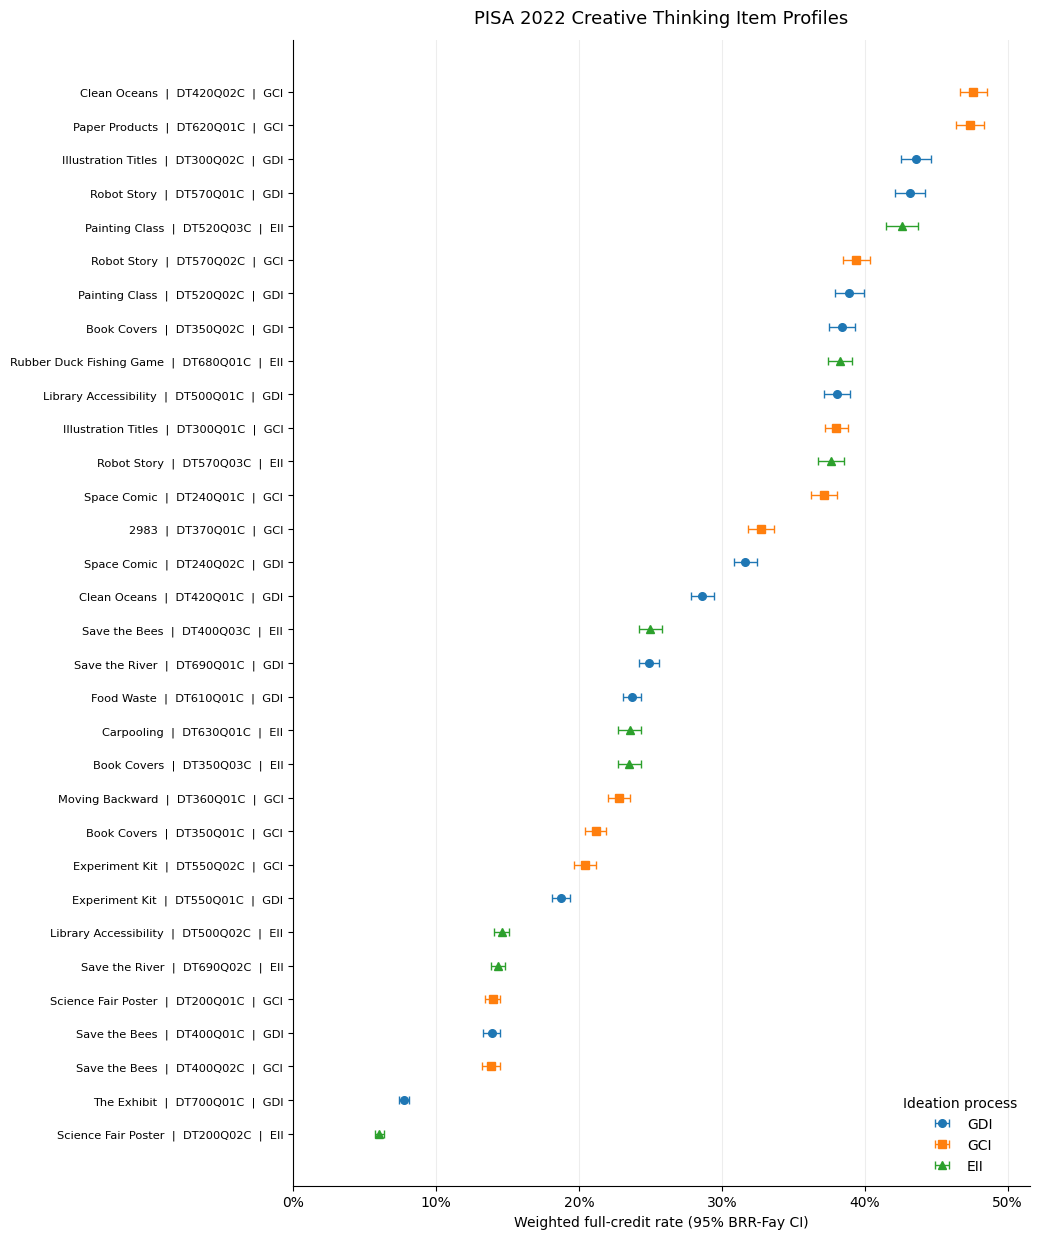

In [ ]:
# Publication-quality item-level full-credit profile

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import re


# 1. Make task names publication friendly

TASK_NAMES = {
    "ScienceFairPoster": "Science Fair Poster",
    "SpaceComic": "Space Comic",
    "CleanOceans": "Clean Oceans",
    "Experiment Kit": "Experiment Kit",
    "SaveTheRiver": "Save the River",
    "IllustrationTitles": "Illustration Titles",
    "SaveTheBees": "Save the Bees",
    "The Exhibit": "The Exhibit",
    "Book Covers": "Book Covers",
    "Library Accessibility": "Library Accessibility",
    "Paper Products": "Paper Products",
    "Robot Story": "Robot Story",
    "Food Waste": "Food Waste",
    "Rubber Duck Fishing Game": "Rubber Duck Fishing Game",
    "Painting Class": "Painting Class",
    "Carpooling": "Carpooling",
    "2983": "2983",
    "Moving Backward": "Moving Backward"
}


def pretty_task_name(task):
    if task in TASK_NAMES:
        return TASK_NAMES[task]

    # fallback for CamelCase names
    return re.sub(
        r"(?<=[a-z])(?=[A-Z])",
        " ",
        str(task)
    )


plot_df = item_success_df.copy()

plot_df["task_pretty"] = (
    plot_df["task"]
    .apply(pretty_task_name)
)

plot_df["plot_label"] = (
    plot_df["task_pretty"]
    + "  |  "
    + plot_df["item"]
    + "  |  "
    + plot_df["ideation_process"]
)

plot_df = (
    plot_df
    .sort_values(
        "full_credit_rate",
        ascending=True
    )
    .reset_index(drop=True)
)


# 2. Plot

fig, ax = plt.subplots(
    figsize=(10.5, 12.5)
)

y = np.arange(len(plot_df))

xerr = np.vstack([
    plot_df["full_credit_rate"]
    - plot_df["full_CI_low"],

    plot_df["full_CI_high"]
    - plot_df["full_credit_rate"]
])


# Different marker shapes for ideation process
markers = {
    "GDI": "o",
    "GCI": "s",
    "EII": "^"
}


for process, marker in markers.items():

    mask = (
        plot_df["ideation_process"]
        == process
    )

    ax.errorbar(
        plot_df.loc[mask, "full_credit_rate"],
        y[mask],
        xerr=xerr[:, mask],
        fmt=marker,
        linestyle="none",
        capsize=3,
        markersize=5.5,
        linewidth=1,
        label=process
    )


# 3. Formatting

ax.set_yticks(y)

ax.set_yticklabels(
    plot_df["plot_label"],
    fontsize=8.2
)

ax.set_xlim(
    0,
    max(plot_df["full_CI_high"]) + 0.03
)

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

ax.set_xlabel(
    "Weighted full-credit rate (95% BRR-Fay CI)",
    fontsize=10
)

ax.set_ylabel("")

ax.set_title(
    "PISA 2022 Creative Thinking Item Profiles",
    fontsize=13,
    pad=12
)

ax.grid(
    axis="x",
    alpha=0.22
)

ax.legend(
    title="Ideation process",
    frameon=False,
    loc="lower right"
)

# Remove unnecessary frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig_item_full_credit_profiles.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

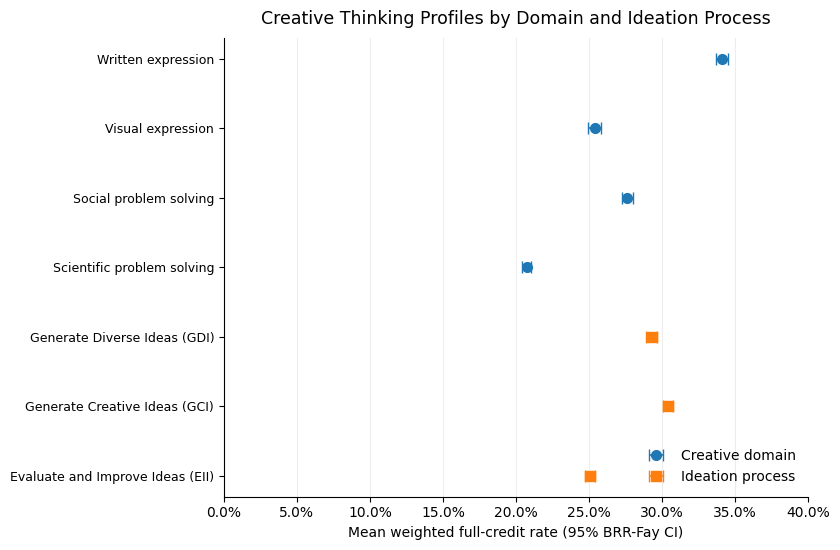

In [ ]:
# Domain and ideation-process full-credit profiles

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

plot_dim = dimension_success_df.copy()

label_map = {
    "written_expression": "Written expression",
    "visual_expression": "Visual expression",
    "social_problem_solving": "Social problem solving",
    "scientific_problem_solving": "Scientific problem solving",
    "GDI": "Generate Diverse Ideas (GDI)",
    "GCI": "Generate Creative Ideas (GCI)",
    "EII": "Evaluate and Improve Ideas (EII)"
}

plot_dim["label"] = (
    plot_dim["dimension"]
    .map(label_map)
)

# Desired order
order = [
    "written_expression",
    "visual_expression",
    "social_problem_solving",
    "scientific_problem_solving",
    "GDI",
    "GCI",
    "EII"
]

plot_dim["order"] = (
    plot_dim["dimension"]
    .apply(order.index)
)

plot_dim = (
    plot_dim
    .sort_values("order", ascending=False)
    .reset_index(drop=True)
)

y = np.arange(len(plot_dim))

xerr = np.vstack([
    plot_dim["estimate"] - plot_dim["CI_low"],
    plot_dim["CI_high"] - plot_dim["estimate"]
])

fig, ax = plt.subplots(figsize=(8.5, 5.6))

# Plot domains and processes separately
for dim_type, marker, name in [
    ("domain", "o", "Creative domain"),
    ("ideation_process", "s", "Ideation process")
]:

    mask = (
        plot_dim["dimension_type"]
        == dim_type
    )

    ax.errorbar(
        plot_dim.loc[mask, "estimate"],
        y[mask],
        xerr=xerr[:, mask],
        fmt=marker,
        linestyle="none",
        capsize=4,
        markersize=7,
        linewidth=1.2,
        label=name
    )

ax.set_yticks(y)

ax.set_yticklabels(
    plot_dim["label"],
    fontsize=9
)

ax.set_xlim(0, 0.40)

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

ax.set_xlabel(
    "Mean weighted full-credit rate (95% BRR-Fay CI)"
)

ax.set_ylabel("")

ax.set_title(
    "Creative Thinking Profiles by Domain and Ideation Process",
    fontsize=12.5,
    pad=10
)

ax.grid(
    axis="x",
    alpha=0.22
)

ax.legend(
    frameon=False,
    loc="lower right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Audit country × item scorable support
# Corrected version: reconstruct canonical_var from response matrix

import numpy as np
import pandas as pd


# 1. Alignment checks

assert len(ct_core_raw) == len(ct_response_tokens)
assert len(ct_core_raw) == len(ct_exposed_weighted)

assert np.array_equal(
    ct_core_raw["CNT"].to_numpy(),
    ct_exposed_weighted["CNT"].to_numpy()
)

assert np.array_equal(
    ct_core_raw["CNTSTUID"].to_numpy(),
    ct_exposed_weighted["CNTSTUID"].to_numpy()
)


# 2. Reconstruct canonical item mapping
#
# Some official items use original C variables;
# others use shortened C2 variables.
# ct_response_tokens already contains the canonical
# 32-variable representation established earlier.

response_cols = set(ct_response_tokens.columns)

item_meta_69 = (
    item_success_df[
        [
            "item",
            "domain",
            "ideation_process"
        ]
    ]
    .drop_duplicates("item")
    .copy()
)


def find_canonical_var(item):

    # Original C version
    if item in response_cols:
        return item

    # Shortened C2 version
    c2 = f"{item}2"

    if c2 in response_cols:
        return c2

    raise ValueError(
        f"No canonical response variable found for {item}"
    )


item_meta_69["canonical_var"] = (
    item_meta_69["item"]
    .apply(find_canonical_var)
)


# Validation
assert item_meta_69["item"].nunique() == 32
assert item_meta_69["canonical_var"].nunique() == 32

assert set(item_meta_69["canonical_var"]) == set(
    ct_response_tokens.columns
)

item_meta_69 = (
    item_meta_69
    .set_index("canonical_var")
)


print(
    "Canonical item mapping verified:",
    len(item_meta_69),
    "items"
)


# 3. Country × item support
#
# Tokens:
# 0 = NO_CREDIT
# 1 = PARTIAL_CREDIT
# 2 = FULL_CREDIT
# 3 = NOT_REACHED
# 4 = NOT_APPLICABLE
# 5 = INVALID
# 6 = NO_RESPONSE
# 7 = STRUCTURAL_MISSING
#
# Encountered = anything except STRUCTURAL_MISSING
# Scorable    = NO / PARTIAL / FULL credit

country_array = ct_core_raw["CNT"].to_numpy()

rows = []

for cnt in sorted(
    ct_core_raw["CNT"].dropna().unique()
):

    country_mask = (country_array == cnt)

    for canonical_var in ct_response_tokens.columns:

        x = (
            ct_response_tokens.loc[
                country_mask,
                canonical_var
            ]
            .to_numpy()
        )

        n_country = len(x)

        n_encountered = np.isin(
            x,
            [0, 1, 2, 3, 4, 5, 6]
        ).sum()

        n_scorable = np.isin(
            x,
            [0, 1, 2]
        ).sum()

        n_not_applicable = (
            x == 4
        ).sum()

        scorable_pct_encountered = (
            100 * n_scorable / n_encountered
            if n_encountered > 0
            else np.nan
        )

        not_applicable_pct_encountered = (
            100 * n_not_applicable / n_encountered
            if n_encountered > 0
            else np.nan
        )

        meta = item_meta_69.loc[
            canonical_var
        ]

        rows.append({
            "CNT": cnt,
            "item": meta["item"],
            "canonical_var": canonical_var,
            "domain": meta["domain"],
            "ideation_process":
                meta["ideation_process"],
            "n_country": n_country,
            "n_encountered": n_encountered,
            "n_scorable": n_scorable,
            "scorable_pct_encountered":
                scorable_pct_encountered,
            "not_applicable_pct_encountered":
                not_applicable_pct_encountered
        })


country_item_support = pd.DataFrame(rows)


# 4. Item-level cross-country support

item_support_summary = (
    country_item_support
    .groupby(
        [
            "item",
            "canonical_var",
            "domain",
            "ideation_process"
        ],
        as_index=False
    )
    .agg(
        countries_with_any_scorable=(
            "n_scorable",
            lambda x: (x > 0).sum()
        ),

        countries_with_zero_scorable=(
            "n_scorable",
            lambda x: (x == 0).sum()
        ),

        min_scorable_pct=(
            "scorable_pct_encountered",
            "min"
        ),

        median_scorable_pct=(
            "scorable_pct_encountered",
            "median"
        ),

        max_not_applicable_pct=(
            "not_applicable_pct_encountered",
            "max"
        )
    )
)


# 5. Number of countries with <50% scorable support

lt50 = (
    country_item_support
    .assign(
        lt50=lambda d:
            d["scorable_pct_encountered"] < 50
    )
    .groupby("canonical_var")["lt50"]
    .sum()
)


item_support_summary[
    "countries_with_lt50pct_scorable"
] = (
    item_support_summary[
        "canonical_var"
    ]
    .map(lt50)
    .astype(int)
)


# 6. Sort problematic items first

item_support_summary = (
    item_support_summary
    .sort_values(
        [
            "countries_with_zero_scorable",
            "countries_with_lt50pct_scorable",
            "min_scorable_pct"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


# 7. Output

print(
    "\nCountries/economies:",
    country_item_support["CNT"].nunique()
)

print(
    "Items:",
    country_item_support[
        "canonical_var"
    ].nunique()
)

print(
    "Country-item combinations:",
    len(country_item_support)
)

print(
    "\nCountry-item combinations with zero scorable responses:",
    (
        country_item_support[
            "n_scorable"
        ] == 0
    ).sum()
)

print(
    "Country-item combinations with <50% scorable among encountered:",
    (
        country_item_support[
            "scorable_pct_encountered"
        ] < 50
    ).sum()
)

print(
    "\nItem-level cross-country support:"
)

display(
    item_support_summary.round(2)
)

In [ ]:
# OECD-style full-credit rates by domain and ideation process
# Validation against published PISA 2022 methodology

import numpy as np
import pandas as pd


# 1. Alignment checks

assert len(ct_response_tokens) == len(ct_exposed_weighted)

assert np.array_equal(
    ct_core_raw["CNTSTUID"].to_numpy(),
    ct_exposed_weighted["CNTSTUID"].to_numpy()
)

assert np.array_equal(
    ct_core_raw["CNT"].to_numpy(),
    ct_exposed_weighted["CNT"].to_numpy()
)


# 2. OECD-compatible response coding
#
# Full-credit analysis:
#
# FULL_CREDIT        -> 1
# NO_CREDIT          -> 0
# PARTIAL_CREDIT     -> 0
# NO_RESPONSE        -> 0
#
# NOT_REACHED        -> missing
# NOT_APPLICABLE     -> missing
# INVALID            -> missing
# STRUCTURAL_MISSING -> missing

FULL_CREDIT = 2

RESPONDED_TOKENS = [0, 1, 2, 6]


def student_full_credit_rate(columns):

    x = ct_response_tokens[
        columns
    ].to_numpy()

    responded = np.isin(
        x,
        RESPONDED_TOKENS
    )

    full = (x == FULL_CREDIT)

    denominator = responded.sum(axis=1)

    numerator = (
        full & responded
    ).sum(axis=1)

    rate = np.full(
        len(x),
        np.nan,
        dtype=float
    )

    valid = denominator > 0

    rate[valid] = (
        numerator[valid] /
        denominator[valid]
    )

    return rate, denominator


# 3. Metadata

meta70 = (
    item_meta_69
    .reset_index()
)

assert len(meta70) == 32


# 4. Define the 7 PISA task subsets

subset_definitions = []


# Domains
for dimension in [
    "written_expression",
    "visual_expression",
    "social_problem_solving",
    "scientific_problem_solving"
]:

    cols = meta70.loc[
        meta70["domain"] == dimension,
        "canonical_var"
    ].tolist()

    subset_definitions.append({
        "dimension_type": "domain",
        "dimension": dimension,
        "columns": cols
    })


# Ideation processes
for dimension in [
    "GDI",
    "GCI",
    "EII"
]:

    cols = meta70.loc[
        meta70["ideation_process"] == dimension,
        "canonical_var"
    ].tolist()

    subset_definitions.append({
        "dimension_type": "ideation_process",
        "dimension": dimension,
        "columns": cols
    })


# 5. Student-level full-credit ratios

student_rates = ct_exposed_weighted[
    [
        "CNT",
        "CNTSTUID",
        "W_FSTUWT"
    ]
].copy()


for s in subset_definitions:

    rate, n_responded = student_full_credit_rate(
        s["columns"]
    )

    key = (
        f'{s["dimension_type"]}_'
        f'{s["dimension"]}'
    )

    student_rates[key] = rate
    student_rates[
        f"n_responded_{key}"
    ] = n_responded


# 6. Country-level weighted means
#
# OECD method:
# first student-level ratio,
# then weighted country mean

country_rows = []

for s in subset_definitions:

    key = (
        f'{s["dimension_type"]}_'
        f'{s["dimension"]}'
    )

    for cnt, g in student_rates.groupby("CNT"):

        valid = (
            g[key].notna() &
            g["W_FSTUWT"].notna()
        )

        if valid.sum() == 0:
            estimate = np.nan
        else:
            estimate = np.average(
                g.loc[valid, key],
                weights=g.loc[
                    valid,
                    "W_FSTUWT"
                ]
            )

        country_rows.append({
            "CNT": cnt,
            "dimension_type":
                s["dimension_type"],
            "dimension":
                s["dimension"],
            "n_students_valid":
                int(valid.sum()),
            "estimate":
                estimate
        })


country_dimension_rates = pd.DataFrame(
    country_rows
)


# 7. OECD countries participating in CT

OECD_CT = {
    "AUS", "BEL", "CAN", "CHL",
    "COL", "CRI", "CZE", "DNK",
    "EST", "FIN", "FRA", "DEU",
    "GRC", "HUN", "ISL", "ISR",
    "ITA", "KOR", "LVA", "LTU",
    "MEX", "NLD", "NZL", "POL",
    "PRT", "SVK", "SVN", "ESP"
}

present_oecd = sorted(
    OECD_CT.intersection(
        set(country_dimension_rates["CNT"])
    )
)

print(
    "OECD countries/economies used:",
    len(present_oecd)
)

print(present_oecd)


# 8. OECD average
#
# OECD average = arithmetic mean of country estimates,
# not population-pooled estimate.

oecd_dimension_rates = (
    country_dimension_rates[
        country_dimension_rates[
            "CNT"
        ].isin(present_oecd)
    ]
    .groupby(
        [
            "dimension_type",
            "dimension"
        ],
        as_index=False
    )
    .agg(
        estimate=("estimate", "mean"),
        n_countries=("CNT", "nunique")
    )
)


# 9. Published OECD Figure III.4.1 values
# Rounded values shown in OECD report

published = {
    "written_expression": 0.50,
    "visual_expression": 0.32,
    "social_problem_solving": 0.39,
    "scientific_problem_solving": 0.32,
    "GDI": 0.42,
    "GCI": 0.44,
    "EII": 0.34
}


oecd_dimension_rates[
    "OECD_published_approx"
] = (
    oecd_dimension_rates[
        "dimension"
    ].map(published)
)


oecd_dimension_rates[
    "difference"
] = (
    oecd_dimension_rates["estimate"] -
    oecd_dimension_rates[
        "OECD_published_approx"
    ]
)


# Percent display
validation70 = (
    oecd_dimension_rates.copy()
)

for col in [
    "estimate",
    "OECD_published_approx",
    "difference"
]:
    validation70[col] *= 100


print(
    "\nOECD-method validation:"
)

display(
    validation70.round(2)
)


# 10. Country table preview

print(
    "\nCountry-level estimates preview:"
)

display(
    country_dimension_rates
    .sort_values(
        [
            "dimension_type",
            "dimension",
            "estimate"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .head(30)
    .round(4)
)

OECD countries/economies used: 28
['AUS', 'BEL', 'CAN', 'CHL', 'COL', 'CRI', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GRC', 'HUN', 'ISL', 'ISR', 'ITA', 'KOR', 'LTU', 'LVA', 'MEX', 'NLD', 'NZL', 'POL', 'PRT', 'SVK', 'SVN']

OECD-method validation:


,dimension_type,dimension,estimate,n_countries,OECD_published_approx,difference
0,domain,scientific_problem_solving,30.35,28,32.0,-1.65
1,domain,social_problem_solving,38.06,28,39.0,-0.94
2,domain,visual_expression,31.64,28,32.0,-0.36
3,domain,written_expression,49.02,28,50.0,-0.98
4,ideation_process,EII,32.64,28,34.0,-1.36
5,ideation_process,GCI,43.16,28,44.0,-0.84
6,ideation_process,GDI,41.92,28,42.0,-0.08



Country-level estimates preview:


,CNT,dimension_type,dimension,n_students_valid,estimate
219,KOR,domain,scientific_problem_solving,1771,0.4550
243,SGP,domain,scientific_problem_solving,1818,0.4219
205,EST,domain,scientific_problem_solving,1734,0.3875
196,CAN,domain,scientific_problem_solving,6566,0.3731
204,ESP,domain,scientific_problem_solving,8571,0.3634
206,FIN,domain,scientific_problem_solving,2774,0.3609
202,DNK,domain,scientific_problem_solving,1812,0.3573
222,MAC,domain,scientific_problem_solving,1193,0.3492
191,AUS,domain,scientific_problem_solving,3616,0.3451
231,NZL,domain,scientific_problem_solving,1235,0.3431


In [ ]:
# BRR-Fay uncertainty for OECD-style domain/process estimates

oecd_country_brr_rows = []

for s in subset_definitions:

    rate, n_responded = student_full_credit_rate(
        s["columns"]
    )

    tmp = ct_exposed_weighted.copy()
    tmp["rate"] = rate

    for cnt in present_oecd:

        g = tmp.loc[
            tmp["CNT"] == cnt
        ].copy()

        valid = (
            g["rate"].notna()
            & g["W_FSTUWT"].notna()
        )

        g = g.loc[valid]

        if len(g) == 0:
            continue

        y = g["rate"].to_numpy(dtype=float)

        # Main estimate
        w = g["W_FSTUWT"].to_numpy(dtype=float)

        estimate = np.average(
            y,
            weights=w
        )

        # Replicate estimates
        rep_estimates = []

        for rw_col in replicate_weights:

            rw = (
                g[rw_col]
                .to_numpy(dtype=float)
            )

            rep_estimates.append(
                np.average(
                    y,
                    weights=rw
                )
            )

        rep_estimates = np.array(
            rep_estimates
        )

        variance = (
            0.05
            * np.sum(
                (rep_estimates - estimate) ** 2
            )
        )

        oecd_country_brr_rows.append({
            "CNT": cnt,
            "dimension_type":
                s["dimension_type"],
            "dimension":
                s["dimension"],
            "estimate": estimate,
            "variance": variance,
            "SE": np.sqrt(variance),
            "n_students": len(g)
        })


oecd_country_brr = pd.DataFrame(
    oecd_country_brr_rows
)


# OECD average:
# arithmetic mean across participating OECD countries.
#
# Country samples are independent, therefore:
# Var(mean) = sum(country variances) / K^2

oecd_summary_rows = []

for (
    dim_type,
    dimension
), g in oecd_country_brr.groupby(
    ["dimension_type", "dimension"]
):

    k = len(g)

    estimate = (
        g["estimate"].mean()
    )

    variance = (
        g["variance"].sum()
        / (k ** 2)
    )

    se = np.sqrt(variance)

    oecd_summary_rows.append({
        "dimension_type": dim_type,
        "dimension": dimension,
        "estimate": estimate,
        "SE": se,
        "CI_low":
            estimate - 1.96 * se,
        "CI_high":
            estimate + 1.96 * se,
        "n_countries": k
    })


oecd_dimension_brr = pd.DataFrame(
    oecd_summary_rows
)

display(
    oecd_dimension_brr.round(4)
)

,dimension_type,dimension,estimate,SE,CI_low,CI_high,n_countries
0,domain,scientific_problem_solving,0.3035,0.0018,0.3000,0.3070,28
1,domain,social_problem_solving,0.3806,0.0015,0.3776,0.3836,28
2,domain,visual_expression,0.3164,0.0020,0.3124,0.3203,28
3,domain,written_expression,0.4902,0.0016,0.4871,0.4932,28
4,ideation_process,EII,0.3264,0.0014,0.3236,0.3291,28
5,ideation_process,GCI,0.4316,0.0015,0.4287,0.4345,28
6,ideation_process,GDI,0.4192,0.0015,0.4163,0.4221,28


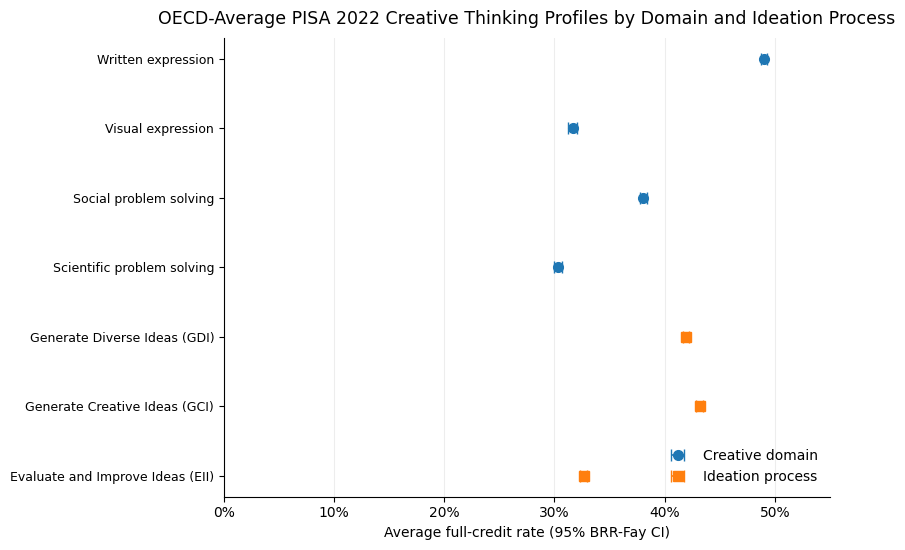

In [ ]:
# Correct OECD-style domain/process profile figure

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

plot_dim = oecd_dimension_brr.copy()

label_map = {
    "written_expression":
        "Written expression",
    "visual_expression":
        "Visual expression",
    "social_problem_solving":
        "Social problem solving",
    "scientific_problem_solving":
        "Scientific problem solving",
    "GDI":
        "Generate Diverse Ideas (GDI)",
    "GCI":
        "Generate Creative Ideas (GCI)",
    "EII":
        "Evaluate and Improve Ideas (EII)"
}

order = [
    "written_expression",
    "visual_expression",
    "social_problem_solving",
    "scientific_problem_solving",
    "GDI",
    "GCI",
    "EII"
]

plot_dim["label"] = (
    plot_dim["dimension"]
    .map(label_map)
)

plot_dim["order"] = (
    plot_dim["dimension"]
    .apply(order.index)
)

plot_dim = (
    plot_dim
    .sort_values(
        "order",
        ascending=False
    )
    .reset_index(drop=True)
)

y = np.arange(len(plot_dim))

xerr = np.vstack([
    plot_dim["estimate"]
    - plot_dim["CI_low"],

    plot_dim["CI_high"]
    - plot_dim["estimate"]
])

fig, ax = plt.subplots(
    figsize=(8.5, 5.6)
)

for dim_type, marker, legend_name in [
    ("domain", "o", "Creative domain"),
    ("ideation_process", "s",
     "Ideation process")
]:

    mask = (
        plot_dim["dimension_type"]
        == dim_type
    )

    ax.errorbar(
        plot_dim.loc[mask, "estimate"],
        y[mask],
        xerr=xerr[:, mask],
        fmt=marker,
        linestyle="none",
        capsize=4,
        markersize=7,
        linewidth=1.2,
        label=legend_name
    )

ax.set_yticks(y)

ax.set_yticklabels(
    plot_dim["label"],
    fontsize=9
)

ax.set_xlim(0, 0.55)

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

ax.set_xlabel(
    "Average full-credit rate "
    "(95% BRR-Fay CI)"
)

ax.set_ylabel("")

ax.set_title(
    "OECD-Average PISA 2022 Creative Thinking Profiles "
    "by Domain and Ideation Process",
    fontsize=12.5,
    pad=10
)

ax.grid(
    axis="x",
    alpha=0.22
)

ax.legend(
    frameon=False,
    loc="lower right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig_domain_process_profiles.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

In [ ]:
# Compare candidate common-support item sets

support_thresholds = [0, 25, 40, 50]

support_set_results = []

for threshold in support_thresholds:

    eligible = item_support_summary[
        (item_support_summary["countries_with_any_scorable"] == 63)
        &
        (item_support_summary["min_scorable_pct"] >= threshold)
    ].copy()

    print("\n" + "=" * 90)
    print(
        f"COMMON-SUPPORT SET: "
        f"all 63 countries + minimum scorable support >= {threshold}%"
    )
    print("=" * 90)

    print("Number of items:", len(eligible))

    print("\nDomain composition:")
    display(
        eligible["domain"]
        .value_counts()
        .rename_axis("domain")
        .reset_index(name="n_items")
    )

    print("\nIdeation-process composition:")
    display(
        eligible["ideation_process"]
        .value_counts()
        .rename_axis("ideation_process")
        .reset_index(name="n_items")
    )

    print("\nItems:")
    display(
        eligible[
            [
                "item",
                "domain",
                "ideation_process",
                "min_scorable_pct",
                "median_scorable_pct",
                "max_not_applicable_pct"
            ]
        ]
        .sort_values(
            ["domain", "ideation_process", "item"]
        )
        .reset_index(drop=True)
        .round(2)
    )

    support_set_results.append({
        "threshold": threshold,
        "n_items": len(eligible),
        "n_written": (
            eligible["domain"]
            == "written_expression"
        ).sum(),
        "n_visual": (
            eligible["domain"]
            == "visual_expression"
        ).sum(),
        "n_social": (
            eligible["domain"]
            == "social_problem_solving"
        ).sum(),
        "n_scientific": (
            eligible["domain"]
            == "scientific_problem_solving"
        ).sum(),
        "n_GDI": (
            eligible["ideation_process"]
            == "GDI"
        ).sum(),
        "n_GCI": (
            eligible["ideation_process"]
            == "GCI"
        ).sum(),
        "n_EII": (
            eligible["ideation_process"]
            == "EII"
        ).sum()
    })


support_threshold_summary = pd.DataFrame(
    support_set_results
)

print("\n" + "=" * 90)
print("SUMMARY")
print("=" * 90)

display(support_threshold_summary)

In [ ]:
# Build official and common-support country × domain profiles

COMMON_SUPPORT_THRESHOLD = 40

common_support_items = (
    item_support_summary.loc[
        (item_support_summary["countries_with_any_scorable"] == 63)
        &
        (
            item_support_summary["min_scorable_pct"]
            >= COMMON_SUPPORT_THRESHOLD
        ),
        "item"
    ]
    .tolist()
)

print(
    "Common-support threshold:",
    COMMON_SUPPORT_THRESHOLD
)

print(
    "Common-support items:",
    len(common_support_items)
)


# Helper: obtain canonical variable names for item list

meta74 = (
    item_meta_69
    .reset_index()
)


def canonical_vars_for_items(items):
    return (
        meta74.loc[
            meta74["item"].isin(items),
            "canonical_var"
        ]
        .tolist()
    )


# Official and common-support domain definitions

domain_profiles = []

domains = [
    "written_expression",
    "visual_expression",
    "social_problem_solving",
    "scientific_problem_solving"
]


for domain in domains:

    # Official item set
    official_items = (
        meta74.loc[
            meta74["domain"] == domain,
            "item"
        ]
        .tolist()
    )

    official_vars = canonical_vars_for_items(
        official_items
    )

    # Common-support subset
    sensitivity_items = [
        item
        for item in official_items
        if item in common_support_items
    ]

    sensitivity_vars = canonical_vars_for_items(
        sensitivity_items
    )

    domain_profiles.append({
        "domain": domain,
        "official_items": official_items,
        "official_vars": official_vars,
        "sensitivity_items": sensitivity_items,
        "sensitivity_vars": sensitivity_vars
    })


print("\nDomain item counts:")

for d in domain_profiles:
    print(
        d["domain"],
        "| official =", len(d["official_items"]),
        "| common-support =", len(d["sensitivity_items"])
    )


# Function:
# OECD-style student-level full-credit ratio,
# then country weighted mean

def country_weighted_domain_profile(
    response_columns,
    profile_name,
    domain_name
):

    rate, n_responded = student_full_credit_rate(
        response_columns
    )

    tmp = ct_exposed_weighted[
        [
            "CNT",
            "CNTSTUID",
            "W_FSTUWT"
        ]
    ].copy()

    tmp["rate"] = rate
    tmp["n_responded"] = n_responded

    rows = []

    for cnt, g in tmp.groupby("CNT"):

        valid = (
            g["rate"].notna()
            &
            g["W_FSTUWT"].notna()
        )

        if valid.sum() == 0:
            estimate = np.nan
        else:
            estimate = np.average(
                g.loc[valid, "rate"],
                weights=g.loc[
                    valid,
                    "W_FSTUWT"
                ]
            )

        rows.append({
            "CNT": cnt,
            "domain": domain_name,
            "profile": profile_name,
            "estimate": estimate,
            "n_students_valid":
                int(valid.sum())
        })

    return pd.DataFrame(rows)


# Generate both profiles

profile_frames = []

for d in domain_profiles:

    profile_frames.append(
        country_weighted_domain_profile(
            d["official_vars"],
            "official_32",
            d["domain"]
        )
    )

    profile_frames.append(
        country_weighted_domain_profile(
            d["sensitivity_vars"],
            "common_support_40",
            d["domain"]
        )
    )


country_domain_profiles = pd.concat(
    profile_frames,
    ignore_index=True
)


print(
    "\nCountries:",
    country_domain_profiles["CNT"].nunique()
)

print(
    "Domains:",
    country_domain_profiles["domain"].nunique()
)

print(
    "Profiles:",
    country_domain_profiles["profile"].unique()
)

Common-support threshold: 40
Common-support items: 18

Domain item counts:
written_expression | official = 12 | common-support = 5
visual_expression | official = 4 | common-support = 3
social_problem_solving | official = 10 | common-support = 6
scientific_problem_solving | official = 6 | common-support = 4

Countries: 63
Domains: 4
Profiles: ['official_32' 'common_support_40']


In [ ]:
# Compare official vs common-support country profiles

profile_compare = (
    country_domain_profiles
    .pivot_table(
        index=["CNT", "domain"],
        columns="profile",
        values="estimate"
    )
    .reset_index()
)

profile_compare["difference"] = (
    profile_compare["common_support_40"]
    -
    profile_compare["official_32"]
)

profile_compare["absolute_difference"] = (
    profile_compare["difference"].abs()
)


comparison_summary = []

for domain in domains:

    g = profile_compare.loc[
        profile_compare["domain"] == domain
    ].dropna()

    correlation = (
        g[
            [
                "official_32",
                "common_support_40"
            ]
        ]
        .corr()
        .iloc[0, 1]
    )

    comparison_summary.append({
        "domain": domain,
        "n_countries": len(g),
        "pearson_r": correlation,
        "mean_abs_difference":
            g["absolute_difference"].mean(),
        "median_abs_difference":
            g["absolute_difference"].median(),
        "max_abs_difference":
            g["absolute_difference"].max()
    })


profile_comparison_summary = pd.DataFrame(
    comparison_summary
)

display(
    profile_comparison_summary.round(4)
)


print("\nLargest country-domain changes:")

display(
    profile_compare
    .sort_values(
        "absolute_difference",
        ascending=False
    )
    .head(25)
    .round(4)
)

,domain,n_countries,pearson_r,mean_abs_difference,median_abs_difference,max_abs_difference
0,written_expression,63,0.9635,0.0289,0.0261,0.1058
1,visual_expression,63,0.9767,0.0149,0.0136,0.0751
2,social_problem_solving,63,0.9871,0.0442,0.0454,0.0847
3,scientific_problem_solving,63,0.9618,0.0516,0.0491,0.1359



Largest country-domain changes:


profile,CNT,domain,common_support_40,official_32,difference,absolute_difference
204,QUR,scientific_problem_solving,0.1643,0.3002,-0.1359,0.1359
243,THA,written_expression,0.1723,0.2781,-0.1058,0.1058
128,LVA,scientific_problem_solving,0.2012,0.2985,-0.0973,0.0973
72,FRA,scientific_problem_solving,0.2112,0.3055,-0.0943,0.0943
239,TAP,written_expression,0.4091,0.5034,-0.0943,0.0943
80,HKG,scientific_problem_solving,0.1602,0.2459,-0.0856,0.0856
132,MAC,scientific_problem_solving,0.2643,0.3492,-0.0849,0.0849
241,THA,social_problem_solving,0.1910,0.2757,-0.0847,0.0847
232,SVN,scientific_problem_solving,0.1207,0.2025,-0.0817,0.0817
60,ESP,scientific_problem_solving,0.2820,0.3634,-0.0815,0.0815


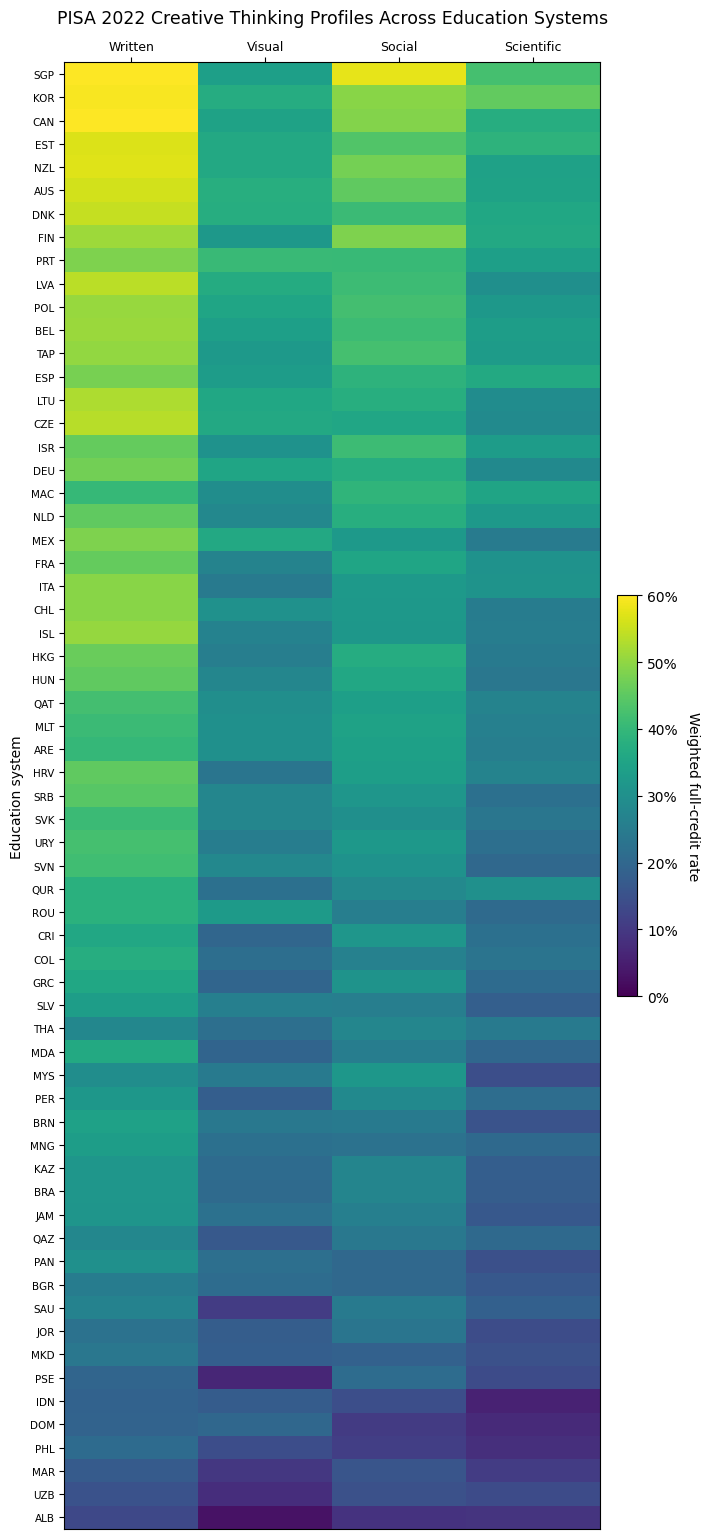

In [ ]:
# Country × domain heatmap using the official 32-item profile

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd


domain_order = [
    "written_expression",
    "visual_expression",
    "social_problem_solving",
    "scientific_problem_solving"
]

domain_labels = {
    "written_expression": "Written",
    "visual_expression": "Visual",
    "social_problem_solving": "Social",
    "scientific_problem_solving": "Scientific"
}


# Pivot official profile

official_heat = (
    country_domain_profiles.loc[
        country_domain_profiles["profile"] == "official_32"
    ]
    .pivot(
        index="CNT",
        columns="domain",
        values="estimate"
    )
    [domain_order]
)


# Sort countries by mean domain profile

official_heat["mean_profile"] = (
    official_heat.mean(axis=1)
)

official_heat = (
    official_heat
    .sort_values(
        "mean_profile",
        ascending=False
    )
)

country_order = (
    official_heat.index.tolist()
)

official_heat = (
    official_heat[domain_order]
)


# Plot

fig, ax = plt.subplots(
    figsize=(7.2, 15.5)
)

im = ax.imshow(
    official_heat.to_numpy(),
    aspect="auto",
    vmin=0,
    vmax=0.60
)

ax.set_yticks(
    np.arange(len(official_heat))
)

ax.set_yticklabels(
    official_heat.index,
    fontsize=7.5
)

ax.set_xticks(
    np.arange(len(domain_order))
)

ax.set_xticklabels(
    [domain_labels[d] for d in domain_order],
    fontsize=9
)

ax.set_xlabel("")
ax.set_ylabel("Education system")

ax.set_title(
    "PISA 2022 Creative Thinking Profiles Across Education Systems",
    fontsize=12.5,
    pad=12
)

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.03
)

cbar.set_label(
    "Weighted full-credit rate",
    rotation=270,
    labelpad=16
)

cbar.ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

ax.tick_params(
    axis="x",
    top=True,
    labeltop=True,
    bottom=False,
    labelbottom=False
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig_country_domain_official_heatmap.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

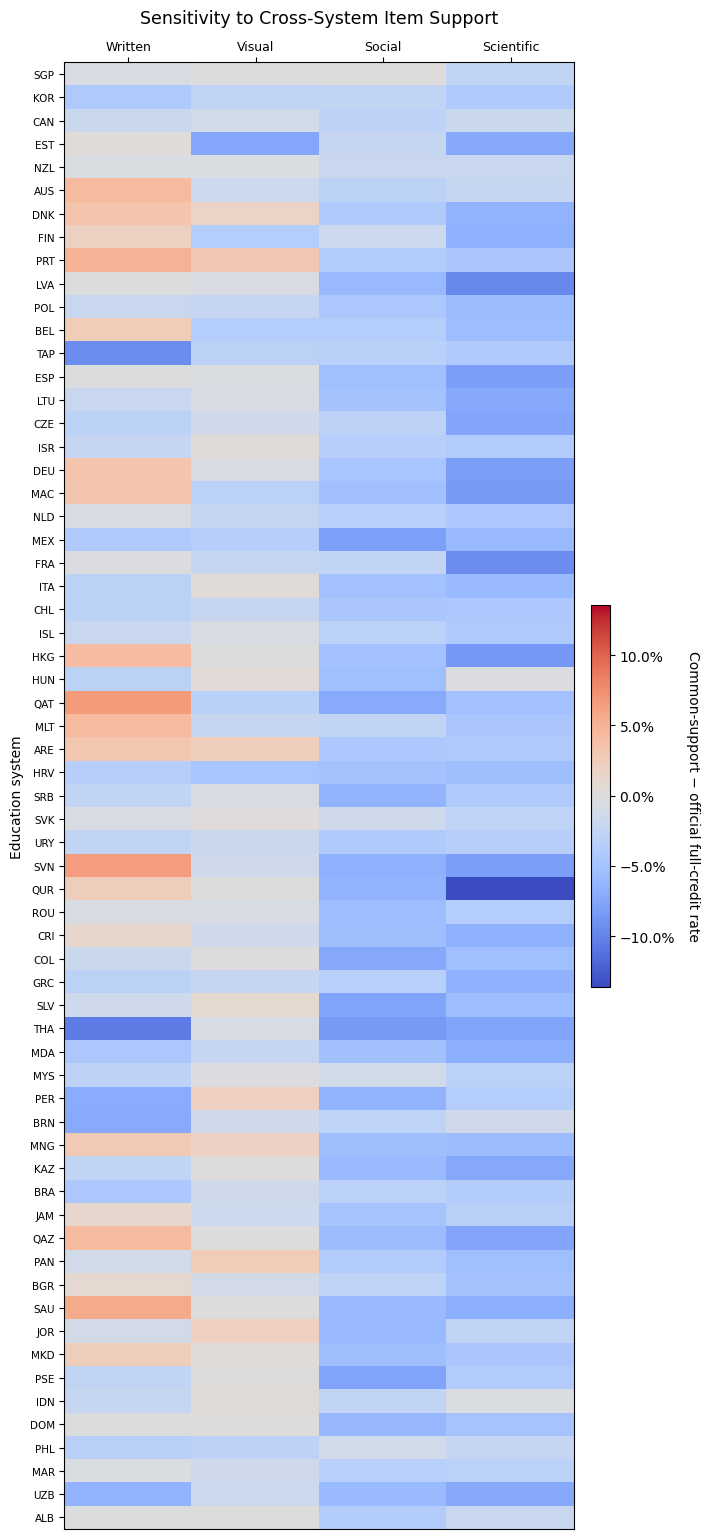

In [ ]:
# Sensitivity heatmap:
# common-support profile minus official profile

difference_heat = (
    profile_compare
    .pivot(
        index="CNT",
        columns="domain",
        values="difference"
    )
    [domain_order]
)

# Use exactly the same country ordering as Figure 3
difference_heat = (
    difference_heat
    .reindex(country_order)
)


max_abs = np.nanmax(
    np.abs(
        difference_heat.to_numpy()
    )
)


fig, ax = plt.subplots(
    figsize=(7.2, 15.5)
)

im = ax.imshow(
    difference_heat.to_numpy(),
    aspect="auto",
    cmap="coolwarm",
    vmin=-max_abs,
    vmax=max_abs
)

ax.set_yticks(
    np.arange(len(difference_heat))
)

ax.set_yticklabels(
    difference_heat.index,
    fontsize=7.5
)

ax.set_xticks(
    np.arange(len(domain_order))
)

ax.set_xticklabels(
    [domain_labels[d] for d in domain_order],
    fontsize=9
)

ax.set_xlabel("")
ax.set_ylabel("Education system")

ax.set_title(
    "Sensitivity to Cross-System Item Support",
    fontsize=12.5,
    pad=12
)

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.03
)

cbar.set_label(
    "Common-support − official full-credit rate",
    rotation=270,
    labelpad=18
)

cbar.ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

ax.tick_params(
    axis="x",
    top=True,
    labeltop=True,
    bottom=False,
    labelbottom=False
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig_country_domain_support_sensitivity.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

In [ ]:
# Define the planned CReST multi-view structure

crest_view_plan = pd.DataFrame([
    {
        "view": "creative_performance",
        "source": "CY08MSP_CRT_COG.SAV",
        "role": "main representation / target structure",
        "examples": "32 CT item credit states",
        "main_model": True
    },
    {
        "view": "process_behaviour",
        "source": "CY08MSP_CRT_COG.SAV",
        "role": "behavioural process representation",
        "examples": "timing, first action, actions, visits, short visits",
        "main_model": True
    },
    {
        "view": "student_context",
        "source": "CY08MSP_STU_QQQ.SAV",
        "role": "context representation / disentanglement",
        "examples": "demographics, SES, home/language/migration context",
        "main_model": True
    },
    {
        "view": "school_context",
        "source": "CY08MSP_SCH_QQQ.SAV",
        "role": "school-level contextual representation",
        "examples": "school type, resources, location, composition",
        "main_model": True
    },
    {
        "view": "general_cognitive_auxiliary",
        "source": "CY08MSP_STU_COG.SAV",
        "role": "optional ablation / auxiliary information",
        "examples": "mathematics, reading, science information",
        "main_model": False
    }
])

display(crest_view_plan)

,view,source,role,examples,main_model
0,creative_performance,CY08MSP_CRT_COG.SAV,main representation / target structure,32 CT item credit states,True
1,process_behaviour,CY08MSP_CRT_COG.SAV,behavioural process representation,"timing, first action, actions, visits, short visits",True
2,student_context,CY08MSP_STU_QQQ.SAV,context representation / disentanglement,"demographics, SES, home/language/migration context",True
3,school_context,CY08MSP_SCH_QQQ.SAV,school-level contextual representation,"school type, resources, location, composition",True
4,general_cognitive_auxiliary,CY08MSP_STU_COG.SAV,optional ablation / auxiliary information,"mathematics, reading, science information",False


In [ ]:
# Build searchable metadata dictionaries

def build_metadata_dictionary(path):
    _, meta = pyreadstat.read_sav(
        str(path),
        metadataonly=True
    )

    rows = []

    for var in meta.column_names:
        rows.append({
            "variable": var,
            "label": meta.column_names_to_labels.get(var, "")
        })

    return pd.DataFrame(rows)


student_dictionary = build_metadata_dictionary(
    FILES["student_questionnaire"]
)

school_dictionary = build_metadata_dictionary(
    FILES["school"]
)

cognitive_dictionary = build_metadata_dictionary(
    FILES["student_cognitive"]
)

timing_dictionary = build_metadata_dictionary(
    FILES["student_timing"]
)


print("Student questionnaire variables:",
      len(student_dictionary))

print("School questionnaire variables:",
      len(school_dictionary))

print("Student cognitive variables:",
      len(cognitive_dictionary))

print("Student timing variables:",
      len(timing_dictionary))

Student questionnaire variables: 1278
School questionnaire variables: 431
Student cognitive variables: 5023
Student timing variables: 172


In [ ]:
# Search variable metadata by construct keywords

def search_metadata(
    dictionary,
    keywords,
    variable_patterns=None
):
    """
    Search variable names and labels using one or more keywords.
    """

    df = dictionary.copy()

    text = (
        df["variable"].fillna("").astype(str)
        + " "
        + df["label"].fillna("").astype(str)
    ).str.lower()

    keyword_mask = pd.Series(
        False,
        index=df.index
    )

    for keyword in keywords:
        keyword_mask |= text.str.contains(
            keyword.lower(),
            regex=False
        )

    if variable_patterns is not None:

        variable_mask = pd.Series(
            False,
            index=df.index
        )

        for pattern in variable_patterns:
            variable_mask |= (
                df["variable"]
                .str.upper()
                .str.contains(
                    pattern.upper(),
                    regex=False
                )
            )

        keyword_mask |= variable_mask

    return (
        df.loc[keyword_mask]
        .drop_duplicates("variable")
        .sort_values("variable")
        .reset_index(drop=True)
    )

In [ ]:
# Discover candidate student-context variables

student_construct_queries = {

    "demographics": {
        "keywords": [
            "gender",
            "sex",
            "age",
            "grade"
        ],
        "patterns": [
            "ST004",
            "AGE",
            "GRADE"
        ]
    },

    "socioeconomic_context": {
        "keywords": [
            "economic social cultural status",
            "socio-economic",
            "socioeconomic",
            "home possessions",
            "occupational status",
            "parent education",
            "parental education"
        ],
        "patterns": [
            "ESCS",
            "HOMEPOS",
            "HISEI",
            "PARED"
        ]
    },

    "migration_language": {
        "keywords": [
            "immigrant",
            "immigration",
            "language spoken at home",
            "language at home",
            "country of birth"
        ],
        "patterns": [
            "IMMIG",
            "LANG"
        ]
    },

    "home_learning_context": {
        "keywords": [
            "books at home",
            "home learning",
            "educational resources",
            "study room",
            "computer at home",
            "internet at home"
        ],
        "patterns": []
    },

    "school_experience": {
        "keywords": [
            "sense of belonging",
            "belonging",
            "teacher support",
            "disciplinary climate",
            "bullying",
            "school safety"
        ],
        "patterns": [
            "BELONG",
            "TEACHSUP",
            "DISCLIM",
            "BULLIED"
        ]
    }
}


student_candidate_tables = {}

for construct, query in student_construct_queries.items():

    result = search_metadata(
        student_dictionary,
        keywords=query["keywords"],
        variable_patterns=query["patterns"]
    )

    student_candidate_tables[construct] = result

    print("\n" + "=" * 100)
    print(construct.upper())
    print("=" * 100)

    display(result)

In [ ]:
# Discover candidate school-context variables

school_construct_queries = {

    "school_location_type": {
        "keywords": [
            "school location",
            "community",
            "urban",
            "rural",
            "public school",
            "private school",
            "school type"
        ],
        "patterns": []
    },

    "school_size_composition": {
        "keywords": [
            "school size",
            "number of students",
            "student population",
            "socioeconomic",
            "socio-economic",
            "disadvantaged students"
        ],
        "patterns": []
    },

    "staff_resources": {
        "keywords": [
            "teacher shortage",
            "shortage of teaching staff",
            "staff shortage",
            "teacher resources"
        ],
        "patterns": [
            "STAFFSHORT"
        ]
    },

    "material_resources": {
        "keywords": [
            "educational material",
            "educational resources",
            "physical infrastructure",
            "digital resources",
            "shortage of educational material"
        ],
        "patterns": [
            "EDUSHORT"
        ]
    },

    "school_climate": {
        "keywords": [
            "school climate",
            "disciplinary climate",
            "student behaviour",
            "teacher behaviour",
            "learning climate"
        ],
        "patterns": []
    },

    "school_governance": {
        "keywords": [
            "school autonomy",
            "responsibility",
            "curriculum",
            "assessment policy",
            "resource allocation"
        ],
        "patterns": []
    }
}


school_candidate_tables = {}

for construct, query in school_construct_queries.items():

    result = search_metadata(
        school_dictionary,
        keywords=query["keywords"],
        variable_patterns=query["patterns"]
    )

    school_candidate_tables[construct] = result

    print("\n" + "=" * 100)
    print(construct.upper())
    print("=" * 100)

    display(result)

In [ ]:
# Define preliminary CReST context-feature registry

student_feature_registry = pd.DataFrame([
    # Demographics
    ("ST004D01T", "demographics", "core"),
    ("AGE",       "demographics", "core"),
    ("GRADE",     "demographics", "core"),
    ("REPEAT",    "demographics", "core"),

    # SES
    ("ESCS",      "socioeconomic_context", "core"),
    ("HISEI",     "socioeconomic_context", "decomposition"),
    ("PAREDINT",  "socioeconomic_context", "decomposition"),
    ("HOMEPOS",   "socioeconomic_context", "decomposition"),

    # Migration / language
    ("IMMIG",        "migration_language", "core"),
    ("LANGN",        "migration_language", "candidate"),
    ("LANGTEST_COG", "migration_language", "candidate"),

    # School experience
    ("BELONG",   "school_experience", "core"),
    ("BULLIED",  "school_experience", "core"),
    ("SCHRISK",  "school_experience", "core"),

    # Creativity-support context
    ("ST335Q06JA", "creativity_support", "core"),
    ("ST336Q04JA", "creativity_support", "core"),
    ("ST336Q05JA", "creativity_support", "core"),
    ("ST336Q06JA", "creativity_support", "core"),

    # Math-specific context: auxiliary only
    ("DISCLIM",  "math_specific_context", "auxiliary"),
    ("TEACHSUP", "math_specific_context", "auxiliary"),
], columns=["variable", "construct", "priority"])


school_feature_registry = pd.DataFrame([
    # School type/location
    ("PRIVATESCH", "school_type", "candidate"),
    ("SCHLTYPE",   "school_type", "candidate"),
    ("SC013Q01TA", "school_type", "candidate"),
    ("SC001Q01TA", "school_location", "core"),

    # Size/composition
    ("SCHSIZE",    "school_composition", "core"),
    ("SC211Q03JA", "school_composition", "candidate"),

    # Resources
    ("STAFFSHORT", "school_resources", "core"),
    ("EDUSHORT",   "school_resources", "core"),

    # Climate
    ("NEGSCLIM",  "school_climate", "core"),
    ("STUBEHA",   "school_climate", "core"),
    ("TEACHBEHA", "school_climate", "core"),

    # Governance
    ("SCHAUTO",  "school_governance", "candidate"),
    ("SRESPCUR", "school_governance", "candidate"),
    ("SRESPRES", "school_governance", "candidate"),
], columns=["variable", "construct", "priority"])


print("Student candidates:", len(student_feature_registry))
display(student_feature_registry)

print("\nSchool candidates:", len(school_feature_registry))
display(school_feature_registry)

Student candidates: 20


,variable,construct,priority
0,ST004D01T,demographics,core
1,AGE,demographics,core
2,GRADE,demographics,core
3,REPEAT,demographics,core
4,ESCS,socioeconomic_context,core
5,HISEI,socioeconomic_context,decomposition
6,PAREDINT,socioeconomic_context,decomposition
7,HOMEPOS,socioeconomic_context,decomposition
8,IMMIG,migration_language,core
9,LANGN,migration_language,candidate



School candidates: 14


,variable,construct,priority
0,PRIVATESCH,school_type,candidate
1,SCHLTYPE,school_type,candidate
2,SC013Q01TA,school_type,candidate
3,SC001Q01TA,school_location,core
4,SCHSIZE,school_composition,core
5,SC211Q03JA,school_composition,candidate
6,STAFFSHORT,school_resources,core
7,EDUSHORT,school_resources,core
8,NEGSCLIM,school_climate,core
9,STUBEHA,school_climate,core


In [ ]:
# Validate candidate variables against PISA metadata

_, student_meta = pyreadstat.read_sav(
    str(FILES["student_questionnaire"]),
    metadataonly=True
)

_, school_meta = pyreadstat.read_sav(
    str(FILES["school"]),
    metadataonly=True
)


student_available = set(student_meta.column_names)
school_available = set(school_meta.column_names)


student_feature_registry["exists"] = (
    student_feature_registry["variable"]
    .isin(student_available)
)

school_feature_registry["exists"] = (
    school_feature_registry["variable"]
    .isin(school_available)
)


student_feature_registry["label"] = (
    student_feature_registry["variable"]
    .map(student_meta.column_names_to_labels)
)

school_feature_registry["label"] = (
    school_feature_registry["variable"]
    .map(school_meta.column_names_to_labels)
)


print("STUDENT FEATURES")
display(student_feature_registry)

print("\nSCHOOL FEATURES")
display(school_feature_registry)


assert student_feature_registry["exists"].all(), (
    "At least one student candidate variable is absent."
)

assert school_feature_registry["exists"].all(), (
    "At least one school candidate variable is absent."
)

STUDENT FEATURES


,variable,construct,priority,exists,label
0,ST004D01T,demographics,core,True,Student (Standardized) Gender
1,AGE,demographics,core,True,Students' age
2,GRADE,demographics,core,True,Grade compared to modal grade in country
3,REPEAT,demographics,core,True,Grade repetition
4,ESCS,socioeconomic_context,core,True,"Index of economic, social and cultural status"
5,HISEI,socioeconomic_context,decomposition,True,Highest parental occupational status (ISEI) based on 4-digit human coded ISCO
6,PAREDINT,socioeconomic_context,decomposition,True,Index highest parental education (international years of schooling scale)
7,HOMEPOS,socioeconomic_context,decomposition,True,Home possessions (WLE)
8,IMMIG,migration_language,core,True,Index on immigrant background (OECD definition)
9,LANGN,migration_language,candidate,True,Language spoken at home



SCHOOL FEATURES


,variable,construct,priority,exists,label
0,PRIVATESCH,school_type,candidate,True,"School type derived from sampling information; values = public, private, missing"
1,SCHLTYPE,school_type,candidate,True,School type
2,SC013Q01TA,school_type,candidate,True,Is your school a public or a private school?
3,SC001Q01TA,school_location,core,True,Which of the following definitions best describes the community in which your school is located?
4,SCHSIZE,school_composition,core,True,School size (Sum)
5,SC211Q03JA,school_composition,candidate,True,Percentage [15-year-old modal grade] students who: Students from socioeconomically disadvantaged homes
6,STAFFSHORT,school_resources,core,True,Shortage of educational staff (WLE)
7,EDUSHORT,school_resources,core,True,Shortage of educational material (WLE)
8,NEGSCLIM,school_climate,core,True,Negative school climate (WLE)
9,STUBEHA,school_climate,core,True,Student-related factors affecting school climate (WLE)


In [ ]:
# Inspect value labels of key categorical context variables

categorical_checks = {
    "student": [
        "ST004D01T",
        "REPEAT",
        "IMMIG",
        "LANGN",
        "LANGTEST_COG"
    ],
    "school": [
        "PRIVATESCH",
        "SCHLTYPE",
        "SC013Q01TA",
        "SC001Q01TA"
    ]
}


for var in categorical_checks["student"]:

    print("\n" + "=" * 90)
    print("STUDENT:", var)
    print("=" * 90)

    print(
        student_meta.variable_value_labels.get(
            var, {}
        )
    )


for var in categorical_checks["school"]:

    print("\n" + "=" * 90)
    print("SCHOOL:", var)
    print("=" * 90)

    print(
        school_meta.variable_value_labels.get(
            var, {}
        )
    )

In [ ]:
# Build primary modelling base and merge context candidates

primary_base = (
    ct_core_raw.loc[
        has_scorable_response,
        [
            "CNT",
            "CNTRYID",
            "CNTSCHID",
            "CNTSTUID",
            "BOOKID"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

print("Primary modelling cohort:",
      len(primary_base))

assert len(primary_base) == 142564
assert primary_base["CNTSTUID"].is_unique


student_vars = (
    student_feature_registry["variable"]
    .tolist()
)

school_vars = (
    school_feature_registry["variable"]
    .tolist()
)


# Student context
#
# Default user_missing=False is intentional here:
# SPSS user-missing codes should count as missing
# for feature-availability analysis.

student_context_df, _ = pyreadstat.read_sav(
    str(FILES["student_questionnaire"]),
    usecols=[
        "CNT",
        "CNTSTUID"
    ] + student_vars,
    apply_value_formats=False
)


model_context = primary_base.merge(
    student_context_df,
    on=["CNT", "CNTSTUID"],
    how="left",
    validate="one_to_one"
)


# School context

school_context_df, _ = pyreadstat.read_sav(
    str(FILES["school"]),
    usecols=[
        "CNT",
        "CNTSCHID"
    ] + school_vars,
    apply_value_formats=False
)


model_context = model_context.merge(
    school_context_df,
    on=["CNT", "CNTSCHID"],
    how="left",
    validate="many_to_one"
)


print(
    "Rows after context merge:",
    len(model_context)
)

print(
    "Countries:",
    model_context["CNT"].nunique()
)

print(
    "Schools:",
    model_context["CNTSCHID"].nunique()
)

print(
    "Missing student IDs after merge:",
    model_context["CNTSTUID"].isna().sum()
)

assert len(model_context) == 142564

Primary modelling cohort: 142564
Rows after context merge: 142564
Countries: 63
Schools: 16962
Missing student IDs after merge: 0


In [ ]:
# Country-aware feature availability audit

def feature_missingness_audit(
    df,
    variables,
    registry,
    source_name
):

    rows = []

    for var in variables:

        overall_missing = (
            df[var].isna().mean() * 100
        )

        country_missing = (
            df.groupby("CNT")[var]
            .apply(
                lambda x:
                    x.isna().mean() * 100
            )
        )

        registry_row = (
            registry.loc[
                registry["variable"] == var
            ]
            .iloc[0]
        )

        rows.append({
            "source": source_name,
            "variable": var,
            "construct":
                registry_row["construct"],
            "priority":
                registry_row["priority"],

            "overall_missing_pct":
                overall_missing,

            "countries_with_any_data":
                int(
                    (country_missing < 100)
                    .sum()
                ),

            "countries_completely_missing":
                int(
                    (country_missing == 100)
                    .sum()
                ),

            "countries_gt50pct_missing":
                int(
                    (country_missing > 50)
                    .sum()
                ),

            "median_country_missing_pct":
                country_missing.median(),

            "max_country_missing_pct":
                country_missing.max(),

            "n_unique_nonmissing":
                df[var].nunique(
                    dropna=True
                )
        })

    return pd.DataFrame(rows)


student_missingness = (
    feature_missingness_audit(
        model_context,
        student_vars,
        student_feature_registry,
        "student"
    )
)

school_missingness = (
    feature_missingness_audit(
        model_context,
        school_vars,
        school_feature_registry,
        "school"
    )
)


print("STUDENT CONTEXT AVAILABILITY")

display(
    student_missingness
    .sort_values(
        [
            "countries_completely_missing",
            "overall_missing_pct"
        ],
        ascending=[True, True]
    )
    .round(2)
)


print("\nSCHOOL CONTEXT AVAILABILITY")

display(
    school_missingness
    .sort_values(
        [
            "countries_completely_missing",
            "overall_missing_pct"
        ],
        ascending=[True, True]
    )
    .round(2)
)

STUDENT CONTEXT AVAILABILITY


,source,variable,construct,priority,overall_missing_pct,countries_with_any_data,countries_completely_missing,countries_gt50pct_missing,median_country_missing_pct,max_country_missing_pct,n_unique_nonmissing
1,student,AGE,demographics,core,0.00,63,0,0,0.00,0.00,16
9,student,LANGN,migration_language,candidate,0.00,63,0,0,0.00,0.00,197
10,student,LANGTEST_COG,migration_language,candidate,0.00,63,0,0,0.00,0.00,47
0,student,ST004D01T,demographics,core,0.01,63,0,0,0.00,0.23,2
7,student,HOMEPOS,socioeconomic_context,decomposition,2.30,63,0,0,1.38,25.38,43983
3,student,REPEAT,demographics,core,3.39,63,0,0,2.33,13.12,2
8,student,IMMIG,migration_language,core,5.94,63,0,0,4.19,18.69,3
18,student,DISCLIM,math_specific_context,auxiliary,11.08,63,0,0,8.29,48.07,2518
14,student,ST335Q06JA,creativity_support,core,32.39,63,0,6,30.45,71.39,4
2,student,GRADE,demographics,core,1.06,62,1,1,0.00,100.00,7



SCHOOL CONTEXT AVAILABILITY


,source,variable,construct,priority,overall_missing_pct,countries_with_any_data,countries_completely_missing,countries_gt50pct_missing,median_country_missing_pct,max_country_missing_pct,n_unique_nonmissing
0,school,PRIVATESCH,school_type,candidate,0.00,63,0,0,0.00,0.00,6
3,school,SC001Q01TA,school_location,core,5.22,63,0,0,2.29,28.99,6
12,school,SRESPCUR,school_governance,candidate,7.86,63,0,0,4.11,33.71,5
13,school,SRESPRES,school_governance,candidate,7.92,63,0,0,4.08,35.81,7
5,school,SC211Q03JA,school_composition,candidate,10.20,62,1,1,6.05,100.00,101
1,school,SCHLTYPE,school_type,candidate,5.07,61,2,3,0.32,100.00,3
10,school,TEACHBEHA,school_climate,core,10.22,61,2,2,4.59,100.00,1908
4,school,SCHSIZE,school_composition,core,13.09,61,2,2,3.59,100.00,2542
2,school,SC013Q01TA,school_type,candidate,8.64,60,3,4,2.87,100.00,2
7,school,EDUSHORT,school_resources,core,11.31,60,3,3,4.21,100.00,546


In [ ]:
# Preliminary cross-system usability flags

context_missingness = pd.concat(
    [
        student_missingness,
        school_missingness
    ],
    ignore_index=True
)


context_missingness["cross_system_status"] = np.select(
    [
        context_missingness[
            "countries_completely_missing"
        ] == 0,

        context_missingness[
            "countries_completely_missing"
        ] <= 5
    ],
    [
        "complete_cross_system_coverage",
        "limited_country_gaps"
    ],
    default="substantial_country_gaps"
)


display(
    context_missingness[
        [
            "source",
            "variable",
            "construct",
            "priority",
            "overall_missing_pct",
            "countries_with_any_data",
            "countries_completely_missing",
            "countries_gt50pct_missing",
            "cross_system_status"
        ]
    ]
    .sort_values(
        [
            "cross_system_status",
            "overall_missing_pct"
        ]
    )
    .round(2)
)

In [ ]:
# Inspect language-derived variables and derived school type

print("=" * 90)
print("LANGUAGE-RELATED DERIVED VARIABLES")
print("=" * 90)

language_candidates = student_dictionary.loc[
    (
        student_dictionary["variable"]
        .str.upper()
        .str.contains("LANG", na=False)
    )
    |
    (
        student_dictionary["label"]
        .str.lower()
        .str.contains("language", na=False)
    )
].copy()

display(
    language_candidates[
        ["variable", "label"]
    ].reset_index(drop=True)
)


print("\n" + "=" * 90)
print("PRIVATESCH RAW VALUES")
print("=" * 90)

private_check, _ = pyreadstat.read_sav(
    str(FILES["school"]),
    usecols=["CNT", "CNTSCHID", "PRIVATESCH"],
    apply_value_formats=False
)

display(
    private_check["PRIVATESCH"]
    .value_counts(dropna=False)
    .rename_axis("value")
    .reset_index(name="count")
)


print("\nPRIVATESCH values by country:")
display(
    pd.crosstab(
        private_check["CNT"],
        private_check["PRIVATESCH"],
        dropna=False
    )
)

In [ ]:
# Finalise preliminary context tiers

context_feature_tiers = pd.DataFrame([

    # STRICT CORE
    # Available across all 63 systems or essentially complete

    ("student", "ST004D01T", "demographics",
     "strict_core"),

    ("student", "AGE", "demographics",
     "strict_core"),

    ("student", "REPEAT", "demographics",
     "strict_core"),

    ("student", "HOMEPOS", "socioeconomic_context",
     "strict_core"),

    ("student", "IMMIG", "migration_context",
     "strict_core"),

    ("school", "PRIVATESCH", "school_type",
     "strict_core"),

    ("school", "SC001Q01TA", "school_location",
     "strict_core"),

    ("school", "SRESPCUR", "school_governance",
     "strict_core"),

    ("school", "SRESPRES", "school_governance",
     "strict_core"),


    # MASKED CORE
    # Very useful theoretically, but one/few country gaps

    ("student", "GRADE", "demographics",
     "masked_core"),

    ("student", "ESCS", "socioeconomic_context",
     "masked_core"),

    ("student", "BELONG", "school_experience",
     "masked_core"),

    ("student", "BULLIED", "school_experience",
     "masked_core"),

    ("school", "SCHSIZE", "school_composition",
     "masked_core"),

    ("school", "SC211Q03JA", "school_composition",
     "masked_core"),

    ("school", "EDUSHORT", "school_resources",
     "masked_core"),

    ("school", "NEGSCLIM", "school_climate",
     "masked_core"),

    ("school", "TEACHBEHA", "school_climate",
     "masked_core"),

    ("school", "STUBEHA", "school_climate",
     "masked_core"),


    # CREATIVITY-SUPPORT VIEW
    # Educationally important, but substantial missingness

    ("student", "ST335Q06JA", "creativity_support",
     "creativity_support_view"),

    ("student", "ST336Q04JA", "creativity_support",
     "creativity_support_view"),

    ("student", "ST336Q05JA", "creativity_support",
     "creativity_support_view"),

    ("student", "ST336Q06JA", "creativity_support",
     "creativity_support_view"),


    # SES DECOMPOSITION / AUXILIARY
    # Avoid redundancy with ESCS in primary model

    ("student", "HISEI", "socioeconomic_decomposition",
     "ablation"),

    ("student", "PAREDINT", "socioeconomic_decomposition",
     "ablation"),

    ("student", "DISCLIM", "math_specific_context",
     "ablation"),

    ("student", "TEACHSUP", "math_specific_context",
     "ablation"),


    # HIGH CROSS-SYSTEM GAPS
    # Sensitivity only

    ("student", "SCHRISK", "school_experience",
     "sensitivity_only"),

    ("school", "STAFFSHORT", "school_resources",
     "sensitivity_only"),

    ("school", "SCHAUTO", "school_governance",
     "sensitivity_only"),

], columns=[
    "source",
    "variable",
    "construct",
    "model_tier"
])


display(context_feature_tiers)

print("\nFeature counts by tier:")
display(
    context_feature_tiers["model_tier"]
    .value_counts()
    .rename_axis("model_tier")
    .reset_index(name="n_features")
)

,source,variable,construct,model_tier
0,student,ST004D01T,demographics,strict_core
1,student,AGE,demographics,strict_core
2,student,REPEAT,demographics,strict_core
3,student,HOMEPOS,socioeconomic_context,strict_core
4,student,IMMIG,migration_context,strict_core
5,school,PRIVATESCH,school_type,strict_core
6,school,SC001Q01TA,school_location,strict_core
7,school,SRESPCUR,school_governance,strict_core
8,school,SRESPRES,school_governance,strict_core
9,student,GRADE,demographics,masked_core



Feature counts by tier:


,model_tier,n_features
0,masked_core,10
1,strict_core,9
2,creativity_support_view,4
3,ablation,4
4,sensitivity_only,3


In [ ]:
# Build process/behaviour variable registry for the 32 official CT items

import re

PROCESS_SUFFIXES = {
    "TT": "total_timing",
    "F":  "time_to_first_action",
    "A":  "number_of_actions",
    "V":  "number_of_visits",
    "VS": "number_of_short_visits"
}


process_registry_rows = []

creative_column_set = set(
    creative_meta.column_names
)


for _, row in item_registry.iterrows():

    item = row["item"]

    # DT240Q01C -> 240Q01
    match = re.fullmatch(
        r"DT(\d+Q\d+)C",
        item
    )

    if match is None:
        raise ValueError(
            f"Unexpected item code: {item}"
        )

    unit_item = match.group(1)

    for suffix, process_type in PROCESS_SUFFIXES.items():

        process_var = (
            f"T{unit_item}{suffix}"
        )

        process_registry_rows.append({
            "item": item,
            "domain": row["domain"],
            "ideation_process":
                row["ideation_process"],
            "process_type": process_type,
            "process_var": process_var,
            "exists":
                process_var in creative_column_set
        })


process_registry = pd.DataFrame(
    process_registry_rows
)


print("Process variables expected:",
      len(process_registry))

print("Process variables available:",
      process_registry["exists"].sum())

print("Missing process variables:",
      (~process_registry["exists"]).sum())


display(
    process_registry.loc[
        ~process_registry["exists"]
    ]
)


print("\nCounts by process type:")

display(
    process_registry
    .groupby("process_type")
    .agg(
        n_expected=("process_var", "size"),
        n_available=("exists", "sum")
    )
    .reset_index()
)

Process variables expected: 160
Process variables available: 160
Missing process variables: 0


,item,domain,ideation_process,process_type,process_var,exists



Counts by process type:


,process_type,n_expected,n_available
0,number_of_actions,32,32
1,number_of_short_visits,32,32
2,number_of_visits,32,32
3,time_to_first_action,32,32
4,total_timing,32,32


In [ ]:
# Load raw process/behaviour data

process_vars = (
    process_registry.loc[
        process_registry["exists"],
        "process_var"
    ]
    .tolist()
)


process_raw, process_meta = pyreadstat.read_sav(
    str(FILES["creative"]),
    usecols=[
        "CNT",
        "CNTSTUID",
        "BOOKID"
    ] + process_vars,
    apply_value_formats=False,
    user_missing=True
)


# Keep primary 142,564 students
primary_id_set = set(
    primary_base["CNTSTUID"]
)

process_primary = (
    process_raw.loc[
        process_raw["CNTSTUID"]
        .isin(primary_id_set)
    ]
    .copy()
)


# Force exact primary-base ordering
process_primary = (
    primary_base[
        ["CNT", "CNTSTUID"]
    ]
    .merge(
        process_primary,
        on=["CNT", "CNTSTUID"],
        how="left",
        validate="one_to_one"
    )
)


print(
    "Process cohort rows:",
    len(process_primary)
)

print(
    "Process variables:",
    len(process_vars)
)

print(
    "Student IDs aligned:",
    np.array_equal(
        process_primary["CNTSTUID"].to_numpy(),
        primary_base["CNTSTUID"].to_numpy()
    )
)

assert len(process_primary) == 142564

Process cohort rows: 142564
Process variables: 160
Student IDs aligned: True


In [ ]:
# Audit process-variable availability and distributions

process_audit_rows = []


for _, row in process_registry.iterrows():

    if not row["exists"]:
        continue

    var = row["process_var"]

    x = process_primary[var]

    non_missing = x.dropna()

    process_audit_rows.append({
        "item": row["item"],
        "domain": row["domain"],
        "ideation_process":
            row["ideation_process"],
        "process_type":
            row["process_type"],
        "process_var": var,

        "non_missing":
            int(x.notna().sum()),

        "missing_pct":
            100 * x.isna().mean(),

        "n_unique":
            int(
                non_missing.nunique()
            ),

        "min":
            non_missing.min()
            if len(non_missing) > 0
            else np.nan,

        "median":
            non_missing.median()
            if len(non_missing) > 0
            else np.nan,

        "mean":
            non_missing.mean()
            if len(non_missing) > 0
            else np.nan,

        "p95":
            non_missing.quantile(0.95)
            if len(non_missing) > 0
            else np.nan,

        "max":
            non_missing.max()
            if len(non_missing) > 0
            else np.nan
    })


process_audit = pd.DataFrame(
    process_audit_rows
)


print("PROCESS-TYPE SUMMARY")

display(
    process_audit
    .groupby("process_type")
    .agg(
        n_variables=("process_var", "size"),
        mean_missing_pct=("missing_pct", "mean"),
        min_unique=("n_unique", "min"),
        median_unique=("n_unique", "median"),
        max_unique=("n_unique", "max")
    )
    .round(2)
    .reset_index()
)


print("\nLOW-VARIANCE / CONSTANT PROCESS VARIABLES")

display(
    process_audit.loc[
        process_audit["n_unique"] <= 2
    ][
        [
            "item",
            "process_type",
            "process_var",
            "non_missing",
            "missing_pct",
            "n_unique",
            "min",
            "max"
        ]
    ]
    .sort_values(
        ["process_type", "item"]
    )
    .reset_index(drop=True)
    .round(2)
)


print("\nMOST EXTREME MAXIMUM VALUES")

display(
    process_audit[
        [
            "item",
            "process_type",
            "process_var",
            "median",
            "p95",
            "max"
        ]
    ]
    .sort_values(
        "max",
        ascending=False
    )
    .head(30)
    .round(2)
)

In [ ]:
# Inspect SPSS special-missing definitions for process variables

process_missing_defs = []

for var in process_vars:

    missing_def = (
        process_meta
        .missing_ranges
        .get(var)
    )

    if missing_def:
        process_missing_defs.append({
            "variable": var,
            "missing_definition":
                missing_def
        })


process_missing_defs_df = pd.DataFrame(
    process_missing_defs
)


print(
    "Process variables with SPSS-defined "
    "special missing values:",
    len(process_missing_defs_df)
)

display(process_missing_defs_df)

Process variables with SPSS-defined special missing values: 160


,variable,missing_definition
0,T240Q02TT,"[{'lo': 99999996.0, 'hi': 99999999.0}]"
1,T240Q02F,"[{'lo': 99999996.0, 'hi': 99999999.0}]"
2,T240Q02A,"[{'lo': 9996.0, 'hi': 9999.0}]"
3,T240Q02V,"[{'lo': 9996.0, 'hi': 9999.0}]"
4,T240Q02VS,"[{'lo': 9996.0, 'hi': 9999.0}]"
...,...,...
155,T690Q02TT,"[{'lo': 99999996.0, 'hi': 99999999.0}]"
156,T690Q02F,"[{'lo': 99999996.0, 'hi': 99999999.0}]"
157,T690Q02A,"[{'lo': 9996.0, 'hi': 9999.0}]"
158,T690Q02V,"[{'lo': 9996.0, 'hi': 9999.0}]"


In [ ]:
# Harmonise public/private school type candidates

school_type_check = school_context_df[
    [
        "CNT",
        "CNTSCHID",
        "SCHLTYPE",
        "SC013Q01TA"
    ]
].copy()


# SCHLTYPE:
# 1 = private independent
# 2 = private government-dependent
# 3 = public

school_type_check["type_from_schltype"] = (
    school_type_check["SCHLTYPE"]
    .map({
        1.0: "private",
        2.0: "private",
        3.0: "public"
    })
)


# SC013Q01TA:
# 1 = public
# 2 = private

school_type_check["type_from_sc013"] = (
    school_type_check["SC013Q01TA"]
    .map({
        1.0: "public",
        2.0: "private"
    })
)


both = (
    school_type_check[
        "type_from_schltype"
    ].notna()
    &
    school_type_check[
        "type_from_sc013"
    ].notna()
)


agreement = (
    school_type_check.loc[
        both,
        "type_from_schltype"
    ]
    ==
    school_type_check.loc[
        both,
        "type_from_sc013"
    ]
)


print(
    "Schools with both measures:",
    int(both.sum())
)

print(
    "Agreement among overlapping schools:",
    round(100 * agreement.mean(), 2),
    "%"
)


# Combined variable:
# prefer SCHLTYPE, then fill from SC013Q01TA

school_type_check[
    "school_type_harmonized"
] = (
    school_type_check[
        "type_from_schltype"
    ]
    .fillna(
        school_type_check[
            "type_from_sc013"
        ]
    )
)


print(
    "\nSchools with harmonized type:",
    school_type_check[
        "school_type_harmonized"
    ].notna().sum()
)

print(
    "Missing harmonized type:",
    school_type_check[
        "school_type_harmonized"
    ].isna().sum()
)


print("\nCountry-level coverage:")

school_type_country = (
    school_type_check
    .groupby("CNT")
    ["school_type_harmonized"]
    .agg(
        n_schools="size",
        n_available=lambda x:
            x.notna().sum()
    )
    .reset_index()
)

school_type_country[
    "availability_pct"
] = (
    100
    * school_type_country[
        "n_available"
    ]
    / school_type_country[
        "n_schools"
    ]
)

display(
    school_type_country
    .sort_values(
        "availability_pct"
    )
    .round(2)
)

Schools with both measures: 18944
Agreement among overlapping schools: 100.0 %

Schools with harmonized type: 20298
Missing harmonized type: 1331

Country-level coverage:


,CNT,n_schools,n_available,availability_pct
32,ISR,193,0,0.00
30,IRL,170,0,0.00
53,NOR,265,0,0.00
43,MAC,46,0,0.00
5,BEL,285,106,37.19
34,JAM,147,110,74.83
15,DEU,257,211,82.10
40,KSV,229,203,88.65
28,HUN,262,233,88.93
1,ARE,840,749,89.17


In [ ]:
# Inspect home-language question coding

print("ST022Q01TA:")
print(
    student_meta
    .variable_value_labels
    .get(
        "ST022Q01TA",
        {}
    )
)

print("\nVariable label:")
print(
    student_meta
    .column_names_to_labels
    .get("ST022Q01TA")
)

ST022Q01TA:
{1.0: 'Language of the test', 2.0: 'Other language', 95.0: 'Valid Skip', 97.0: 'Not Applicable', 98.0: 'Invalid', 99.0: 'No Response'}

Variable label:
What language do you speak at home most of the time?


In [ ]:
# Inspect process special-missing codes and labels

representative_process_vars = [
    "T240Q02TT",
    "T240Q02F",
    "T240Q02A",
    "T240Q02V",
    "T240Q02VS"
]


for var in representative_process_vars:

    print("\n" + "=" * 90)
    print(var)
    print("=" * 90)

    print(
        "Missing ranges:",
        process_meta
        .missing_ranges
        .get(var)
    )

    labels = (
        process_meta
        .variable_value_labels
        .get(var, {})
    )

    special_labels = {
        code: label
        for code, label in labels.items()
        if (
            code >= 9996
            or code >= 99999996
        )
    }

    print(
        "Special-value labels:",
        special_labels
    )

    print("\nObserved special codes:")

    x = process_primary[var]

    if var.endswith(
        ("TT", "F")
    ):
        mask = (
            x >= 99999996
        )
    else:
        mask = (
            x >= 9996
        )

    display(
        x.loc[mask]
        .value_counts(dropna=False)
        .sort_index()
    )


T240Q02TT
Missing ranges: [{'lo': 99999996.0, 'hi': 99999999.0}]
Special-value labels: {99999996.0: 'Not Reached', 99999997.0: 'Not Applicable', 99999998.0: 'Invalid', 99999999.0: 'No Response'}

Observed special codes:


T240Q02TT
99999998.0    1
Name: count, dtype: int64


T240Q02F
Missing ranges: [{'lo': 99999996.0, 'hi': 99999999.0}]
Special-value labels: {99999996.0: 'Not Reached', 99999997.0: 'Not Applicable', 99999998.0: 'Invalid', 99999999.0: 'No Response'}

Observed special codes:


T240Q02F
99999998.0    2232
Name: count, dtype: int64


T240Q02A
Missing ranges: [{'lo': 9996.0, 'hi': 9999.0}]
Special-value labels: {9996.0: 'Not Reached', 9997.0: 'Not Applicable', 9998.0: 'Invalid', 9999.0: 'No Response'}

Observed special codes:


Series([], Name: count, dtype: int64)


T240Q02V
Missing ranges: [{'lo': 9996.0, 'hi': 9999.0}]
Special-value labels: {9996.0: 'Not Reached', 9997.0: 'Not Applicable', 9998.0: 'Invalid', 9999.0: 'No Response'}

Observed special codes:


Series([], Name: count, dtype: int64)


T240Q02VS
Missing ranges: [{'lo': 9996.0, 'hi': 9999.0}]
Special-value labels: {9996.0: 'Not Reached', 9997.0: 'Not Applicable', 9998.0: 'Invalid', 9999.0: 'No Response'}

Observed special codes:


Series([], Name: count, dtype: int64)

In [ ]:
# Separate numeric process values from special-status codes

process_numeric = (
    process_primary[
        ["CNT", "CNTSTUID"]
    ]
    .copy()
)

process_special_status = (
    process_primary[
        ["CNT", "CNTSTUID"]
    ]
    .copy()
)


def special_missing_mask(
    series,
    missing_ranges
):

    mask = pd.Series(
        False,
        index=series.index
    )

    if not missing_ranges:
        return mask

    for r in missing_ranges:

        lo = r["lo"]
        hi = r["hi"]

        mask |= (
            series.between(
                lo,
                hi,
                inclusive="both"
            )
        )

    return mask


for var in process_vars:

    raw = process_primary[var]

    ranges = (
        process_meta
        .missing_ranges
        .get(var, [])
    )

    special_mask = (
        special_missing_mask(
            raw,
            ranges
        )
    )

    # Genuine numeric values
    process_numeric[var] = (
        raw.mask(
            special_mask,
            np.nan
        )
    )

    # Preserve special codes separately
    status = pd.Series(
        np.nan,
        index=raw.index,
        dtype="float64"
    )

    status.loc[
        special_mask
    ] = raw.loc[
        special_mask
    ]

    process_special_status[var] = (
        status
    )


print(
    "Numeric process matrix:",
    process_numeric.shape
)

print(
    "Special-status matrix:",
    process_special_status.shape
)

Numeric process matrix: (142564, 162)
Special-status matrix: (142564, 162)


In [ ]:
# Re-audit cleaned process variables

clean_process_audit_rows = []


for _, row in process_registry.iterrows():

    var = row["process_var"]

    x = process_numeric[var]
    non_missing = x.dropna()

    clean_process_audit_rows.append({
        "item":
            row["item"],

        "domain":
            row["domain"],

        "ideation_process":
            row["ideation_process"],

        "process_type":
            row["process_type"],

        "process_var":
            var,

        "non_missing":
            int(
                x.notna().sum()
            ),

        "missing_pct":
            100
            * x.isna().mean(),

        "n_unique":
            int(
                non_missing
                .nunique()
            ),

        "min":
            non_missing.min()
            if len(non_missing)
            else np.nan,

        "median":
            non_missing.median()
            if len(non_missing)
            else np.nan,

        "mean":
            non_missing.mean()
            if len(non_missing)
            else np.nan,

        "p95":
            non_missing.quantile(0.95)
            if len(non_missing)
            else np.nan,

        "p99":
            non_missing.quantile(0.99)
            if len(non_missing)
            else np.nan,

        "max":
            non_missing.max()
            if len(non_missing)
            else np.nan
    })


clean_process_audit = pd.DataFrame(
    clean_process_audit_rows
)


print("CLEAN PROCESS-TYPE SUMMARY")

display(
    clean_process_audit
    .groupby("process_type")
    .agg(
        n_variables=(
            "process_var",
            "size"
        ),

        mean_missing_pct=(
            "missing_pct",
            "mean"
        ),

        min_unique=(
            "n_unique",
            "min"
        ),

        median_unique=(
            "n_unique",
            "median"
        ),

        max_unique=(
            "n_unique",
            "max"
        )
    )
    .round(2)
    .reset_index()
)


print(
    "\nCONSTANT / LOW-VARIANCE VARIABLES"
)

display(
    clean_process_audit.loc[
        clean_process_audit[
            "n_unique"
        ] <= 2
    ][
        [
            "item",
            "process_type",
            "process_var",
            "non_missing",
            "missing_pct",
            "n_unique",
            "min",
            "max"
        ]
    ]
    .sort_values(
        [
            "process_type",
            "item"
        ]
    )
    .reset_index(
        drop=True
    )
    .round(2)
)


print(
    "\nLARGEST CLEAN VALUES"
)

display(
    clean_process_audit[
        [
            "item",
            "process_type",
            "process_var",
            "median",
            "p95",
            "p99",
            "max"
        ]
    ]
    .sort_values(
        "max",
        ascending=False
    )
    .head(30)
    .round(2)
)

In [ ]:
# Process availability by CT response state

response_state_names = {
    0: "NO_CREDIT",
    1: "PARTIAL_CREDIT",
    2: "FULL_CREDIT",
    3: "NOT_REACHED",
    4: "NOT_APPLICABLE",
    5: "INVALID",
    6: "NO_RESPONSE",
    7: "SYSTEM_MISSING"
}


availability_rows = []


for _, row in process_registry.iterrows():

    item = row["item"]
    process_var = row["process_var"]

    canonical_var = (
        item_registry.loc[
            item_registry["item"]
            == item,
            "canonical_var"
        ]
        .iloc[0]
    )

    response_state = (
        ct_primary_tokens[
            canonical_var
        ]
    )

    process_available = (
        process_numeric[
            process_var
        ].notna()
    )

    for token, state_name in (
        response_state_names.items()
    ):

        state_mask = (
            response_state == token
        )

        n_state = int(
            state_mask.sum()
        )

        if n_state == 0:
            availability_pct = np.nan

        else:
            availability_pct = (
                100
                * process_available.loc[
                    state_mask
                ].mean()
            )

        availability_rows.append({
            "process_type":
                row["process_type"],

            "item":
                item,

            "response_state":
                state_name,

            "n_state":
                n_state,

            "process_available_pct":
                availability_pct
        })


process_response_availability = (
    pd.DataFrame(
        availability_rows
    )
)


process_response_summary = (
    process_response_availability
    .groupby(
        [
            "process_type",
            "response_state"
        ],
        as_index=False
    )
    .agg(
        mean_availability_pct=(
            "process_available_pct",
            "mean"
        ),

        median_availability_pct=(
            "process_available_pct",
            "median"
        ),

        n_items=(
            "item",
            "nunique"
        )
    )
)


display(
    process_response_summary
    .round(2)
)

,process_type,response_state,mean_availability_pct,median_availability_pct,n_items
0,number_of_actions,FULL_CREDIT,100.00,100.00,32
1,number_of_actions,INVALID,NaN,NaN,32
2,number_of_actions,NOT_APPLICABLE,99.41,100.00,32
3,number_of_actions,NOT_REACHED,53.94,52.89,32
4,number_of_actions,NO_CREDIT,99.98,99.98,32
5,number_of_actions,NO_RESPONSE,99.95,99.95,32
6,number_of_actions,PARTIAL_CREDIT,99.99,99.99,32
7,number_of_actions,SYSTEM_MISSING,0.00,0.00,32
8,number_of_short_visits,FULL_CREDIT,99.99,100.00,32
9,number_of_short_visits,INVALID,NaN,NaN,32


In [ ]:
# Add harmonised home/test language indicator

language_match_df, _ = pyreadstat.read_sav(
    str(FILES["student_questionnaire"]),
    usecols=[
        "CNT",
        "CNTSTUID",
        "ST022Q01TA"
    ],
    apply_value_formats=False
)

language_match_df[
    "HOME_TEST_LANG_MATCH"
] = (
    language_match_df["ST022Q01TA"]
    .map({
        1.0: 1.0,   # language of the test
        2.0: 0.0    # other language
    })
)

language_match_primary = (
    primary_base[
        ["CNT", "CNTSTUID"]
    ]
    .merge(
        language_match_df[
            [
                "CNT",
                "CNTSTUID",
                "HOME_TEST_LANG_MATCH"
            ]
        ],
        on=["CNT", "CNTSTUID"],
        how="left",
        validate="one_to_one"
    )
)

print(
    "Overall missing:",
    round(
        100 *
        language_match_primary[
            "HOME_TEST_LANG_MATCH"
        ].isna().mean(),
        2
    ),
    "%"
)

language_country_missing = (
    language_match_primary
    .groupby("CNT")[
        "HOME_TEST_LANG_MATCH"
    ]
    .apply(
        lambda x:
            100 * x.isna().mean()
    )
)

print(
    "Countries with complete missingness:",
    int(
        (
            language_country_missing == 100
        ).sum()
    )
)

print(
    "Countries >50% missing:",
    int(
        (
            language_country_missing > 50
        ).sum()
    )
)

display(
    language_country_missing
    .sort_values(
        ascending=False
    )
    .rename(
        "missing_pct"
    )
    .reset_index()
    .head(20)
)

# Add to main context table
model_context = (
    model_context.merge(
        language_match_primary[
            [
                "CNT",
                "CNTSTUID",
                "HOME_TEST_LANG_MATCH"
            ]
        ],
        on=["CNT", "CNTSTUID"],
        how="left",
        validate="one_to_one"
    )
)

Overall missing: 2.81 %
Countries with complete missingness: 0
Countries >50% missing: 0


,CNT,missing_pct
0,ALB,11.687500
1,DEU,9.554896
2,QAT,7.862524
3,PAN,7.557677
4,CAN,6.997343
5,ARE,6.252494
6,QAZ,5.960897
7,JAM,5.689489
8,QUR,5.457909
9,HKG,5.227964


In [ ]:
# School-type availability in the actual CT modelling cohort

school_type_primary = (
    primary_base[
        ["CNT", "CNTSCHID"]
    ]
    .drop_duplicates()
    .merge(
        school_type_check[
            [
                "CNT",
                "CNTSCHID",
                "school_type_harmonized"
            ]
        ],
        on=["CNT", "CNTSCHID"],
        how="left",
        validate="one_to_one"
    )
)

school_type_ct_summary = (
    school_type_primary
    .groupby("CNT")[
        "school_type_harmonized"
    ]
    .agg(
        n_schools="size",
        n_available=lambda x:
            x.notna().sum()
    )
    .reset_index()
)

school_type_ct_summary[
    "availability_pct"
] = (
    100 *
    school_type_ct_summary[
        "n_available"
    ] /
    school_type_ct_summary[
        "n_schools"
    ]
)

display(
    school_type_ct_summary
    .sort_values(
        "availability_pct"
    )
    .round(2)
)

print(
    "\nCT systems completely missing school type:",
    (
        school_type_ct_summary[
            "availability_pct"
        ] == 0
    ).sum()
)

print(
    "CT systems below 50% availability:",
    (
        school_type_ct_summary[
            "availability_pct"
        ] < 50
    ).sum()
)

,CNT,n_schools,n_available,availability_pct
25,ISR,192,0,0.00
33,MAC,46,0,0.00
3,BEL,261,97,37.16
27,JAM,146,109,74.66
12,DEU,244,202,82.79
22,HUN,241,214,88.80
1,ARE,814,724,88.94
38,MLT,45,41,91.11
32,LVA,223,205,91.93
4,BGR,201,189,94.03



CT systems completely missing school type: 2
CT systems below 50% availability: 3


In [ ]:
# Build assessment-design-aware main process view

MAIN_PROCESS_TYPES = {
    "total_timing",
    "time_to_first_action",
    "number_of_actions"
}

AUX_PROCESS_TYPES = {
    "number_of_short_visits"
}

DROPPED_PROCESS_TYPES = {
    "number_of_visits"
}


# Item was encountered in a behaviourally interpretable way
PROCESS_VALID_RESPONSE_STATES = {
    RESPONSE_TOKENS["NO_CREDIT"],
    RESPONSE_TOKENS["PARTIAL_CREDIT"],
    RESPONSE_TOKENS["FULL_CREDIT"],
    RESPONSE_TOKENS["NO_RESPONSE"]
}


main_process_registry = (
    process_registry.loc[
        process_registry[
            "process_type"
        ].isin(
            MAIN_PROCESS_TYPES
        )
    ]
    .copy()
)

aux_process_registry = (
    process_registry.loc[
        process_registry[
            "process_type"
        ].isin(
            AUX_PROCESS_TYPES
        )
    ]
    .copy()
)


process_main_raw = pd.DataFrame(
    index=process_numeric.index
)

process_aux_raw = pd.DataFrame(
    index=process_numeric.index
)


def canonical_for_item(item):
    return (
        item_registry.loc[
            item_registry["item"] == item,
            "canonical_var"
        ]
        .iloc[0]
    )


# Main view
for _, row in main_process_registry.iterrows():

    item = row["item"]
    var = row["process_var"]

    response_var = canonical_for_item(
        item
    )

    response_state = (
        ct_primary_tokens[
            response_var
        ]
    )

    valid_response = (
        response_state.isin(
            PROCESS_VALID_RESPONSE_STATES
        )
    )

    process_main_raw[var] = (
        process_numeric[var]
        .where(valid_response)
    )


# Auxiliary short-visit view
for _, row in aux_process_registry.iterrows():

    item = row["item"]
    var = row["process_var"]

    response_var = canonical_for_item(
        item
    )

    response_state = (
        ct_primary_tokens[
            response_var
        ]
    )

    valid_response = (
        response_state.isin(
            PROCESS_VALID_RESPONSE_STATES
        )
    )

    process_aux_raw[var] = (
        process_numeric[var]
        .where(valid_response)
    )


print(
    "Main process features:",
    process_main_raw.shape
)

print(
    "Auxiliary process features:",
    process_aux_raw.shape
)

print(
    "Dropped visit features:",
    len(
        process_registry.loc[
            process_registry[
                "process_type"
            ].isin(
                DROPPED_PROCESS_TYPES
            )
        ]
    )
)

Main process features: (142564, 96)
Auxiliary process features: (142564, 32)
Dropped visit features: 32


In [ ]:
# Robust item-level timing outlier diagnostic
# NOTE:
# Diagnostic only.
# Final preprocessing thresholds will be fitted on TRAINING data only.

timing_vars = (
    main_process_registry.loc[
        main_process_registry[
            "process_type"
        ].isin(
            [
                "total_timing",
                "time_to_first_action"
            ]
        ),
        "process_var"
    ]
    .tolist()
)


timing_outlier_rows = []


for var in timing_vars:

    x = (
        process_main_raw[var]
        .dropna()
        .astype(float)
    )

    median = x.median()

    mad = (
        np.median(
            np.abs(
                x - median
            )
        )
    )

    upper = (
        median
        + 4.4478 * mad
    )

    n_outliers = (
        x > upper
    ).sum()

    timing_outlier_rows.append({
        "variable": var,
        "median": median,
        "MAD": mad,
        "upper_threshold": upper,
        "n_valid": len(x),
        "n_outliers": int(n_outliers),
        "outlier_pct":
            100 * n_outliers / len(x),
        "p99": x.quantile(0.99),
        "max": x.max()
    })


timing_outlier_audit = pd.DataFrame(
    timing_outlier_rows
)


display(
    timing_outlier_audit
    .sort_values(
        "outlier_pct",
        ascending=False
    )
    .round(2)
)


print(
    "\nMean item-level outlier percentage:",
    round(
        timing_outlier_audit[
            "outlier_pct"
        ].mean(),
        2
    ),
    "%"
)

print(
    "Median item-level outlier percentage:",
    round(
        timing_outlier_audit[
            "outlier_pct"
        ].median(),
        2
    ),
    "%"
)

,variable,median,MAD,upper_threshold,n_valid,n_outliers,outlier_pct,p99,max
11,T300Q01F,6820.0,4923.5,28718.74,53586,5625,10.50,107155.45,2252212.0
42,T420Q02TT,39068.0,16567.0,112754.70,51716,5321,10.29,241716.65,10635237.0
40,T400Q02TT,37576.5,19157.5,122785.23,53182,4843,9.11,260429.73,6504570.0
15,T360Q01F,10945.0,6742.0,40932.07,49371,4085,8.27,108345.30,6484239.0
3,T300Q02F,8491.0,5099.0,31170.33,51158,4177,8.16,91072.60,5879233.0
9,T240Q01F,10028.0,7722.0,44373.91,51775,4071,7.86,114913.88,8531988.0
25,T520Q02F,6439.5,4083.5,24602.09,48274,3344,6.93,58923.24,6004905.0
10,T300Q01TT,60737.5,26608.0,179084.56,53980,3571,6.62,324836.24,2432481.0
37,T500Q01F,8903.5,5612.5,33866.78,53406,3433,6.43,81386.95,5142096.0
17,T370Q01F,20352.0,9900.0,64385.22,54315,2781,5.12,129252.66,6651495.0



Mean item-level outlier percentage: 3.78 %
Median item-level outlier percentage: 3.26 %


In [ ]:
# Create diagnostic log-transformed process view

process_log_diagnostic = pd.DataFrame(
    index=process_main_raw.index
)


for _, row in main_process_registry.iterrows():

    var = row["process_var"]
    process_type = row["process_type"]

    x = (
        process_main_raw[var]
        .astype(float)
    )

    # Timing and count variables are right-skewed
    process_log_diagnostic[var] = (
        np.log1p(x)
    )


transform_summary = []

for _, row in main_process_registry.iterrows():

    var = row["process_var"]

    raw = (
        process_main_raw[var]
        .dropna()
    )

    logged = (
        process_log_diagnostic[var]
        .dropna()
    )

    transform_summary.append({
        "process_type":
            row["process_type"],
        "variable": var,

        "raw_median":
            raw.median(),

        "raw_p95":
            raw.quantile(0.95),

        "raw_p99":
            raw.quantile(0.99),

        "log_median":
            logged.median(),

        "log_p95":
            logged.quantile(0.95),

        "log_p99":
            logged.quantile(0.99)
    })


transform_summary_df = pd.DataFrame(
    transform_summary
)


display(
    transform_summary_df
    .groupby("process_type")
    .agg(
        raw_median=("raw_median", "median"),
        raw_p95=("raw_p95", "median"),
        raw_p99=("raw_p99", "median"),
        log_median=("log_median", "median"),
        log_p95=("log_p95", "median"),
        log_p99=("log_p99", "median")
    )
    .round(3)
    .reset_index()
)

,process_type,raw_median,raw_p95,raw_p99,log_median,log_p95,log_p99
0,number_of_actions,152.50,423.00,636.500,5.033,6.049,6.456
1,time_to_first_action,20136.75,62383.55,115416.430,9.910,11.041,11.656
2,total_timing,151852.75,357691.55,513849.565,11.931,12.787,13.149


In [ ]:
# Final context feature tiers for CReST

final_context_registry = pd.DataFrame([

    # STUDENT CORE
    ("student", "ST004D01T", "demographics", "categorical", "core"),
    ("student", "AGE", "demographics", "continuous", "core"),
    ("student", "GRADE", "demographics", "ordinal", "core"),
    ("student", "REPEAT", "demographics", "binary", "core"),

    ("student", "ESCS", "socioeconomic_context", "continuous", "core"),
    ("student", "HOMEPOS", "socioeconomic_context", "continuous", "core"),

    ("student", "IMMIG", "migration_context", "categorical", "core"),
    ("student", "HOME_TEST_LANG_MATCH", "migration_context", "binary", "core"),

    ("student", "BELONG", "school_experience", "continuous", "core"),
    ("student", "BULLIED", "school_experience", "continuous", "core"),


    # SCHOOL CORE — masked when unavailable
    ("school", "SC001Q01TA", "school_location", "categorical", "core"),
    ("school", "SCHSIZE", "school_composition", "continuous", "core"),
    ("school", "SC211Q03JA", "school_composition", "continuous", "core"),

    ("school", "EDUSHORT", "school_resources", "continuous", "core"),

    ("school", "NEGSCLIM", "school_climate", "continuous", "core"),
    ("school", "TEACHBEHA", "school_climate", "continuous", "core"),
    ("school", "STUBEHA", "school_climate", "continuous", "core"),

    ("school", "SRESPCUR", "school_governance", "categorical", "core"),
    ("school", "SRESPRES", "school_governance", "categorical", "core"),


    # SCHOOL TYPE — optional because of country gaps
    ("school", "school_type_harmonized",
     "school_type", "categorical", "expanded"),


    # CREATIVITY-SUPPORT VIEW
    # Kept separate from generic context encoder
    ("student", "ST335Q06JA",
     "creativity_support", "ordinal", "creativity_support"),

    ("student", "ST336Q04JA",
     "creativity_support", "ordinal", "creativity_support"),

    ("student", "ST336Q05JA",
     "creativity_support", "ordinal", "creativity_support"),

    ("student", "ST336Q06JA",
     "creativity_support", "ordinal", "creativity_support"),


    # ABLATION / SENSITIVITY
    ("student", "HISEI",
     "ses_decomposition", "continuous", "ablation"),

    ("student", "PAREDINT",
     "ses_decomposition", "continuous", "ablation"),

    ("student", "DISCLIM",
     "math_context", "continuous", "ablation"),

    ("student", "TEACHSUP",
     "math_context", "continuous", "ablation"),

    ("student", "SCHRISK",
     "school_experience", "continuous", "ablation"),

    ("school", "STAFFSHORT",
     "school_resources", "continuous", "ablation"),

    ("school", "SCHAUTO",
     "school_governance", "continuous", "ablation"),

], columns=[
    "source",
    "variable",
    "construct",
    "feature_type",
    "model_role"
])

display(final_context_registry)

print("\nCounts by model role:")
display(
    final_context_registry["model_role"]
    .value_counts()
    .rename_axis("model_role")
    .reset_index(name="n_features")
)

,source,variable,construct,feature_type,model_role
0,student,ST004D01T,demographics,categorical,core
1,student,AGE,demographics,continuous,core
2,student,GRADE,demographics,ordinal,core
3,student,REPEAT,demographics,binary,core
4,student,ESCS,socioeconomic_context,continuous,core
5,student,HOMEPOS,socioeconomic_context,continuous,core
6,student,IMMIG,migration_context,categorical,core
7,student,HOME_TEST_LANG_MATCH,migration_context,binary,core
8,student,BELONG,school_experience,continuous,core
9,student,BULLIED,school_experience,continuous,core



Counts by model role:


,model_role,n_features
0,core,19
1,ablation,7
2,creativity_support,4
3,expanded,1


In [ ]:
# Add harmonised school type to modelling context

school_type_student = (
    primary_base[
        ["CNT", "CNTSCHID", "CNTSTUID"]
    ]
    .merge(
        school_type_check[
            [
                "CNT",
                "CNTSCHID",
                "school_type_harmonized"
            ]
        ],
        on=["CNT", "CNTSCHID"],
        how="left",
        validate="many_to_one"
    )
)

model_context = (
    model_context
    .drop(
        columns=["school_type_harmonized"],
        errors="ignore"
    )
    .merge(
        school_type_student[
            [
                "CNT",
                "CNTSTUID",
                "school_type_harmonized"
            ]
        ],
        on=["CNT", "CNTSTUID"],
        how="left",
        validate="one_to_one"
    )
)

print(
    model_context["school_type_harmonized"]
    .value_counts(
        dropna=False
    )
)

school_type_harmonized
public     109267
private     26076
NaN          7221
Name: count, dtype: int64


In [ ]:
# Build item-level performance and response-behaviour tensors

item_order = (
    item_registry["canonical_var"]
    .tolist()
)

n_students = len(ct_primary_tokens)
n_items = len(item_order)

assert n_items == 32


# Performance state
#
# -1 = masked / no valid credit
#  0 = no credit
#  1 = partial credit
#  2 = full credit

performance_state = np.full(
    (n_students, n_items),
    -1,
    dtype=np.int8
)


# Response behaviour
#
# -1 = administrative/design missing
#  0 = scorable response observed
#  1 = no response
#  2 = not reached
#
# NOT_APPLICABLE and SYSTEM_MISSING remain -1

response_behaviour = np.full(
    (n_students, n_items),
    -1,
    dtype=np.int8
)


for j, var in enumerate(item_order):

    x = (
        ct_primary_tokens[var]
        .to_numpy()
    )

    # Credit state
    performance_state[
        x == RESPONSE_TOKENS["NO_CREDIT"],
        j
    ] = 0

    performance_state[
        x == RESPONSE_TOKENS["PARTIAL_CREDIT"],
        j
    ] = 1

    performance_state[
        x == RESPONSE_TOKENS["FULL_CREDIT"],
        j
    ] = 2


    # Behaviour state
    response_behaviour[
        np.isin(
            x,
            [
                RESPONSE_TOKENS["NO_CREDIT"],
                RESPONSE_TOKENS["PARTIAL_CREDIT"],
                RESPONSE_TOKENS["FULL_CREDIT"]
            ]
        ),
        j
    ] = 0

    response_behaviour[
        x == RESPONSE_TOKENS["NO_RESPONSE"],
        j
    ] = 1

    response_behaviour[
        x == RESPONSE_TOKENS["NOT_REACHED"],
        j
    ] = 2


performance_mask = (
    performance_state >= 0
)

behaviour_mask = (
    response_behaviour >= 0
)


print(
    "Performance tensor:",
    performance_state.shape
)

print(
    "Observed performance cells:",
    int(performance_mask.sum())
)

print(
    "Behaviour tensor:",
    response_behaviour.shape
)

print(
    "Behaviour-observed cells:",
    int(behaviour_mask.sum())
)

Performance tensor: (142564, 32)
Observed performance cells: 1601187
Behaviour tensor: (142564, 32)
Behaviour-observed cells: 1737815


In [ ]:
# Build item-aligned process tensor

PROCESS_CHANNELS = [
    "total_timing",
    "time_to_first_action",
    "number_of_actions"
]

process_tensor = np.full(
    (
        n_students,
        n_items,
        len(PROCESS_CHANNELS)
    ),
    np.nan,
    dtype=np.float32
)


for j, item_row in (
    item_registry
    .reset_index(drop=True)
    .iterrows()
):

    item = item_row["item"]

    for k, process_type in enumerate(
        PROCESS_CHANNELS
    ):

        process_var = (
            process_registry.loc[
                (process_registry["item"] == item)
                &
                (
                    process_registry["process_type"]
                    == process_type
                ),
                "process_var"
            ]
            .iloc[0]
        )

        x = (
            process_main_raw[
                process_var
            ]
            .to_numpy(
                dtype=np.float32
            )
        )

        # Data-independent transformation:
        # safe before train/test split
        process_tensor[
            :, j, k
        ] = np.log1p(x)


process_mask = (
    ~np.isnan(
        process_tensor
    )
)


print(
    "Process tensor shape:",
    process_tensor.shape
)

print(
    "Total observed process values:",
    int(process_mask.sum())
)

print(
    "Availability by channel:"
)

for k, channel in enumerate(
    PROCESS_CHANNELS
):
    print(
        channel,
        round(
            100 *
            process_mask[:, :, k].mean(),
            2
        ),
        "%"
    )

Process tensor shape: (142564, 32, 3)
Total observed process values: 4994475
Availability by channel:
total_timing 36.66 %
time_to_first_action 36.15 %
number_of_actions 36.66 %


In [ ]:
# Build optional short-visit auxiliary tensor

short_visit_tensor = np.full(
    (n_students, n_items),
    np.nan,
    dtype=np.float32
)

for j, item_row in (
    item_registry
    .reset_index(drop=True)
    .iterrows()
):

    item = item_row["item"]

    var = (
        process_registry.loc[
            (process_registry["item"] == item)
            &
            (
                process_registry["process_type"]
                == "number_of_short_visits"
            ),
            "process_var"
        ]
        .iloc[0]
    )

    short_visit_tensor[:, j] = (
        process_aux_raw[var]
        .to_numpy(
            dtype=np.float32
        )
    )


short_visit_mask = (
    ~np.isnan(
        short_visit_tensor
    )
)

print(
    "Short-visit tensor:",
    short_visit_tensor.shape
)

print(
    "Observed short-visit cells:",
    int(short_visit_mask.sum())
)

Short-visit tensor: (142564, 32)
Observed short-visit cells: 1672632


In [ ]:
# Final feature-type audit

context_audit_rows = []

for _, row in final_context_registry.iterrows():

    var = row["variable"]

    if var not in model_context.columns:
        continue

    x = model_context[var]

    country_missing = (
        model_context
        .groupby("CNT")[var]
        .apply(
            lambda s:
                100 * s.isna().mean()
        )
    )

    context_audit_rows.append({
        "variable": var,
        "construct": row["construct"],
        "feature_type": row["feature_type"],
        "model_role": row["model_role"],

        "overall_missing_pct":
            100 * x.isna().mean(),

        "n_unique":
            x.nunique(
                dropna=True
            ),

        "countries_completely_missing":
            int(
                (
                    country_missing == 100
                ).sum()
            ),

        "countries_gt50pct_missing":
            int(
                (
                    country_missing > 50
                ).sum()
            )
    })


final_context_audit = pd.DataFrame(
    context_audit_rows
)


display(
    final_context_audit
    .sort_values(
        [
            "model_role",
            "overall_missing_pct"
        ]
    )
    .round(2)
)

,variable,construct,feature_type,model_role,overall_missing_pct,n_unique,countries_completely_missing,countries_gt50pct_missing
25,PAREDINT,ses_decomposition,continuous,ablation,4.59,6,1,1
26,DISCLIM,math_context,continuous,ablation,11.08,2518,0,0
24,HISEI,ses_decomposition,continuous,ablation,11.42,418,1,1
27,TEACHSUP,math_context,continuous,ablation,15.95,68,1,2
29,STAFFSHORT,school_resources,continuous,ablation,23.41,1000,10,10
28,SCHRISK,school_experience,continuous,ablation,24.10,209,8,8
30,SCHAUTO,school_governance,continuous,ablation,29.20,2713,14,14
1,AGE,demographics,continuous,core,0.00,16,0,0
0,ST004D01T,demographics,categorical,core,0.01,2,0,0
2,GRADE,demographics,ordinal,core,1.06,7,1,1


In [ ]:
# Lock final context views

# Attach audit information to registry
context_registry_locked = (
    final_context_registry
    .merge(
        final_context_audit[
            [
                "variable",
                "overall_missing_pct",
                "countries_completely_missing",
                "countries_gt50pct_missing"
            ]
        ],
        on="variable",
        how="left"
    )
)


# COMMON CONTEXT CORE
#
# Main cross-system model:
# no variable is completely missing in any of the 63 systems

context_common_vars = (
    context_registry_locked.loc[
        (context_registry_locked["model_role"] == "core")
        &
        (
            context_registry_locked[
                "countries_completely_missing"
            ] == 0
        ),
        "variable"
    ]
    .tolist()
)


# EXTENDED CONTEXT
#
# Includes the full 19-variable core set plus harmonised
# school type. Used as an ablation/expanded model.

context_extended_vars = (
    context_registry_locked.loc[
        context_registry_locked["model_role"].isin(
            ["core", "expanded"]
        ),
        "variable"
    ]
    .tolist()
)


# CREATIVITY SUPPORT

creativity_support_vars = (
    context_registry_locked.loc[
        context_registry_locked["model_role"]
        == "creativity_support",
        "variable"
    ]
    .tolist()
)


# ABLATION VARIABLES

context_ablation_vars = (
    context_registry_locked.loc[
        context_registry_locked["model_role"]
        == "ablation",
        "variable"
    ]
    .tolist()
)


print("COMMON CONTEXT CORE")
print(len(context_common_vars))
print(context_common_vars)

print("\nEXTENDED CONTEXT")
print(len(context_extended_vars))
print(context_extended_vars)

print("\nCREATIVITY SUPPORT VIEW")
print(len(creativity_support_vars))
print(creativity_support_vars)

print("\nABLATION VARIABLES")
print(len(context_ablation_vars))
print(context_ablation_vars)

COMMON CONTEXT CORE
9
['ST004D01T', 'AGE', 'REPEAT', 'HOMEPOS', 'IMMIG', 'HOME_TEST_LANG_MATCH', 'SC001Q01TA', 'SRESPCUR', 'SRESPRES']

EXTENDED CONTEXT
20
['ST004D01T', 'AGE', 'GRADE', 'REPEAT', 'ESCS', 'HOMEPOS', 'IMMIG', 'HOME_TEST_LANG_MATCH', 'BELONG', 'BULLIED', 'SC001Q01TA', 'SCHSIZE', 'SC211Q03JA', 'EDUSHORT', 'NEGSCLIM', 'TEACHBEHA', 'STUBEHA', 'SRESPCUR', 'SRESPRES', 'school_type_harmonized']

CREATIVITY SUPPORT VIEW
4
['ST335Q06JA', 'ST336Q04JA', 'ST336Q05JA', 'ST336Q06JA']

ABLATION VARIABLES
7
['HISEI', 'PAREDINT', 'DISCLIM', 'TEACHSUP', 'SCHRISK', 'STAFFSHORT', 'SCHAUTO']


In [ ]:
# Country/system sample-size inventory

country_sample_sizes = (
    primary_base
    .groupby("CNT")
    .agg(
        n_students=("CNTSTUID", "size"),
        n_schools=("CNTSCHID", "nunique")
    )
    .reset_index()
    .sort_values(
        "n_students",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Education systems:",
    len(country_sample_sizes)
)

print(
    "Total students:",
    country_sample_sizes[
        "n_students"
    ].sum()
)

display(country_sample_sizes)

Education systems: 63
Total students: 142564


,CNT,n_students,n_schools
0,ESP,8799,961
1,ARE,7517,814
2,CAN,6774,841
3,KAZ,5521,565
4,IDN,3775,407
5,AUS,3703,732
6,BRA,3352,583
7,ITA,3311,336
8,FIN,2851,239
9,CZE,2630,412


In [ ]:
# Create 7 balanced country-held-out folds

N_COUNTRY_FOLDS = 7
COUNTRIES_PER_FOLD = 9

assert (
    len(country_sample_sizes)
    ==
    N_COUNTRY_FOLDS * COUNTRIES_PER_FOLD
)


fold_student_counts = np.zeros(
    N_COUNTRY_FOLDS,
    dtype=int
)

fold_country_counts = np.zeros(
    N_COUNTRY_FOLDS,
    dtype=int
)

country_fold_assignment = {}


# Largest systems assigned first
for _, row in (
    country_sample_sizes
    .sort_values(
        ["n_students", "CNT"],
        ascending=[False, True]
    )
    .iterrows()
):

    cnt = row["CNT"]
    n_students = int(
        row["n_students"]
    )

    eligible_folds = [
        f
        for f in range(
            N_COUNTRY_FOLDS
        )
        if (
            fold_country_counts[f]
            < COUNTRIES_PER_FOLD
        )
    ]

    # Among folds with available capacity,
    # choose the one with the smallest
    # current student total
    selected_fold = min(
        eligible_folds,
        key=lambda f:
            (
                fold_student_counts[f],
                fold_country_counts[f],
                f
            )
    )

    country_fold_assignment[
        cnt
    ] = selected_fold

    fold_student_counts[
        selected_fold
    ] += n_students

    fold_country_counts[
        selected_fold
    ] += 1


country_fold_df = (
    country_sample_sizes.copy()
)

country_fold_df[
    "country_fold"
] = (
    country_fold_df["CNT"]
    .map(
        country_fold_assignment
    )
)


print("Countries per fold:")

display(
    country_fold_df
    .groupby("country_fold")
    .agg(
        n_countries=("CNT", "nunique"),
        n_students=("n_students", "sum"),
        n_schools=("n_schools", "sum")
    )
    .reset_index()
)


print("\nCountry membership:")

for fold in range(
    N_COUNTRY_FOLDS
):

    countries = (
        country_fold_df.loc[
            country_fold_df[
                "country_fold"
            ] == fold,
            "CNT"
        ]
        .sort_values()
        .tolist()
    )

    print(
        f"Fold {fold}:",
        countries
    )


assert (
    country_fold_df
    .groupby("country_fold")[
        "CNT"
    ]
    .nunique()
    .eq(9)
    .all()
)

Countries per fold:


,country_fold,n_countries,n_students,n_schools
0,0,9,21649,2392
1,1,9,20949,2495
2,2,9,20769,2650
3,3,9,20324,2192
4,4,9,19460,2328
5,5,9,19694,2540
6,6,9,19719,2365



Country membership:
Fold 0: ['ESP', 'EST', 'ISR', 'MLT', 'MNG', 'NLD', 'PRT', 'QUR', 'SLV']
Fold 1: ['ALB', 'ARE', 'FRA', 'ISL', 'JOR', 'MEX', 'MKD', 'PAN', 'UZB']
Fold 2: ['CAN', 'COL', 'HKG', 'JAM', 'MDA', 'POL', 'ROU', 'SVK', 'URY']
Fold 3: ['BEL', 'CRI', 'KAZ', 'LTU', 'MAC', 'MAR', 'SAU', 'SVN', 'TAP']
Fold 4: ['BGR', 'CZE', 'DOM', 'GRC', 'HRV', 'IDN', 'NZL', 'QAT', 'THA']
Fold 5: ['AUS', 'DEU', 'DNK', 'FIN', 'LVA', 'MYS', 'PHL', 'QAZ', 'SRB']
Fold 6: ['BRA', 'BRN', 'CHL', 'HUN', 'ITA', 'KOR', 'PER', 'PSE', 'SGP']


In [ ]:
# Define cyclic train/validation/test country protocol

country_split_protocol = []


for outer_fold in range(
    N_COUNTRY_FOLDS
):

    test_fold = outer_fold

    validation_fold = (
        outer_fold + 1
    ) % N_COUNTRY_FOLDS

    train_folds = [
        f
        for f in range(
            N_COUNTRY_FOLDS
        )
        if f not in {
            test_fold,
            validation_fold
        }
    ]


    test_countries = set(
        country_fold_df.loc[
            country_fold_df[
                "country_fold"
            ] == test_fold,
            "CNT"
        ]
    )

    validation_countries = set(
        country_fold_df.loc[
            country_fold_df[
                "country_fold"
            ] == validation_fold,
            "CNT"
        ]
    )

    train_countries = set(
        country_fold_df.loc[
            country_fold_df[
                "country_fold"
            ].isin(
                train_folds
            ),
            "CNT"
        ]
    )


    # Safety checks
    assert (
        train_countries
        .isdisjoint(
            validation_countries
        )
    )

    assert (
        train_countries
        .isdisjoint(
            test_countries
        )
    )

    assert (
        validation_countries
        .isdisjoint(
            test_countries
        )
    )

    assert (
        len(train_countries)
        +
        len(validation_countries)
        +
        len(test_countries)
        == 63
    )


    n_train = (
        primary_base["CNT"]
        .isin(
            train_countries
        )
        .sum()
    )

    n_validation = (
        primary_base["CNT"]
        .isin(
            validation_countries
        )
        .sum()
    )

    n_test = (
        primary_base["CNT"]
        .isin(
            test_countries
        )
        .sum()
    )


    country_split_protocol.append({
        "outer_fold":
            outer_fold,

        "test_country_fold":
            test_fold,

        "validation_country_fold":
            validation_fold,

        "n_train_countries":
            len(train_countries),

        "n_validation_countries":
            len(validation_countries),

        "n_test_countries":
            len(test_countries),

        "n_train_students":
            int(n_train),

        "n_validation_students":
            int(n_validation),

        "n_test_students":
            int(n_test),

        "train_countries":
            sorted(
                train_countries
            ),

        "validation_countries":
            sorted(
                validation_countries
            ),

        "test_countries":
            sorted(
                test_countries
            )
    })


country_split_protocol_df = (
    pd.DataFrame(
        country_split_protocol
    )
)


display(
    country_split_protocol_df[
        [
            "outer_fold",
            "n_train_countries",
            "n_validation_countries",
            "n_test_countries",
            "n_train_students",
            "n_validation_students",
            "n_test_students"
        ]
    ]
)

,outer_fold,n_train_countries,n_validation_countries,n_test_countries,n_train_students,n_validation_students,n_test_students
0,0,45,9,9,99966,20949,21649
1,1,45,9,9,100846,20769,20949
2,2,45,9,9,101471,20324,20769
3,3,45,9,9,102780,19460,20324
4,4,45,9,9,103410,19694,19460
5,5,45,9,9,103151,19719,19694
6,6,45,9,9,101196,21649,19719


In [ ]:
# Attach country fold to every student

student_fold_df = (
    primary_base[
        [
            "CNT",
            "CNTSCHID",
            "CNTSTUID"
        ]
    ]
    .copy()
)

student_fold_df[
    "country_fold"
] = (
    student_fold_df["CNT"]
    .map(
        country_fold_assignment
    )
)


print(
    "Students:",
    len(student_fold_df)
)

print(
    "Missing fold assignments:",
    student_fold_df[
        "country_fold"
    ].isna().sum()
)

print(
    "Unique country folds:",
    sorted(
        student_fold_df[
            "country_fold"
        ].unique()
    )
)


assert (
    student_fold_df[
        "country_fold"
    ].notna().all()
)

Students: 142564
Missing fold assignments: 0
Unique country folds: [0, 1, 2, 3, 4, 5, 6]


In [ ]:
# Save fixed country-fold assignment

SPLIT_DIR = BASE_DIR / "splits"
SPLIT_DIR.mkdir(
    exist_ok=True
)


country_fold_df.to_csv(
    SPLIT_DIR /
    "country_fold_assignment_7fold.csv",
    index=False
)


country_split_protocol_df[
    [
        "outer_fold",
        "test_country_fold",
        "validation_country_fold",
        "n_train_countries",
        "n_validation_countries",
        "n_test_countries",
        "n_train_students",
        "n_validation_students",
        "n_test_students"
    ]
].to_csv(
    SPLIT_DIR /
    "country_split_protocol_7fold.csv",
    index=False
)


print(
    "Saved to:",
    SPLIT_DIR
)

Saved to: PROJECT_ROOT\splits


In [ ]:
# Reproducible country-held-out split indices

def get_outer_split_indices(outer_fold):

    assert 0 <= outer_fold < N_COUNTRY_FOLDS

    test_fold = outer_fold
    validation_fold = (
        outer_fold + 1
    ) % N_COUNTRY_FOLDS

    train_folds = [
        f
        for f in range(N_COUNTRY_FOLDS)
        if f not in {
            test_fold,
            validation_fold
        }
    ]

    fold_values = (
        student_fold_df[
            "country_fold"
        ]
        .to_numpy()
    )

    train_idx = np.where(
        np.isin(
            fold_values,
            train_folds
        )
    )[0]

    validation_idx = np.where(
        fold_values
        == validation_fold
    )[0]

    test_idx = np.where(
        fold_values
        == test_fold
    )[0]

    return {
        "train_idx":
            train_idx,

        "validation_idx":
            validation_idx,

        "test_idx":
            test_idx,

        "train_folds":
            train_folds,

        "validation_fold":
            validation_fold,

        "test_fold":
            test_fold
    }


# Smoke test
for outer_fold in range(
    N_COUNTRY_FOLDS
):

    split = (
        get_outer_split_indices(
            outer_fold
        )
    )

    print(
        outer_fold,
        len(split["train_idx"]),
        len(split["validation_idx"]),
        len(split["test_idx"])
    )

0 99966 20949 21649
1 100846 20769 20949
2 101471 20324 20769
3 102780 19460 20324
4 103410 19694 19460
5 103151 19719 19694
6 101196 21649 19719


In [ ]:
# Train-only context preprocessing

class FoldContextPreprocessor:

    def __init__(
        self,
        registry,
        variables
    ):

        self.registry = (
            registry.loc[
                registry["variable"]
                .isin(variables)
            ]
            .copy()
        )

        self.variables = variables

        self.continuous_vars = (
            self.registry.loc[
                self.registry[
                    "feature_type"
                ] == "continuous",
                "variable"
            ]
            .tolist()
        )

        self.categorical_vars = (
            self.registry.loc[
                self.registry[
                    "feature_type"
                ].isin(
                    [
                        "categorical",
                        "binary",
                        "ordinal"
                    ]
                ),
                "variable"
            ]
            .tolist()
        )

        self.medians = {}
        self.iqrs = {}
        self.category_maps = {}

        self.fitted = False


    def fit(
        self,
        df,
        train_idx
    ):

        train_df = (
            df.iloc[
                train_idx
            ]
        )

        # Continuous variables

        for var in (
            self.continuous_vars
        ):

            x = pd.to_numeric(
                train_df[var],
                errors="coerce"
            )

            median = (
                x.median()
            )

            q25 = (
                x.quantile(0.25)
            )

            q75 = (
                x.quantile(0.75)
            )

            iqr = (
                q75 - q25
            )

            if (
                pd.isna(iqr)
                or iqr < 1e-8
            ):
                iqr = 1.0

            self.medians[var] = (
                float(median)
            )

            self.iqrs[var] = (
                float(iqr)
            )


        # Categorical variables

        for var in (
            self.categorical_vars
        ):

            values = (
                train_df[var]
                .dropna()
                .unique()
                .tolist()
            )

            # deterministic ordering
            values = sorted(
                values,
                key=lambda x:
                    str(x)
            )

            # 0 = missing
            # 1 = unseen / unknown
            mapping = {
                value: idx + 2
                for idx, value
                in enumerate(values)
            }

            self.category_maps[
                var
            ] = mapping


        self.fitted = True

        return self


    def transform(
        self,
        df
    ):

        assert self.fitted


        # Continuous matrix

        continuous_arrays = []
        continuous_masks = []

        for var in (
            self.continuous_vars
        ):

            x = pd.to_numeric(
                df[var],
                errors="coerce"
            ).to_numpy(
                dtype=np.float32
            )

            mask = (
                ~np.isnan(x)
            )

            x_scaled = (
                (
                    x
                    - self.medians[var]
                )
                /
                self.iqrs[var]
            )

            # Median becomes zero
            x_scaled[
                ~mask
            ] = 0.0

            continuous_arrays.append(
                x_scaled
            )

            continuous_masks.append(
                mask
            )


        if continuous_arrays:

            continuous = (
                np.column_stack(
                    continuous_arrays
                )
                .astype(
                    np.float32
                )
            )

            continuous_mask = (
                np.column_stack(
                    continuous_masks
                )
            )

        else:

            continuous = (
                np.empty(
                    (
                        len(df),
                        0
                    ),
                    dtype=np.float32
                )
            )

            continuous_mask = (
                np.empty(
                    (
                        len(df),
                        0
                    ),
                    dtype=bool
                )
            )


        # Categorical matrix

        categorical_arrays = []

        for var in (
            self.categorical_vars
        ):

            mapping = (
                self.category_maps[var]
            )

            encoded = np.zeros(
                len(df),
                dtype=np.int64
            )

            values = (
                df[var]
                .to_numpy()
            )

            for i, value in enumerate(
                values
            ):

                if pd.isna(value):

                    encoded[i] = 0

                else:

                    encoded[i] = (
                        mapping.get(
                            value,
                            1
                        )
                    )

            categorical_arrays.append(
                encoded
            )


        if categorical_arrays:

            categorical = (
                np.column_stack(
                    categorical_arrays
                )
            )

        else:

            categorical = (
                np.empty(
                    (
                        len(df),
                        0
                    ),
                    dtype=np.int64
                )
            )


        return {
            "continuous":
                continuous,

            "continuous_mask":
                continuous_mask,

            "categorical":
                categorical
        }


    def categorical_cardinalities(
        self
    ):

        return {
            var:
                len(
                    self.category_maps[var]
                ) + 2

            for var in
                self.categorical_vars
        }

In [ ]:
# Define separate student and school context views

common_student_vars = (
    context_registry_locked.loc[
        (
            context_registry_locked[
                "source"
            ] == "student"
        )
        &
        (
            context_registry_locked[
                "variable"
            ].isin(
                context_common_vars
            )
        ),
        "variable"
    ]
    .tolist()
)


common_school_vars = (
    context_registry_locked.loc[
        (
            context_registry_locked[
                "source"
            ] == "school"
        )
        &
        (
            context_registry_locked[
                "variable"
            ].isin(
                context_common_vars
            )
        ),
        "variable"
    ]
    .tolist()
)


print(
    "Student common-context variables:",
    common_student_vars
)

print(
    "\nSchool common-context variables:",
    common_school_vars
)

Student common-context variables: ['ST004D01T', 'AGE', 'REPEAT', 'HOMEPOS', 'IMMIG', 'HOME_TEST_LANG_MATCH']

School common-context variables: ['SC001Q01TA', 'SRESPCUR', 'SRESPRES']


In [ ]:
# Fold-aware robust preprocessing for process tensor

class ProcessRobustPreprocessor:

    def __init__(self):

        self.median = None
        self.iqr = None
        self.fitted = False


    def fit(
        self,
        x_train
    ):

        # x:
        # students × 32 items × 3 channels

        self.median = (
            np.nanmedian(
                x_train,
                axis=0
            )
        )

        q25 = (
            np.nanpercentile(
                x_train,
                25,
                axis=0
            )
        )

        q75 = (
            np.nanpercentile(
                x_train,
                75,
                axis=0
            )
        )

        self.iqr = (
            q75 - q25
        )

        self.iqr[
            ~np.isfinite(
                self.iqr
            )
        ] = 1.0

        self.iqr[
            self.iqr < 1e-8
        ] = 1.0

        self.median[
            ~np.isfinite(
                self.median
            )
        ] = 0.0

        self.fitted = True

        return self


    def transform(
        self,
        x
    ):

        assert self.fitted

        mask = (
            ~np.isnan(x)
        )

        scaled = (
            (
                x
                - self.median[
                    None, :, :
                ]
            )
            /
            self.iqr[
                None, :, :
            ]
        )

        scaled[
            ~mask
        ] = 0.0

        return (
            scaled.astype(
                np.float32
            ),
            mask
        )

In [ ]:
# Smoke test complete train-only preprocessing on outer fold 0

split0 = (
    get_outer_split_indices(
        0
    )
)

train_idx = (
    split0["train_idx"]
)

validation_idx = (
    split0["validation_idx"]
)

test_idx = (
    split0["test_idx"]
)


# Student context

student_preprocessor = (
    FoldContextPreprocessor(
        context_registry_locked,
        common_student_vars
    )
    .fit(
        model_context,
        train_idx
    )
)


student_train = (
    student_preprocessor
    .transform(
        model_context.iloc[
            train_idx
        ]
    )
)

student_validation = (
    student_preprocessor
    .transform(
        model_context.iloc[
            validation_idx
        ]
    )
)

student_test = (
    student_preprocessor
    .transform(
        model_context.iloc[
            test_idx
        ]
    )
)


# School context

school_preprocessor = (
    FoldContextPreprocessor(
        context_registry_locked,
        common_school_vars
    )
    .fit(
        model_context,
        train_idx
    )
)


school_train = (
    school_preprocessor
    .transform(
        model_context.iloc[
            train_idx
        ]
    )
)

school_validation = (
    school_preprocessor
    .transform(
        model_context.iloc[
            validation_idx
        ]
    )
)

school_test = (
    school_preprocessor
    .transform(
        model_context.iloc[
            test_idx
        ]
    )
)


# Process view

process_preprocessor = (
    ProcessRobustPreprocessor()
    .fit(
        process_tensor[
            train_idx
        ]
    )
)


process_train, process_train_mask = (
    process_preprocessor
    .transform(
        process_tensor[
            train_idx
        ]
    )
)

process_validation, process_validation_mask = (
    process_preprocessor
    .transform(
        process_tensor[
            validation_idx
        ]
    )
)

process_test, process_test_mask = (
    process_preprocessor
    .transform(
        process_tensor[
            test_idx
        ]
    )
)


print("STUDENT CONTEXT")
print(
    "train continuous:",
    student_train[
        "continuous"
    ].shape
)

print(
    "train categorical:",
    student_train[
        "categorical"
    ].shape
)

print(
    "cardinalities:",
    student_preprocessor
    .categorical_cardinalities()
)


print("\nSCHOOL CONTEXT")
print(
    "train continuous:",
    school_train[
        "continuous"
    ].shape
)

print(
    "train categorical:",
    school_train[
        "categorical"
    ].shape
)

print(
    "cardinalities:",
    school_preprocessor
    .categorical_cardinalities()
)


print("\nPROCESS")
print(
    "train:",
    process_train.shape
)

print(
    "validation:",
    process_validation.shape
)

print(
    "test:",
    process_test.shape
)

STUDENT CONTEXT
train continuous: (99966, 2)
train categorical: (99966, 4)
cardinalities: {'ST004D01T': 4, 'REPEAT': 4, 'IMMIG': 5, 'HOME_TEST_LANG_MATCH': 4}

SCHOOL CONTEXT
train continuous: (99966, 0)
train categorical: (99966, 3)
cardinalities: {'SC001Q01TA': 8, 'SRESPCUR': 7, 'SRESPRES': 9}

PROCESS
train: (99966, 32, 3)
validation: (20949, 32, 3)
test: (21649, 32, 3)


In [ ]:
# Audit unknown categorical levels in unseen countries

def unknown_category_audit(
    transformed,
    variables,
    split_name
):

    rows = []

    categorical = (
        transformed[
            "categorical"
        ]
    )

    for j, var in enumerate(
        variables
    ):

        encoded = (
            categorical[:, j]
        )

        rows.append({
            "split":
                split_name,

            "variable":
                var,

            "n":
                len(encoded),

            "missing_pct":
                100
                * (
                    encoded == 0
                ).mean(),

            "unknown_pct":
                100
                * (
                    encoded == 1
                ).mean()
        })

    return pd.DataFrame(rows)


student_categorical_vars = (
    student_preprocessor
    .categorical_vars
)

school_categorical_vars = (
    school_preprocessor
    .categorical_vars
)


unknown_audit = pd.concat(
    [
        unknown_category_audit(
            student_validation,
            student_categorical_vars,
            "validation_student"
        ),

        unknown_category_audit(
            student_test,
            student_categorical_vars,
            "test_student"
        ),

        unknown_category_audit(
            school_validation,
            school_categorical_vars,
            "validation_school"
        ),

        unknown_category_audit(
            school_test,
            school_categorical_vars,
            "test_school"
        )
    ],
    ignore_index=True
)


display(
    unknown_audit
    .round(3)
)

,split,variable,n,missing_pct,unknown_pct
0,validation_student,ST004D01T,20949,0.000,0.0
1,validation_student,REPEAT,20949,5.365,0.0
2,validation_student,IMMIG,20949,9.136,0.0
3,validation_student,HOME_TEST_LANG_MATCH,20949,4.602,0.0
4,test_student,ST004D01T,21649,0.000,0.0
5,test_student,REPEAT,21649,2.910,0.0
6,test_student,IMMIG,21649,5.289,0.0
7,test_student,HOME_TEST_LANG_MATCH,21649,2.504,0.0
8,validation_school,SC001Q01TA,20949,6.960,0.0
9,validation_school,SRESPCUR,20949,11.170,0.0


In [ ]:
# Infer booklet × item assessment-design support

book_ids = (
    sorted(
        primary_base[
            "BOOKID"
        ]
        .dropna()
        .unique()
    )
)

print(
    "Booklets in primary CT cohort:",
    book_ids
)

print(
    "Number of booklets:",
    len(book_ids)
)


booklet_item_rows = []


for bookid in book_ids:

    book_mask = (
        primary_base[
            "BOOKID"
        ].to_numpy()
        == bookid
    )

    n_students_book = (
        int(
            book_mask.sum()
        )
    )

    for _, item_row in (
        item_registry.iterrows()
    ):

        item = (
            item_row["item"]
        )

        var = (
            item_row[
                "canonical_var"
            ]
        )

        tokens = (
            ct_primary_tokens[
                var
            ]
            .to_numpy()
        )

        tokens_book = (
            tokens[
                book_mask
            ]
        )

        non_system = (
            tokens_book
            != RESPONSE_TOKENS[
                "SYSTEM_MISSING"
            ]
        )

        scorable = np.isin(
            tokens_book,
            [
                RESPONSE_TOKENS[
                    "NO_CREDIT"
                ],
                RESPONSE_TOKENS[
                    "PARTIAL_CREDIT"
                ],
                RESPONSE_TOKENS[
                    "FULL_CREDIT"
                ]
            ]
        )

        behavioural = np.isin(
            tokens_book,
            [
                RESPONSE_TOKENS[
                    "NO_RESPONSE"
                ],
                RESPONSE_TOKENS[
                    "NOT_REACHED"
                ]
            ]
        )

        booklet_item_rows.append({
            "BOOKID":
                bookid,

            "item":
                item,

            "domain":
                item_row["domain"],

            "ideation_process":
                item_row[
                    "ideation_process"
                ],

            "n_students":
                n_students_book,

            "non_system_pct":
                100
                * non_system.mean(),

            "scorable_pct":
                100
                * scorable.mean(),

            "behavioural_pct":
                100
                * behavioural.mean()
        })


booklet_item_support = (
    pd.DataFrame(
        booklet_item_rows
    )
)


print(
    "\nBOOKID × item combinations:",
    len(booklet_item_support)
)


print(
    "\nDistribution of non-system support:"
)

display(
    booklet_item_support[
        "non_system_pct"
    ]
    .describe(
        percentiles=[
            .01,
            .05,
            .10,
            .25,
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
    .to_frame()
    .round(2)
)

Booklets in primary CT cohort: [37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0]
Number of booklets: 30

BOOKID × item combinations: 960

Distribution of non-system support:


,non_system_pct
count,960.00
mean,39.99
std,49.00
min,0.00
1%,0.00
5%,0.00
10%,0.00
25%,0.00
50%,0.00
75%,100.00


In [ ]:
# Inspect ambiguity in booklet × item support

support_bins = pd.cut(
    booklet_item_support[
        "non_system_pct"
    ],
    bins=[
        -0.01,
        0,
        1,
        5,
        10,
        25,
        50,
        75,
        90,
        99,
        100.01
    ],
    include_lowest=True
)


support_bin_summary = (
    support_bins
    .value_counts()
    .sort_index()
    .rename_axis(
        "non_system_support_bin"
    )
    .reset_index(
        name="n_booklet_item_pairs"
    )
)

display(
    support_bin_summary
)


print(
    "\nPotentially ambiguous "
    "booklet-item pairs:"
)

display(
    booklet_item_support.loc[
        booklet_item_support[
            "non_system_pct"
        ].between(
            1,
            90,
            inclusive="both"
        )
    ]
    .sort_values(
        [
            "BOOKID",
            "non_system_pct"
        ]
    )
    .reset_index(
        drop=True
    )
    .round(2)
)

,non_system_support_bin,n_booklet_item_pairs
0,"(-0.011, 0.0]",576
1,"(0.0, 1.0]",0
2,"(1.0, 5.0]",0
3,"(5.0, 10.0]",0
4,"(10.0, 25.0]",0
5,"(25.0, 50.0]",0
6,"(50.0, 75.0]",0
7,"(75.0, 90.0]",0
8,"(90.0, 99.0]",0
9,"(99.0, 100.01]",384



Potentially ambiguous booklet-item pairs:


,BOOKID,item,domain,ideation_process,n_students,non_system_pct,scorable_pct,behavioural_pct


In [ ]:
# Build deterministic booklet × item assessment-design mask
# CORRECTED VERSION

booklet_design_matrix = (
    booklet_item_support
    .pivot(
        index="BOOKID",
        columns="item",
        values="non_system_pct"
    )
    .reindex(
        columns=item_registry["item"].tolist()
    )
)


# The support audit showed a perfect gap:
# 576 pairs = 0%
# 384 pairs = >99%
#
# Therefore any threshold inside the empty interval is equivalent.
# 50% is used as a conservative midpoint criterion.

BOOKLET_SUPPORT_THRESHOLD = 50.0

booklet_design_mask = (
    booklet_design_matrix
    > BOOKLET_SUPPORT_THRESHOLD
)


print(
    "Booklets:",
    booklet_design_mask.shape[0]
)

print(
    "Items:",
    booklet_design_mask.shape[1]
)

print(
    "Administered booklet-item pairs:",
    int(
        booklet_design_mask
        .to_numpy()
        .sum()
    )
)

print(
    "Non-administered pairs:",
    int(
        (~booklet_design_mask)
        .to_numpy()
        .sum()
    )
)


items_per_booklet = (
    booklet_design_mask
    .sum(axis=1)
)


print("\nItems per booklet:")

display(
    items_per_booklet
    .describe()
    .to_frame(
        "n_items"
    )
)


display(
    items_per_booklet
    .rename(
        "n_administered_items"
    )
    .reset_index()
)

Booklets: 30
Items: 32
Administered booklet-item pairs: 384
Non-administered pairs: 576

Items per booklet:


,n_items
count,30.000000
mean,12.800000
std,2.171921
min,10.000000
25%,10.000000
50%,14.000000
75%,15.000000
max,15.000000


,BOOKID,n_administered_items
0,37.0,15
1,38.0,14
2,39.0,14
3,40.0,10
4,41.0,11
5,42.0,14
6,43.0,10
7,44.0,15
8,45.0,10
9,46.0,15


In [ ]:
# Expand booklet design mask to students
# and decompose SYSTEM_MISSING
# CORRECTED VERSION

booklet_lookup = {
    bookid:
        booklet_design_mask
        .loc[bookid]
        .to_numpy(
            dtype=bool
        )

    for bookid in
        booklet_design_mask.index
}


student_design_mask = np.vstack(
    [
        booklet_lookup[bookid]
        for bookid in
        primary_base["BOOKID"].to_numpy()
    ]
)


print(
    "Student design mask:",
    student_design_mask.shape
)


# Original SYSTEM_MISSING pattern

system_missing_matrix = np.column_stack(
    [
        (
            ct_primary_tokens[var]
            .to_numpy()
            ==
            RESPONSE_TOKENS["SYSTEM_MISSING"]
        )
        for var in
        item_registry["canonical_var"]
    ]
)


# Decompose missingness

booklet_not_assigned = (
    ~student_design_mask
)

within_design_system_missing = (
    student_design_mask
    &
    system_missing_matrix
)

nonassigned_but_not_system_missing = (
    booklet_not_assigned
    &
    (~system_missing_matrix)
)


total_cells = (
    student_design_mask.size
)


print(
    "\nTotal item cells:",
    total_cells
)

print(
    "Booklet-not-assigned cells:",
    int(
        booklet_not_assigned.sum()
    )
)

print(
    "Original SYSTEM_MISSING cells:",
    int(
        system_missing_matrix.sum()
    )
)

print(
    "Within-design SYSTEM_MISSING cells:",
    int(
        within_design_system_missing.sum()
    )
)

print(
    "Non-assigned but NOT SYSTEM_MISSING:",
    int(
        nonassigned_but_not_system_missing.sum()
    )
)


print(
    "\nDesign exposure:",
    round(
        100 *
        student_design_mask.mean(),
        2
    ),
    "%"
)

print(
    "Within-design SYSTEM_MISSING rate:",
    round(
        100 *
        within_design_system_missing.sum()
        /
        student_design_mask.sum(),
        4
    ),
    "%"
)


print(
    "\nDoes every non-assigned item map to SYSTEM_MISSING?",
    bool(
        nonassigned_but_not_system_missing.sum()
        == 0
    )
)

Student design mask: (142564, 32)

Total item cells: 4562048
Booklet-not-assigned cells: 2737159
Original SYSTEM_MISSING cells: 2737709
Within-design SYSTEM_MISSING cells: 550
Non-assigned but NOT SYSTEM_MISSING: 0

Design exposure: 40.0 %
Within-design SYSTEM_MISSING rate: 0.0301 %

Does every non-assigned item map to SYSTEM_MISSING? True


In [ ]:
# Convert item states into model token IDs

# Credit tokens
#
# 0 = no observed credit / masked
# 1 = no credit
# 2 = partial credit
# 3 = full credit

credit_tokens = (
    performance_state + 1
).astype(
    np.int64
)


# Behaviour tokens
#
# 0 = masked / administrative / unavailable
# 1 = scorable response
# 2 = no response
# 3 = not reached

behaviour_tokens = (
    response_behaviour + 1
).astype(
    np.int64
)


# Item can participate in the interaction encoder
# only when it carries interpretable response behaviour.
interaction_mask = (
    response_behaviour >= 0
)


print(
    "Credit token values:",
    np.unique(
        credit_tokens,
        return_counts=True
    )
)

print(
    "\nBehaviour token values:",
    np.unique(
        behaviour_tokens,
        return_counts=True
    )
)

print(
    "\nDesign exposure:",
    round(
        100
        * student_design_mask.mean(),
        2
    ),
    "%"
)

print(
    "Interaction exposure:",
    round(
        100
        * interaction_mask.mean(),
        2
    ),
    "%"
)

Credit token values: (array([0, 1, 2, 3], dtype=int64), array([2960861,  597223,  429033,  574931], dtype=int64))

Behaviour token values: (array([0, 1, 2, 3], dtype=int64), array([2824233, 1601187,   71688,   64940], dtype=int64))

Design exposure: 40.0 %
Interaction exposure: 38.09 %


In [ ]:
# Encode item metadata

DOMAIN_ORDER = [
    "written_expression",
    "visual_expression",
    "social_problem_solving",
    "scientific_problem_solving"
]

PROCESS_ORDER = [
    "GDI",
    "GCI",
    "EII"
]


domain_to_id = {
    domain: i
    for i, domain in enumerate(
        DOMAIN_ORDER
    )
}

ideation_to_id = {
    process: i
    for i, process in enumerate(
        PROCESS_ORDER
    )
}


item_ids = np.arange(
    32,
    dtype=np.int64
)

item_domain_ids = (
    item_registry["domain"]
    .map(
        domain_to_id
    )
    .to_numpy(
        dtype=np.int64
    )
)

item_ideation_ids = (
    item_registry[
        "ideation_process"
    ]
    .map(
        ideation_to_id
    )
    .to_numpy(
        dtype=np.int64
    )
)


item_metadata_model = (
    item_registry[
        [
            "item",
            "domain",
            "ideation_process"
        ]
    ]
    .copy()
)

item_metadata_model[
    "item_id"
] = item_ids

item_metadata_model[
    "domain_id"
] = item_domain_ids

item_metadata_model[
    "ideation_id"
] = item_ideation_ids


display(
    item_metadata_model
)

,item,domain,ideation_process,item_id,domain_id,ideation_id
0,DT240Q02C,written_expression,GDI,0,0,0
1,DT300Q02C,written_expression,GDI,1,0,0
2,DT350Q02C,written_expression,GDI,2,0,0
3,DT570Q01C,written_expression,GDI,3,0,0
4,DT240Q01C,written_expression,GCI,4,0,1
5,DT300Q01C,written_expression,GCI,5,0,1
6,DT350Q01C,written_expression,GCI,6,0,1
7,DT360Q01C,written_expression,GCI,7,0,1
8,DT370Q01C,written_expression,GCI,8,0,1
9,DT570Q02C,written_expression,GCI,9,0,1


In [ ]:
# Encode BOOKID as 0...29 nuisance labels

BOOKID_VALUES = sorted(
    primary_base["BOOKID"]
    .dropna()
    .unique()
)

bookid_to_index = {
    bookid: idx
    for idx, bookid
    in enumerate(BOOKID_VALUES)
}

booklet_nuisance_ids = (
    primary_base["BOOKID"]
    .map(
        bookid_to_index
    )
    .to_numpy(
        dtype=np.int64
    )
)


print(
    "Number of booklet classes:",
    len(bookid_to_index)
)

print(
    "Booklet nuisance ID range:",
    booklet_nuisance_ids.min(),
    "to",
    booklet_nuisance_ids.max()
)

Number of booklet classes: 30
Booklet nuisance ID range: 0 to 29


In [ ]:
# Build a leakage-safe fold-specific CReST data bundle

def build_crest_fold_bundle(
    outer_fold
):

    split = (
        get_outer_split_indices(
            outer_fold
        )
    )

    train_idx = split["train_idx"]
    validation_idx = split["validation_idx"]
    test_idx = split["test_idx"]


    # Student-context preprocessing

    student_pp = (
        FoldContextPreprocessor(
            context_registry_locked,
            common_student_vars
        )
        .fit(
            model_context,
            train_idx
        )
    )


    # School-context preprocessing

    school_pp = (
        FoldContextPreprocessor(
            context_registry_locked,
            common_school_vars
        )
        .fit(
            model_context,
            train_idx
        )
    )


    # Process preprocessing

    process_pp = (
        ProcessRobustPreprocessor()
        .fit(
            process_tensor[
                train_idx
            ]
        )
    )


    # Build one split

    def build_split(
        indices
    ):

        student_ctx = (
            student_pp.transform(
                model_context.iloc[
                    indices
                ]
            )
        )

        school_ctx = (
            school_pp.transform(
                model_context.iloc[
                    indices
                ]
            )
        )

        proc_values, proc_mask = (
            process_pp.transform(
                process_tensor[
                    indices
                ]
            )
        )


        return {

            "indices":
                indices,

            "credit_tokens":
                credit_tokens[
                    indices
                ],

            "behaviour_tokens":
                behaviour_tokens[
                    indices
                ],

            "performance_mask":
                performance_mask[
                    indices
                ],

            "interaction_mask":
                interaction_mask[
                    indices
                ],

            "design_mask":
                student_design_mask[
                    indices
                ],

            "process_values":
                proc_values,

            "process_mask":
                proc_mask,

            "short_visit_values":
                short_visit_tensor[
                    indices
                ],

            "short_visit_mask":
                short_visit_mask[
                    indices
                ],

            "student_continuous":
                student_ctx[
                    "continuous"
                ],

            "student_continuous_mask":
                student_ctx[
                    "continuous_mask"
                ],

            "student_categorical":
                student_ctx[
                    "categorical"
                ],

            "school_continuous":
                school_ctx[
                    "continuous"
                ],

            "school_continuous_mask":
                school_ctx[
                    "continuous_mask"
                ],

            "school_categorical":
                school_ctx[
                    "categorical"
                ],

            "CNTSTUID":
                primary_base.iloc[
                    indices
                ][
                    "CNTSTUID"
                ].to_numpy(),

            "CNT":
                primary_base.iloc[
                    indices
                ][
                    "CNT"
                ].to_numpy(),

            # BOOKID is NOT a model input.
            # It is encoded only as a nuisance label
            # for future adversarial invariance training.
            "booklet_nuisance_id":
                booklet_nuisance_ids[
                    indices
                ]
        }


    # Return complete fold

    return {

        "outer_fold":
            outer_fold,

        "train":
            build_split(
                train_idx
            ),

        "validation":
            build_split(
                validation_idx
            ),

        "test":
            build_split(
                test_idx
            ),

        "student_preprocessor":
            student_pp,

        "school_preprocessor":
            school_pp,

        "process_preprocessor":
            process_pp
    }

In [ ]:
# Build fold 0 CReST bundle

crest_fold0 = (
    build_crest_fold_bundle(
        0
    )
)


for split_name in [
    "train",
    "validation",
    "test"
]:

    d = crest_fold0[
        split_name
    ]

    print(
        "\n",
        split_name.upper()
    )

    print(
        "credit:",
        d["credit_tokens"].shape
    )

    print(
        "behaviour:",
        d["behaviour_tokens"].shape
    )

    print(
        "process:",
        d["process_values"].shape
    )

    print(
        "design mask:",
        d["design_mask"].shape
    )

    print(
        "student continuous:",
        d[
            "student_continuous"
        ].shape
    )

    print(
        "student categorical:",
        d[
            "student_categorical"
        ].shape
    )

    print(
        "school continuous:",
        d[
            "school_continuous"
        ].shape
    )

    print(
        "school categorical:",
        d[
            "school_categorical"
        ].shape
    )


 TRAIN
credit: (99966, 32)
behaviour: (99966, 32)
process: (99966, 32, 3)
design mask: (99966, 32)
student continuous: (99966, 2)
student categorical: (99966, 4)
school continuous: (99966, 0)
school categorical: (99966, 3)

 VALIDATION
credit: (20949, 32)
behaviour: (20949, 32)
process: (20949, 32, 3)
design mask: (20949, 32)
student continuous: (20949, 2)
student categorical: (20949, 4)
school continuous: (20949, 0)
school categorical: (20949, 3)

 TEST
credit: (21649, 32)
behaviour: (21649, 32)
process: (21649, 32, 3)
design mask: (21649, 32)
student continuous: (21649, 2)
student categorical: (21649, 4)
school continuous: (21649, 0)
school categorical: (21649, 3)


In [ ]:
# Save the modelling handoff package

from pathlib import Path
import json
import numpy as np
import pandas as pd


HANDOFF_DIR = (
    BASE_DIR
    /
    "processed"
    /
    "crest_v5_handoff"
)

HANDOFF_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# 1. CORE NUMPY ARRAYS
#
# Saved separately for memory-mapped downstream loading.

arrays_to_save = {

    "credit_tokens":
        credit_tokens.astype(
            np.int8
        ),

    "behaviour_tokens":
        behaviour_tokens.astype(
            np.int8
        ),

    "performance_mask":
        performance_mask.astype(
            bool
        ),

    "interaction_mask":
        interaction_mask.astype(
            bool
        ),

    "student_design_mask":
        student_design_mask.astype(
            bool
        ),

    # log1p transformed but NOT fold-standardised;
    # robust scaling must still be fit on training systems only
    "process_tensor":
        process_tensor.astype(
            np.float32
        ),

    "short_visit_tensor":
        short_visit_tensor.astype(
            np.float32
        ),

    "short_visit_mask":
        short_visit_mask.astype(
            bool
        ),

    "booklet_nuisance_ids":
        booklet_nuisance_ids.astype(
            np.int8
        ),

    "item_domain_ids":
        item_domain_ids.astype(
            np.int8
        ),

    "item_ideation_ids":
        item_ideation_ids.astype(
            np.int8
        )
}


for name, array in (
    arrays_to_save.items()
):

    path = (
        HANDOFF_DIR
        /
        f"{name}.npy"
    )

    np.save(
        path,
        array,
        allow_pickle=False
    )

    print(
        f"Saved {name:24s}",
        array.shape,
        array.dtype
    )


# 2. MODEL CONTEXT DATA
#
# Keep the curated context dataframe intact so later
# extended-context / creativity-support / ablation analyses
# do not require reopening the raw SPSS files.

model_context.to_pickle(
    HANDOFF_DIR
    /
    "model_context.pkl"
)


print(
    "\nSaved model_context:",
    model_context.shape
)


# 3. PRIMARY METADATA

meta_columns = [

    "CNT",
    "CNTRYID",
    "CNTSCHID",
    "CNTSTUID",
    "BOOKID",
    "W_FSTUWT",
    "SENWT"
]


# Preserve all 80 replicate weights if present
replicate_weight_columns = [

    f"W_FSTURWT{i}"

    for i in range(
        1,
        81
    )

    if f"W_FSTURWT{i}"
    in primary_base.columns
]


meta_columns = [

    col
    for col in (
        meta_columns
        +
        replicate_weight_columns
    )

    if col
    in primary_base.columns
]


primary_meta = (
    primary_base[
        meta_columns
    ]
    .copy()
)


# Attach fixed country fold
primary_meta[
    "country_fold"
] = (
    student_fold_df[
        "country_fold"
    ]
    .to_numpy()
)


primary_meta.to_pickle(
    HANDOFF_DIR
    /
    "primary_meta.pkl"
)


print(
    "Saved primary_meta:",
    primary_meta.shape
)


# 4. REGISTRIES

item_registry.to_csv(
    HANDOFF_DIR
    /
    "item_registry.csv",
    index=False
)


context_registry_locked.to_csv(
    HANDOFF_DIR
    /
    "context_registry_locked.csv",
    index=False
)


booklet_item_support.to_csv(
    HANDOFF_DIR
    /
    "booklet_item_support.csv",
    index=False
)


booklet_design_mask.astype(
    np.int8
).to_csv(
    HANDOFF_DIR
    /
    "booklet_design_mask.csv"
)


# 5. FIXED COUNTRY SPLIT TABLES

country_fold_df.to_csv(
    HANDOFF_DIR
    /
    "country_fold_assignment_7fold.csv",
    index=False
)


country_split_protocol_df.to_csv(
    HANDOFF_DIR
    /
    "country_split_protocol_7fold.csv",
    index=False
)


# 6. CONFIG / VARIABLE LISTS

handoff_config = {

    "version":
        "CReST-V5",

    "n_students":
        int(
            len(
                primary_base
            )
        ),

    "n_items":
        32,

    "n_country_folds":
        7,

    "global_seed":
        int(
            GLOBAL_SEED
        ),

    "domain_order":
        DOMAIN_ORDER,

    "process_order":
        PROCESS_ORDER,

    "common_student_vars":
        common_student_vars,

    "common_school_vars":
        common_school_vars,

    "context_common_vars":
        context_common_vars,

    "extended_context_vars":
        context_extended_vars,

    "creativity_support_vars":
        creativity_support_vars,

    "ablation_vars":
        context_ablation_vars,

    "main_process_channels": [
        "total_timing",
        "time_to_first_action",
        "number_of_actions"
    ],

    "credit_ssl_mask_probability":
        0.15,

    "process_ssl_mask_probability":
        0.15,

    "context_ssl_mask_probability":
        0.20,

    "batch_size":
        256,

    "d_model":
        128,

    "latent_dim":
        64,

    "n_heads":
        8,

    "n_layers":
        3,

    "dropout":
        0.1,

    "learning_rate":
        1e-4,

    "weight_decay":
        1e-4,

    "max_grad_norm":
        1.0,

    "loss_weights":
        LOSS_WEIGHTS,

    "architecture_notes": {

        "item_identity_in_encoder":
            False,

        "item_identity_in_decoder":
            True,

        "general_pooling":
            "equal-weight GDI/GCI/EII pooling",

        "country_training_sampler":
            "country-balanced",

        "country_split":
            "7-fold whole-education-system holdout",

        "booklet_role":
            "nuisance label only; never predictive input"
    }
}


with open(
    HANDOFF_DIR
    /
    "handoff_config.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        handoff_config,
        f,
        ensure_ascii=False,
        indent=2
    )


# 7. MANIFEST

manifest_rows = []


for path in sorted(
    HANDOFF_DIR.iterdir()
):

    if path.is_file():

        manifest_rows.append({

            "file":
                path.name,

            "size_mb":
                path.stat().st_size
                /
                (
                    1024 ** 2
                )
        })


manifest_df = (
    pd.DataFrame(
        manifest_rows
    )
)


display(
    manifest_df.round(2)
)


print(
    "\nHandoff directory:"
)

print(
    HANDOFF_DIR
)


print(
    "\nCReST V5 handoff package created successfully."
)

Saved credit_tokens            (142564, 32) int8
Saved behaviour_tokens         (142564, 32) int8
Saved performance_mask         (142564, 32) bool
Saved interaction_mask         (142564, 32) bool
Saved student_design_mask      (142564, 32) bool
Saved process_tensor           (142564, 32, 3) float32
Saved short_visit_tensor       (142564, 32) float32
Saved short_visit_mask         (142564, 32) bool
Saved booklet_nuisance_ids     (142564,) int8
Saved item_domain_ids          (32,) int8
Saved item_ideation_ids        (32,) int8

Saved model_context: (142564, 41)
Saved primary_meta: (142564, 6)


,file,size_mb
0,behaviour_tokens.npy,4.35
1,booklet_design_mask.csv,0.00
2,booklet_item_support.csv,0.07
3,booklet_nuisance_ids.npy,0.14
4,context_registry_locked.csv,0.00
5,country_fold_assignment_7fold.csv,0.00
6,country_split_protocol_7fold.csv,0.00
7,credit_tokens.npy,4.35
8,handoff_config.json,0.00
9,interaction_mask.npy,4.35



Handoff directory:
PROJECT_ROOT\processed\crest_v5_handoff

CReST V5 handoff package created successfully.


In [ ]:
print(primary_meta.columns.tolist())

['CNT', 'CNTRYID', 'CNTSCHID', 'CNTSTUID', 'BOOKID', 'country_fold']


In [ ]:
# Locate PISA sampling-weight source in current notebook memory

weight_columns_expected = (
    [
        "W_FSTUWT",
        "SENWT"
    ]
    +
    [
        f"W_FSTURWT{i}"
        for i in range(1, 81)
    ]
)

weight_source_candidates = []


for object_name, obj in list(globals().items()):

    if not isinstance(obj, pd.DataFrame):
        continue

    if "CNTSTUID" not in obj.columns:
        continue

    present_weights = [
        col
        for col in weight_columns_expected
        if col in obj.columns
    ]

    if len(present_weights) == 0:
        continue

    weight_source_candidates.append({
        "object_name":
            object_name,

        "n_rows":
            len(obj),

        "n_columns":
            obj.shape[1],

        "n_weight_columns":
            len(present_weights),

        "has_W_FSTUWT":
            "W_FSTUWT"
            in obj.columns,

        "has_SENWT":
            "SENWT"
            in obj.columns,

        "n_replicate_weights":
            sum(
                col.startswith(
                    "W_FSTURWT"
                )
                for col
                in present_weights
            )
    })


weight_source_candidates_df = (
    pd.DataFrame(
        weight_source_candidates
    )
)


if len(
    weight_source_candidates_df
) == 0:

    print(
        "No in-memory DataFrame with "
        "CNTSTUID + PISA weight columns was found."
    )

else:

    display(
        weight_source_candidates_df
        .sort_values(
            [
                "n_weight_columns",
                "n_rows"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )

,object_name,n_rows,n_columns,n_weight_columns,has_W_FSTUWT,has_SENWT,n_replicate_weights
0,weights_df,613744,84,82,True,True,80
1,tmp,144038,86,82,True,True,80
2,ct_exposed_weighted,144038,85,82,True,True,80
3,ct_primary_weighted,142564,85,82,True,True,80
4,student_rates,144038,17,1,True,False,0


In [ ]:
# Export PISA sampling and replicate weights safely

if len(
    weight_source_candidates_df
) == 0:

    raise RuntimeError(
        "No candidate weight DataFrame found. "
        "Do not continue with weight export."
    )


best_candidate_name = (
    weight_source_candidates_df
    .sort_values(
        [
            "n_weight_columns",
            "n_rows"
        ],
        ascending=[
            False,
            False
        ]
    )
    .iloc[0][
        "object_name"
    ]
)


weight_source_df = globals()[
    best_candidate_name
]


print(
    "Selected weight source:",
    best_candidate_name
)

print(
    "Shape:",
    weight_source_df.shape
)


available_weight_columns = [
    col
    for col in weight_columns_expected
    if col in weight_source_df.columns
]


replicate_columns = [
    col
    for col in available_weight_columns
    if col.startswith(
        "W_FSTURWT"
    )
]


print(
    "W_FSTUWT available:",
    "W_FSTUWT"
    in available_weight_columns
)

print(
    "SENWT available:",
    "SENWT"
    in available_weight_columns
)

print(
    "Replicate weights available:",
    len(
        replicate_columns
    )
)


# Select merge keys

merge_keys = [
    "CNTSTUID"
]

if (
    "CNT"
    in weight_source_df.columns
    and
    "CNT"
    in primary_meta.columns
):

    merge_keys = [
        "CNT",
        "CNTSTUID"
    ]


# Duplicate audit

duplicate_count = int(

    weight_source_df
    .duplicated(
        subset=merge_keys
    )
    .sum()
)


print(
    "Duplicate source IDs:",
    duplicate_count
)


if duplicate_count > 0:

    raise RuntimeError(
        "Weight source contains duplicate IDs. "
        "Inspect before exporting."
    )


# Merge to primary cohort in exact primary_meta order

weight_subset_columns = (
    merge_keys
    +
    available_weight_columns
)


weight_source_subset = (
    weight_source_df[
        weight_subset_columns
    ]
    .copy()
)


primary_weights = (
    primary_meta[
        merge_keys
    ]
    .merge(

        weight_source_subset,

        on=merge_keys,

        how="left",

        validate="one_to_one",

        sort=False
    )
)


print(
    "\nPrimary weights shape:",
    primary_weights.shape
)


print(
    "Rows expected:",
    len(
        primary_meta
    )
)


if "W_FSTUWT" in primary_weights.columns:

    print(
        "Missing W_FSTUWT:",
        int(
            primary_weights[
                "W_FSTUWT"
            ]
            .isna()
            .sum()
        )
    )


if "SENWT" in primary_weights.columns:

    print(
        "Missing SENWT:",
        int(
            primary_weights[
                "SENWT"
            ]
            .isna()
            .sum()
        )
    )


if len(
    replicate_columns
) > 0:

    replicate_missing = (

        primary_weights[
            replicate_columns
        ]
        .isna()
        .sum()
        .sum()
    )

    print(
        "Missing replicate-weight cells:",
        int(
            replicate_missing
        )
    )


# Strict requirements for future PISA inference

required_for_brr = (
    ["W_FSTUWT"]
    +
    [
        f"W_FSTURWT{i}"
        for i in range(
            1,
            81
        )
    ]
)


missing_required = [
    col
    for col in required_for_brr
    if col
    not in primary_weights.columns
]


if missing_required:

    print(
        "\nWARNING: BRR-Fay package is incomplete."
    )

    print(
        "Missing required columns:"
    )

    print(
        missing_required
    )

else:

    print(
        "\nFull W_FSTUWT + 80 replicate-weight "
        "set successfully recovered."
    )


# Save

WEIGHTS_PATH = (
    HANDOFF_DIR
    /
    "pisa_weights.pkl"
)


primary_weights.to_pickle(
    WEIGHTS_PATH
)


print(
    "\nSaved:",
    WEIGHTS_PATH
)

Selected weight source: weights_df
Shape: (613744, 84)
W_FSTUWT available: True
SENWT available: True
Replicate weights available: 80
Duplicate source IDs: 0

Primary weights shape: (142564, 84)
Rows expected: 142564
Missing W_FSTUWT: 0
Missing SENWT: 0
Missing replicate-weight cells: 0

Full W_FSTUWT + 80 replicate-weight set successfully recovered.

Saved: PROJECT_ROOT\processed\crest_v5_handoff\pisa_weights.pkl


In [ ]:
# Independent disk round-trip integrity audit

import json
import numpy as np
import pandas as pd


# Load configuration from disk

with open(
    HANDOFF_DIR
    /
    "handoff_config.json",
    "r",
    encoding="utf-8"
) as f:

    disk_config = json.load(f)


N_EXPECTED = int(
    disk_config[
        "n_students"
    ]
)

N_ITEMS = int(
    disk_config[
        "n_items"
    ]
)


# Memory-map saved arrays

disk_arrays = {

    "credit_tokens":
        np.load(
            HANDOFF_DIR
            /
            "credit_tokens.npy",
            mmap_mode="r"
        ),

    "behaviour_tokens":
        np.load(
            HANDOFF_DIR
            /
            "behaviour_tokens.npy",
            mmap_mode="r"
        ),

    "performance_mask":
        np.load(
            HANDOFF_DIR
            /
            "performance_mask.npy",
            mmap_mode="r"
        ),

    "interaction_mask":
        np.load(
            HANDOFF_DIR
            /
            "interaction_mask.npy",
            mmap_mode="r"
        ),

    "student_design_mask":
        np.load(
            HANDOFF_DIR
            /
            "student_design_mask.npy",
            mmap_mode="r"
        ),

    "process_tensor":
        np.load(
            HANDOFF_DIR
            /
            "process_tensor.npy",
            mmap_mode="r"
        ),

    "short_visit_tensor":
        np.load(
            HANDOFF_DIR
            /
            "short_visit_tensor.npy",
            mmap_mode="r"
        ),

    "short_visit_mask":
        np.load(
            HANDOFF_DIR
            /
            "short_visit_mask.npy",
            mmap_mode="r"
        ),

    "booklet_nuisance_ids":
        np.load(
            HANDOFF_DIR
            /
            "booklet_nuisance_ids.npy",
            mmap_mode="r"
        ),

    "item_domain_ids":
        np.load(
            HANDOFF_DIR
            /
            "item_domain_ids.npy",
            mmap_mode="r"
        ),

    "item_ideation_ids":
        np.load(
            HANDOFF_DIR
            /
            "item_ideation_ids.npy",
            mmap_mode="r"
        )
}


disk_meta = pd.read_pickle(
    HANDOFF_DIR
    /
    "primary_meta.pkl"
)


disk_context = pd.read_pickle(
    HANDOFF_DIR
    /
    "model_context.pkl"
)


disk_item_registry = pd.read_csv(
    HANDOFF_DIR
    /
    "item_registry.csv"
)


# Shape assertions

assert (
    disk_arrays[
        "credit_tokens"
    ].shape
    ==
    (
        N_EXPECTED,
        N_ITEMS
    )
)


assert (
    disk_arrays[
        "behaviour_tokens"
    ].shape
    ==
    (
        N_EXPECTED,
        N_ITEMS
    )
)


assert (
    disk_arrays[
        "performance_mask"
    ].shape
    ==
    (
        N_EXPECTED,
        N_ITEMS
    )
)


assert (
    disk_arrays[
        "interaction_mask"
    ].shape
    ==
    (
        N_EXPECTED,
        N_ITEMS
    )
)


assert (
    disk_arrays[
        "student_design_mask"
    ].shape
    ==
    (
        N_EXPECTED,
        N_ITEMS
    )
)


assert (
    disk_arrays[
        "process_tensor"
    ].shape
    ==
    (
        N_EXPECTED,
        N_ITEMS,
        3
    )
)


assert (
    disk_arrays[
        "short_visit_tensor"
    ].shape
    ==
    (
        N_EXPECTED,
        N_ITEMS
    )
)


assert (
    disk_arrays[
        "short_visit_mask"
    ].shape
    ==
    (
        N_EXPECTED,
        N_ITEMS
    )
)


assert (
    disk_arrays[
        "booklet_nuisance_ids"
    ].shape
    ==
    (
        N_EXPECTED,
    )
)


assert (
    disk_arrays[
        "item_domain_ids"
    ].shape
    ==
    (
        N_ITEMS,
    )
)


assert (
    disk_arrays[
        "item_ideation_ids"
    ].shape
    ==
    (
        N_ITEMS,
    )
)


assert len(
    disk_meta
) == N_EXPECTED


assert len(
    disk_context
) == N_EXPECTED


assert len(
    disk_item_registry
) == N_ITEMS


print(
    "Shape checks: PASS"
)


# Fold integrity

fold_values = sorted(
    disk_meta[
        "country_fold"
    ]
    .unique()
    .tolist()
)


assert fold_values == [
    0,
    1,
    2,
    3,
    4,
    5,
    6
]


country_fold_nunique = (
    disk_meta
    .groupby(
        "CNT"
    )[
        "country_fold"
    ]
    .nunique()
)


assert (
    country_fold_nunique
    == 1
).all()


assert (
    disk_meta[
        "CNT"
    ]
    .nunique()
    == 63
)


print(
    "Country-fold checks: PASS"
)


# Student-ID uniqueness

assert (
    disk_meta[
        "CNTSTUID"
    ]
    .nunique()
    ==
    N_EXPECTED
)


print(
    "Student-ID uniqueness: PASS"
)


# Booklet nuisance ID integrity

booklet_ids = (
    disk_arrays[
        "booklet_nuisance_ids"
    ]
)


assert (
    int(
        booklet_ids.min()
    )
    == 0
)


assert (
    int(
        booklet_ids.max()
    )
    == 29
)


assert (
    len(
        np.unique(
            booklet_ids
        )
    )
    == 30
)


# One raw BOOKID must map to exactly one nuisance ID
booklet_mapping_audit = (
    pd.DataFrame({

        "BOOKID":
            disk_meta[
                "BOOKID"
            ]
            .to_numpy(),

        "booklet_nuisance_id":
            np.asarray(
                booklet_ids
            )

    })
    .groupby(
        "BOOKID"
    )[
        "booklet_nuisance_id"
    ]
    .nunique()
)


assert (
    booklet_mapping_audit
    == 1
).all()


print(
    "Booklet mapping checks: PASS"
)


# Token integrity

credit_values = set(
    np.unique(
        disk_arrays[
            "credit_tokens"
        ]
    ).tolist()
)


behaviour_values = set(
    np.unique(
        disk_arrays[
            "behaviour_tokens"
        ]
    ).tolist()
)


assert credit_values.issubset(
    {
        0,
        1,
        2,
        3
    }
)


assert behaviour_values.issubset(
    {
        0,
        1,
        2,
        3
    }
)


print(
    "Token-range checks: PASS"
)


# Logical mask checks

disk_performance_mask = np.asarray(
    disk_arrays[
        "performance_mask"
    ]
)


disk_interaction_mask = np.asarray(
    disk_arrays[
        "interaction_mask"
    ]
)


disk_design_mask = np.asarray(
    disk_arrays[
        "student_design_mask"
    ]
)


# Every scorable performance cell must also be
# an interpretable interaction.
assert np.all(
    (~disk_performance_mask)
    |
    disk_interaction_mask
)


# Every interpretable interaction must correspond
# to an administered/design-exposed item.
assert np.all(
    (~disk_interaction_mask)
    |
    disk_design_mask
)


print(
    "Mask hierarchy checks: PASS"
)


# Reproduce key exposure percentages

design_exposure = (
    100
    *
    disk_design_mask.mean()
)


interaction_exposure = (
    100
    *
    disk_interaction_mask.mean()
)


performance_exposure = (
    100
    *
    disk_performance_mask.mean()
)


print(
    "\nExposure audit"
)

print(
    "Design exposure:",
    round(
        design_exposure,
        4
    ),
    "%"
)

print(
    "Interaction exposure:",
    round(
        interaction_exposure,
        4
    ),
    "%"
)

print(
    "Performance exposure:",
    round(
        performance_exposure,
        4
    ),
    "%"
)


# Known design benchmark from audit
assert np.isclose(
    design_exposure,
    40.0,
    atol=0.05
)


print(
    "\nAll core handoff integrity checks: PASS"
)

Shape checks: PASS
Country-fold checks: PASS
Student-ID uniqueness: PASS
Booklet mapping checks: PASS
Token-range checks: PASS
Mask hierarchy checks: PASS

Exposure audit
Design exposure: 40.0015 %
Interaction exposure: 38.0929 %
Performance exposure: 35.098 %

All core handoff integrity checks: PASS


In [ ]:
# Generate SHA-256 integrity manifest

import hashlib


def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    hasher = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            hasher.update(
                chunk
            )

    return hasher.hexdigest()


checksum_rows = []


for path in sorted(
    HANDOFF_DIR.iterdir()
):

    if not path.is_file():
        continue

    # Do not checksum the checksum file itself
    if path.name == (
        "handoff_sha256_manifest.csv"
    ):
        continue

    checksum_rows.append({

        "file":
            path.name,

        "size_bytes":
            path.stat().st_size,

        "sha256":
            sha256_file(
                path
            )
    })


checksum_manifest = pd.DataFrame(
    checksum_rows
)


CHECKSUM_PATH = (
    HANDOFF_DIR
    /
    "handoff_sha256_manifest.csv"
)


checksum_manifest.to_csv(
    CHECKSUM_PATH,
    index=False
)


display(
    checksum_manifest[
        [
            "file",
            "size_bytes",
            "sha256"
        ]
    ]
)


print(
    "\nSaved checksum manifest:"
)

print(
    CHECKSUM_PATH
)

,file,size_bytes,sha256
0,behaviour_tokens.npy,4562176,156a81b3f08ecefb95a88ef4b5b992de6930a8d484b5a267d7ee256aa2c80f84
1,booklet_design_mask.csv,2428,30d38986be5951a50f513d75757184bb5bc03a4603ba0a86af823cb132aa5342
2,booklet_item_support.csv,68751,a278282b4b3d500ff8039b66abed169289655c4cb6a05e1fee8f60a4fae49283
3,booklet_nuisance_ids.npy,142692,047618f6ca53cb53787e6440c9512c5ca3c8cab3e75f97f91790dd105b10c7d1
4,context_registry_locked.csv,2467,33e4420ea0532cfe96746f11478c9eb43c3cf7fa0b34ee80b8ed9b43f7a75f64
5,country_fold_assignment_7fold.csv,1042,63c8450d914e885748cf12c5a57425b2909790ba681a6b217e582563b6f52946
6,country_split_protocol_7fold.csv,3599,f299c5d167ef148f79e646c4d6e026f622af4e636fda47ca4439a06eb5863e80
7,credit_tokens.npy,4562176,efffdad0ac772cb635faaf442fe8f9990cd11ede513c3d7efa8e292829f2c29e
8,desktop.ini,106,08610ca6879c683ff30db24fee22b1040e6150db7ab0d0d92b51cb41ae415a3d
9,handoff_config.json,2523,a1647747b036ff5584f09d4d8d72191f8ad29f4f1fa07ef829668afbf5a21e89



Saved checksum manifest:
PROJECT_ROOT\processed\crest_v5_handoff\handoff_sha256_manifest.csv
